# BeeQ - full pipeline in one notebook

This notebook is a linear, executable transcription of the **Python sources** in the
[BeeQ](https://github.com/andresquesadag/BeeQ) repository: auditable classical and
exact-statevector quantum-kernel experiments for acute honey-bee toxicity screening
with the frozen **X10** molecular representation.

Everything that lives in `src/*.py` is reproduced here in dependency order, so the
notebook runs standalone (no `from src import ...`). It is meant to sit in `notebooks/`
and resolve the repository root from there.

**Endpoint** - `LABEL = 1` when acute LD50 ≤ 11 µg a.i./bee, `LABEL = 0` otherwise.
**Structure control** - frozen `STRICT_CV_FOLD` values, grouped by `BUTINA_CLUSTER_ID`.

## Section map

| Section | Source module | Role |
| --- | --- | --- |
| 1 | - | Notebook setup, imports, project root |
| 2 | `src/config.py` | Frozen constants, X10 order, feature sets |
| 3 | `src/data.py` | Load / validate / hash the official handoff |
| 4 | `src/evaluation.py` | Shared binary-classification metrics |
| 5 | `src/quantum_feature_maps.py` | Exact NumPy statevector feature maps |
| 6 | `src/kernels.py` | RBF and fidelity kernels, geometry diagnostics |
| 7 | `src/model_artifacts.py` | Portable frozen model bundles |
| 8 | `src/provenance.py` | Git state, environment, file hashes |
| 9 | `src/classical_models.py` | Classical baselines and X10 ablations |
| 10 | `src/quantum_experiment.py` | Matched RBF / quantum kernel experiments |
| 11 | `src/split_70_20_10.py` | Deterministic 70/20/10 split builder (optional) |
| 12 | `src/experiment.py` | Classical experiment runner |
| 13 | `src/external_challenge.py` | Holdout + external scoring with frozen params |
| 14 | `src/campaign.py` | Corrected-campaign orchestrator |
| 15 | `src/final_nested_campaign.py` | Final nested structure-aware protocol |
| 16 | - | Executing the final campaign, phase by phase |
| 17 | - | Reading the campaign artifacts |
| 18 | - | Tests, and the naming map used here |

## Four adaptations, and nothing else

1. **Names de-duplicated.** Several modules define same-named private helpers
   (`_summarize`, `_inner_splits`, `_load_config`, `write_json`, `SEED`, ...). In a
   single namespace they would overwrite each other, so a few are renamed. Section 18
   lists every rename.
2. **`main()` / `argparse` replaced.** Each command-line entry point becomes a normal
   function with keyword arguments (`run_classical_experiment`, `run_quantum_experiment`,
   `run_external_challenge`, `run_corrected_campaign`), and `src/final_nested_campaign.py`'s
   `main()` is unrolled into the phase cells of section 16.
3. **`src.campaign` runs in-process.** The original shells out with `subprocess` to
   `python -m src.experiment` etc.; here it calls the functions directly. Same protocol,
   same artifacts, no `logs/` capture.
4. **`git_state()` never raises.** The campaign version uses `check=True`, which dies
   outside a git checkout; the tolerant `src/provenance.py` behaviour is used instead.

Bodies of functions are otherwise byte-for-byte the repository code.

> **Runtime.** The full final campaign (section 16) is long: nested CV over six models
> with 1024-dimensional statevector kernels, a 2000-replicate cluster bootstrap, and
> 200 Y-randomization permutations. Expect hours on a laptop. Every phase is its own
> cell so you can stop, inspect, and resume.

## 1. Notebook setup

One import cell for the whole notebook — the union of the imports of every module —
plus project-root resolution that works whether the kernel starts in `notebooks/` or
at the repository root.

In [2]:
%pip install -r ../requirements.txt

  Using cached pandas-2.3.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached pytest-9.1.1-py3-none-any.whl.metadata (7.6 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached scipy-1.18.1-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached iniconfig-2.3.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached pluggy-1

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from __future__ import annotations

import hashlib
import importlib
import importlib.metadata
import importlib.util
import json
import os
import pickle
import platform
import shutil
import subprocess
import sys
import time
import warnings
from collections.abc import Iterable
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, rdFingerprintGenerator
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    pairwise_distances,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    GroupShuffleSplit,
    StratifiedGroupKFold,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from IPython.display import Image, display

warnings.filterwarnings("ignore", category=ConvergenceWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)
%matplotlib inline

In [4]:
def find_project_root(start: Path) -> Path:
    """Locate the BeeQ checkout from the notebook's working directory."""

    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data" / "official").is_dir():
            return candidate
    raise RuntimeError(
        "Could not locate the BeeQ repository root. Run this notebook from "
        "notebooks/ inside the checkout, or set PROJECT_ROOT manually."
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
print("Project root:", PROJECT_ROOT)
print("Python:", platform.python_version())
for name in ("numpy", "pandas", "sklearn", "rdkit", "matplotlib"):
    try:
        print(f"{name}: {importlib.import_module(name).__version__}")
    except ImportError:
        print(f"{name}: not installed")

Project root: A:\Uni\PaperQuant\BeeQ
Python: 3.14.5
numpy: 2.5.1
pandas: 2.3.3
sklearn: 1.9.0
rdkit: 2026.03.5
matplotlib: 3.11.1


## 2. `src/config.py` - frozen constants

The ten X10 descriptors are declared **in order**; that order is hashed into every
run manifest, so it must never be edited. `FEATURE_SETS` adds the controlled
ablations (drop `n_OP`, drop `MolLogP`, drop `LiPHEX_prediction`, drop the whole
partition pair) used by the classical sweeps.

`PROJECT_ROOT` is already resolved above, so only the paths derived from it are
redefined here.

In [5]:
# --- src/config.py ---
DEFAULT_DATA_DIR = PROJECT_ROOT / "data" / "official"


DATA_DIR_ENV = "BEEQ_DATA_DIR"


DEFAULT_RESULTS_DIR = PROJECT_ROOT / "results" / "runs"


SEED = 42


OUTER_FOLDS = (1, 2, 3, 4, 5)


X10_FEATURES = (
    "MolLogP",
    "MolWt",
    "TPSA_SP",
    "NumHDonors",
    "NumRotatableBonds",
    "NumAromaticRings",
    "nHalogen",
    "n_OP",
    "LiPHEX_prediction",
    "sasa002_frac_polar_hetero_only",
)


FEATURE_SETS = {
    "x10": X10_FEATURES,
    "without_n_op": tuple(f for f in X10_FEATURES if f != "n_OP"),
    "without_mollogp": tuple(f for f in X10_FEATURES if f != "MolLogP"),
    "without_liphex": tuple(
        f for f in X10_FEATURES if f != "LiPHEX_prediction"
    ),
    "without_partition_pair": tuple(
        f for f in X10_FEATURES if f not in {"MolLogP", "LiPHEX_prediction"}
    ),
}


IDENTITY_COLUMNS = ("ID", "name", "CID", "CAS", "SMILES")


SPLIT_COLUMNS = ("LABEL", "SET", "BUTINA_CLUSTER_ID", "STRICT_CV_FOLD")


REQUIRED_COLUMNS = IDENTITY_COLUMNS + SPLIT_COLUMNS + X10_FEATURES


def resolve_data_dir(value: str | Path | None = None) -> Path:
    """Resolve an explicit path, environment override, or local handoff default."""

    if value is not None:
        return Path(value).expanduser().resolve()
    if env_value := os.environ.get(DATA_DIR_ENV):
        return Path(env_value).expanduser().resolve()
    return DEFAULT_DATA_DIR.resolve()


print(f"{len(X10_FEATURES)} descriptors, {len(FEATURE_SETS)} representations, seed {SEED}")

10 descriptors, 5 representations, seed 42


## 3. `src/data.py` - load, validate, audit, hash

`load_bundle()` is the only sanctioned way into the data. It refuses anything that
would quietly corrupt the protocol:

- every required column present; unique, non-null `ID` and `SMILES`; binary labels;
  finite numeric X10;
- development rows are all `SET == DEVELOPMENT` with a fold on every row, and **no
  Butina cluster may straddle two outer folds**;
- holdout rows are all `SET == TEST` with no fold assigned;
- zero ID / SMILES / cluster overlap between development and holdout;
- `master.csv`, when present, is exactly the union of the two.

It returns a `DatasetBundle` whose `audit` dictionary carries the canonical split hash
and the SHA-256 of each input file - this is what makes a run reproducible after the fact.

In [6]:
# --- src/data.py ---
@dataclass(frozen=True)
class DatasetBundle:
    """Validated development, historical holdout, and optional master tables."""

    data_dir: Path
    train: pd.DataFrame
    test: pd.DataFrame
    master: pd.DataFrame | None
    audit: dict[str, Any]


def sha256_file(path: str | Path) -> str:
    """Return the SHA-256 digest of a file without loading it all into memory."""

    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def sha256_json(value: Any) -> str:
    """Hash a JSON-serializable object using a canonical encoding."""

    payload = json.dumps(
        value, sort_keys=True, separators=(",", ":"), ensure_ascii=True
    ).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def _read_csv(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(
            f"Required data file not found: {path}. "
            "Supply --data-dir or set BEEQ_DATA_DIR."
        )
    return pd.read_csv(path)


def _validate_columns(frame: pd.DataFrame, source: str) -> None:
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing:
        raise ValueError(f"{source} is missing required columns: {missing}")


def _validate_common(frame: pd.DataFrame, source: str) -> None:
    _validate_columns(frame, source)

    if frame.empty:
        raise ValueError(f"{source} is empty")
    if frame["ID"].isna().any() or frame["ID"].duplicated().any():
        raise ValueError(f"{source} must contain unique, non-null IDs")
    if frame["SMILES"].isna().any() or frame["SMILES"].duplicated().any():
        raise ValueError(f"{source} must contain unique, non-null SMILES")

    labels = set(frame["LABEL"].dropna().astype(int).unique())
    if not labels <= {0, 1} or not labels:
        raise ValueError(f"{source} LABEL values must be binary 0/1; found {labels}")

    numeric = frame.loc[:, X10_FEATURES].apply(pd.to_numeric, errors="coerce")
    values = numeric.to_numpy(dtype=float)
    if numeric.isna().any().any() or not np.isfinite(values).all():
        bad = numeric.columns[numeric.isna().any()].tolist()
        raise ValueError(f"{source} has missing/non-numeric X10 values: {bad}")


def _validate_train(frame: pd.DataFrame) -> None:
    _validate_common(frame, "train.csv")
    if set(frame["SET"].unique()) != {"DEVELOPMENT"}:
        raise ValueError("train.csv SET must contain only DEVELOPMENT")
    if frame["STRICT_CV_FOLD"].isna().any():
        raise ValueError("train.csv requires STRICT_CV_FOLD for every row")

    folds = set(frame["STRICT_CV_FOLD"].astype(int).unique())
    if folds != set(OUTER_FOLDS):
        raise ValueError(f"Expected folds {OUTER_FOLDS}; found {sorted(folds)}")

    cluster_fold_counts = frame.groupby("BUTINA_CLUSTER_ID")[
        "STRICT_CV_FOLD"
    ].nunique()
    split_clusters = cluster_fold_counts[cluster_fold_counts > 1].index.tolist()
    if split_clusters:
        raise ValueError(
            "Butina clusters cannot be split across development folds; "
            f"found {split_clusters[:10]}"
        )


def _validate_test(frame: pd.DataFrame) -> None:
    _validate_common(frame, "test.csv")
    if set(frame["SET"].unique()) != {"TEST"}:
        raise ValueError("test.csv SET must contain only TEST")
    if frame["STRICT_CV_FOLD"].notna().any():
        raise ValueError("test.csv STRICT_CV_FOLD must be empty")


def _canonical_split_hash(train: pd.DataFrame, test: pd.DataFrame) -> str:
    columns = ["ID", "LABEL", "SET", "BUTINA_CLUSTER_ID", "STRICT_CV_FOLD"]
    combined = pd.concat([train[columns], test[columns]], ignore_index=True)
    combined = combined.sort_values("ID", kind="stable")
    records: list[dict[str, Any]] = []
    for row in combined.itertuples(index=False):
        fold = None if pd.isna(row.STRICT_CV_FOLD) else int(row.STRICT_CV_FOLD)
        records.append(
            {
                "ID": int(row.ID),
                "LABEL": int(row.LABEL),
                "SET": str(row.SET),
                "BUTINA_CLUSTER_ID": int(row.BUTINA_CLUSTER_ID),
                "STRICT_CV_FOLD": fold,
            }
        )
    return sha256_json(records)


def _frame_summary(frame: pd.DataFrame) -> dict[str, Any]:
    labels = frame["LABEL"].value_counts().sort_index()
    return {
        "rows": int(len(frame)),
        "label_counts": {str(int(k)): int(v) for k, v in labels.items()},
        "positive_prevalence": float(frame["LABEL"].mean()),
        "unique_ids": int(frame["ID"].nunique()),
        "unique_smiles": int(frame["SMILES"].nunique()),
        "clusters": int(frame["BUTINA_CLUSTER_ID"].nunique()),
    }


def load_bundle(data_dir: str | Path | None = None) -> DatasetBundle:
    """Load and validate all available handoff tables."""

    resolved = resolve_data_dir(data_dir)
    def input_path(short_name: str, corrected_name: str) -> Path:
        short = resolved / short_name
        return short if short.is_file() else resolved / corrected_name

    train_path = input_path("train.csv", "train_RDKitFixed.csv")
    test_path = input_path("test.csv", "test_RDKitFixed.csv")
    master_path = input_path("master.csv", "master_RDKitFixed.csv")

    train = _read_csv(train_path)
    test = _read_csv(test_path)
    master = _read_csv(master_path) if master_path.is_file() else None

    _validate_train(train)
    _validate_test(test)
    if master is not None:
        _validate_common(master, "master.csv")

    id_overlap = set(train["ID"]) & set(test["ID"])
    smiles_overlap = set(train["SMILES"]) & set(test["SMILES"])
    cluster_overlap = set(train["BUTINA_CLUSTER_ID"]) & set(
        test["BUTINA_CLUSTER_ID"]
    )
    if id_overlap or smiles_overlap or cluster_overlap:
        raise ValueError(
            "Development/test overlap detected: "
            f"IDs={len(id_overlap)}, SMILES={len(smiles_overlap)}, "
            f"clusters={len(cluster_overlap)}"
        )

    if master is not None:
        expected_ids = set(train["ID"]) | set(test["ID"])
        if set(master["ID"]) != expected_ids or len(master) != len(expected_ids):
            raise ValueError("master.csv must be the exact union of train.csv and test.csv")

    fold_counts = (
        train["STRICT_CV_FOLD"].astype(int).value_counts().sort_index()
    )
    audit = {
        "schema_version": 1,
        "endpoint": {
            "column": "LABEL",
            "positive": "acute LD50 <= 11 microgram/bee",
            "negative": "acute LD50 > 11 microgram/bee",
        },
        "feature_order": list(X10_FEATURES),
        "feature_schema_sha256": sha256_json(list(X10_FEATURES)),
        "split_sha256": _canonical_split_hash(train, test),
        "source_files": {
            "train.csv": sha256_file(train_path),
            "test.csv": sha256_file(test_path),
            **(
                {"master.csv": sha256_file(master_path)}
                if master_path.is_file()
                else {}
            ),
        },
        "development": {
            **_frame_summary(train),
            "fold_counts": {str(int(k)): int(v) for k, v in fold_counts.items()},
        },
        "historical_holdout": _frame_summary(test),
        "overlap": {"ids": 0, "smiles": 0, "butina_clusters": 0},
    }
    if master is not None:
        audit["master"] = _frame_summary(master)

    return DatasetBundle(resolved, train, test, master, audit)


def write_json(path: str | Path, payload: Any) -> Path:
    output = Path(path)
    output.parent.mkdir(parents=True, exist_ok=True)
    output.write_text(
        json.dumps(payload, indent=2, sort_keys=True, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )
    return output

Running the module's `main()` equivalent: load the official handoff and print its audit.

In [7]:
bundle = load_bundle(PROJECT_ROOT / "data" / "official")
print(json.dumps(bundle.audit, indent=2, sort_keys=True, ensure_ascii=False))

{
  "development": {
    "clusters": 374,
    "fold_counts": {
      "1": 137,
      "2": 105,
      "3": 147,
      "4": 181,
      "5": 142
    },
    "label_counts": {
      "0": 490,
      "1": 222
    },
    "positive_prevalence": 0.31179775280898875,
    "rows": 712,
    "unique_ids": 712,
    "unique_smiles": 712
  },
  "endpoint": {
    "column": "LABEL",
    "negative": "acute LD50 > 11 microgram/bee",
    "positive": "acute LD50 <= 11 microgram/bee"
  },
  "feature_order": [
    "MolLogP",
    "MolWt",
    "TPSA_SP",
    "NumHDonors",
    "NumRotatableBonds",
    "NumAromaticRings",
    "nHalogen",
    "n_OP",
    "LiPHEX_prediction",
    "sasa002_frac_polar_hetero_only"
  ],
  "feature_schema_sha256": "59d471a97c1adbc65ff42afb4714d6c08fe935c620ec57d39a69554d90c9ad9b",
  "historical_holdout": {
    "clusters": 88,
    "label_counts": {
      "0": 132,
      "1": 49
    },
    "positive_prevalence": 0.27071823204419887,
    "rows": 181,
    "unique_ids": 181,
    "unique_smile

## 4. `src/evaluation.py` - shared metrics

Ranking metrics (AUROC, AUPRC) plus threshold metrics for the toxic class.
`continuous_scores` prefers `predict_proba`, falls back to `decision_function`, and
raises for anything else - which keeps the precomputed-kernel SVCs and the pipelines
on the same interface.

In [9]:
# --- src/evaluation.py ---
METRIC_COLUMNS = (
    "auroc",
    "auprc",
    "balanced_accuracy",
    "mcc",
    "accuracy",
    "precision",
    "recall",
    "f1",
)


def continuous_scores(estimator: Any, features: Any) -> np.ndarray:
    """Return positive-class scores suitable for AUROC/AUPRC."""

    if hasattr(estimator, "predict_proba"):
        probabilities = np.asarray(estimator.predict_proba(features))
        return probabilities[:, 1]
    if hasattr(estimator, "decision_function"):
        return np.asarray(estimator.decision_function(features)).reshape(-1)
    raise TypeError("Estimator must expose predict_proba or decision_function")


def binary_metrics(
    y_true: Any, y_pred: Any, y_score: Any
) -> dict[str, float]:
    """Calculate ranking and threshold metrics for the toxic class."""

    truth = np.asarray(y_true, dtype=int)
    predicted = np.asarray(y_pred, dtype=int)
    scores = np.asarray(y_score, dtype=float)
    if not (len(truth) == len(predicted) == len(scores)):
        raise ValueError("y_true, y_pred and y_score must have equal length")
    if set(np.unique(truth)) != {0, 1}:
        raise ValueError("Both binary classes must be present in y_true")
    if not np.isfinite(scores).all():
        raise ValueError("y_score must contain only finite values")

    return {
        "auroc": float(roc_auc_score(truth, scores)),
        "auprc": float(average_precision_score(truth, scores)),
        "balanced_accuracy": float(balanced_accuracy_score(truth, predicted)),
        "mcc": float(matthews_corrcoef(truth, predicted)),
        "accuracy": float(accuracy_score(truth, predicted)),
        "precision": float(precision_score(truth, predicted, zero_division=0)),
        "recall": float(recall_score(truth, predicted, zero_division=0)),
        "f1": float(f1_score(truth, predicted, zero_division=0)),
    }

## 5. `src/quantum_feature_maps.py` - exact statevector encodings

Two 10-qubit feature maps, both simulated exactly in NumPy (1024-dimensional
statevectors, no shots, no noise, no Qiskit backend or hardware credentials):

- **Product / angle map** - one `RY` rotation per descriptor, no entanglement. The
  state is a Kronecker product built column by column.
- **IQP-ZZ linear map** - start in a uniform superposition, apply diagonal single-qubit
  `Z` phases plus nearest-neighbour `ZZ` phases with strength `interaction_strength`.

Both are deterministic functions of the (scaled, standardized) descriptor matrix.

In [10]:
# --- src/quantum_feature_maps.py ---
def _angles(features: np.ndarray) -> np.ndarray:
    values = np.asarray(features, dtype=float)
    if values.ndim != 2 or values.shape[1] < 1:
        raise ValueError("features must have shape (samples, qubits)")
    if not np.isfinite(values).all():
        raise ValueError("features must be finite")
    return values


def angle_product_statevectors(features: np.ndarray) -> np.ndarray:
    """Encode one descriptor per qubit with independent RY rotations."""

    values = _angles(features)
    states = np.ones((len(values), 1), dtype=complex)
    for column in range(values.shape[1]):
        half_angle = values[:, column] / 2.0
        local = np.column_stack([np.cos(half_angle), np.sin(half_angle)])
        states = (states[:, :, None] * local[:, None, :]).reshape(len(values), -1)
    return states


def iqp_zz_linear_statevectors(
    features: np.ndarray, *, interaction_strength: float = 1.0
) -> np.ndarray:
    """Encode descriptors in an IQP-style phase map with linear ZZ coupling.

    The exact simulator starts in a uniform superposition and applies diagonal
    Z and nearest-neighbor ZZ phases. It is deterministic and requires no
    Qiskit backend or hardware credentials.
    """

    values = _angles(features)
    if interaction_strength < 0:
        raise ValueError("interaction_strength must be non-negative")
    n_qubits = values.shape[1]
    dimension = 1 << n_qubits
    basis = np.arange(dimension, dtype=np.uint64)[:, None]
    positions = np.arange(n_qubits, dtype=np.uint64)[None, :]
    bits = ((basis >> positions) & 1).astype(float)
    signs = 1.0 - 2.0 * bits

    phases = values @ signs.T
    if n_qubits > 1 and interaction_strength:
        interactions = values[:, :-1] * values[:, 1:]
        zz_signs = signs[:, :-1] * signs[:, 1:]
        phases += interaction_strength * interactions @ zz_signs.T
    return np.exp(1j * phases) / np.sqrt(dimension)


FEATURE_MAPS = {
    "angle_product": angle_product_statevectors,
    "iqp_zz_linear": iqp_zz_linear_statevectors,
}

## 6. `src/kernels.py` - kernels and geometry diagnostics

The fidelity kernel is $|\langle\psi(x)|\psi(y)\rangle|^2$ computed from those exact
statevectors; the RBF kernel is the matched classical control. `assert_valid_gram`
enforces finiteness, symmetry, a unit diagonal, and positive semidefiniteness on every
training Gram matrix, and `centered_kernel_alignment` / `effective_rank` describe how
the quantum kernels differ geometrically from the RBF control.

In [11]:
# --- src/kernels.py ---
def rbf_kernel(
    x: np.ndarray, y: np.ndarray | None = None, *, gamma: float
) -> np.ndarray:
    """Compute an RBF Gram or cross-kernel matrix."""

    left = np.asarray(x, dtype=float)
    right = left if y is None else np.asarray(y, dtype=float)
    if left.ndim != 2 or right.ndim != 2 or left.shape[1] != right.shape[1]:
        raise ValueError("x and y must be 2D arrays with the same feature count")
    if gamma <= 0:
        raise ValueError("gamma must be positive")
    distances = (
        np.sum(left**2, axis=1)[:, None]
        + np.sum(right**2, axis=1)[None, :]
        - 2.0 * left @ right.T
    )
    np.maximum(distances, 0.0, out=distances)
    return np.exp(-gamma * distances)


def _normalized_states(states: np.ndarray) -> np.ndarray:
    array = np.asarray(states, dtype=complex)
    if array.ndim != 2:
        raise ValueError("Statevectors must be a 2D array")
    norms = np.linalg.norm(array, axis=1)
    if np.any(norms <= 0) or not np.isfinite(norms).all():
        raise ValueError("Each statevector must have a finite, nonzero norm")
    return array / norms[:, None]


def fidelity_kernel(
    states: np.ndarray, other_states: np.ndarray | None = None
) -> np.ndarray:
    """Compute |<psi(x)|psi(y)>|^2 from exact statevectors."""

    left = _normalized_states(states)
    right = left if other_states is None else _normalized_states(other_states)
    if left.shape[1] != right.shape[1]:
        raise ValueError("Statevector dimensions must match")
    overlaps = left @ right.conj().T
    kernel = np.abs(overlaps) ** 2
    return np.clip(kernel.real, 0.0, 1.0)


def center_kernel(kernel: np.ndarray) -> np.ndarray:
    matrix = np.asarray(kernel, dtype=float)
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise ValueError("Kernel centering requires a square matrix")
    row_mean = matrix.mean(axis=1, keepdims=True)
    column_mean = matrix.mean(axis=0, keepdims=True)
    return matrix - row_mean - column_mean + matrix.mean()


def centered_kernel_alignment(left: np.ndarray, right: np.ndarray) -> float:
    """Return normalized Frobenius alignment between centered kernels."""

    left_centered = center_kernel(left)
    right_centered = center_kernel(right)
    numerator = float(np.sum(left_centered * right_centered))
    denominator = float(
        np.linalg.norm(left_centered, "fro") * np.linalg.norm(right_centered, "fro")
    )
    if denominator == 0:
        raise ValueError("Centered kernel alignment is undefined for zero norm")
    return numerator / denominator


def effective_rank(kernel: np.ndarray, tolerance: float = 1e-12) -> float:
    """Entropy-based effective rank for a symmetric PSD kernel."""

    matrix = np.asarray(kernel, dtype=float)
    eigenvalues = np.linalg.eigvalsh((matrix + matrix.T) / 2.0)
    eigenvalues = np.clip(eigenvalues, 0.0, None)
    total = eigenvalues.sum()
    if total <= tolerance:
        return 0.0
    probabilities = eigenvalues[eigenvalues > tolerance] / total
    return float(np.exp(-np.sum(probabilities * np.log(probabilities))))


def assert_valid_gram(
    kernel: np.ndarray, *, atol: float = 1e-8, require_unit_diagonal: bool = True
) -> None:
    """Raise if a self-kernel is not finite, symmetric, and PSD."""

    matrix = np.asarray(kernel, dtype=float)
    if matrix.ndim != 2 or matrix.shape[0] != matrix.shape[1]:
        raise AssertionError("Gram matrix must be square")
    if not np.isfinite(matrix).all():
        raise AssertionError("Gram matrix must be finite")
    if not np.allclose(matrix, matrix.T, atol=atol):
        raise AssertionError("Gram matrix must be symmetric")
    if require_unit_diagonal and not np.allclose(
        np.diag(matrix), 1.0, atol=atol
    ):
        raise AssertionError("Gram matrix must have a unit diagonal")
    if np.linalg.eigvalsh((matrix + matrix.T) / 2.0).min() < -atol:
        raise AssertionError("Gram matrix must be positive semidefinite")

A quick sanity check on the kernel layer, mirroring `tests/test_kernels.py`:

In [12]:
_demo = np.array([[0.0, 0.2, -0.4], [0.1, -0.3, 0.7], [0.9, 0.2, -0.1]], dtype=float)

for label, matrix in [
    ("rbf", rbf_kernel(_demo, gamma=0.3)),
    ("product", fidelity_kernel(angle_product_statevectors(_demo))),
    ("iqp_zz", fidelity_kernel(iqp_zz_linear_statevectors(_demo))),
]:
    assert_valid_gram(matrix)
    print(f"{label:>8}: valid Gram, effective rank {effective_rank(matrix):.4f}")

     rbf: valid Gram, effective rank 1.9315
 product: valid Gram, effective rank 1.8371
  iqp_zz: valid Gram, effective rank 2.8425


## 7. `src/model_artifacts.py` - portable frozen bundles

What the final campaign pickles. A kernel bundle has to carry its scaler, its scaled
training matrix, and its parameters, because a precomputed-kernel SVC cannot score new
molecules without rebuilding the cross-kernel against the exact training rows it saw.

In [13]:
# --- src/model_artifacts.py ---
@dataclass
class FrozenClassical:
    estimator: Any
    threshold: float


@dataclass
class FrozenKernel:
    scaler: StandardScaler
    classifier: SVC
    train_scaled: np.ndarray
    params: dict[str, float]
    threshold: float

One thing a notebook has to be careful about here. A class defined in a cell is pickled
under `__main__`, so bundles written from this notebook would not load in any other
process — which is precisely the historical limitation recorded in `docs/AUDITABILITY.md`
and the reason these dataclasses were moved into `src/model_artifacts.py` in the first
place. So when the checkout is importable, bind the names to the real module and keep the
`.pkl` files portable.

In [14]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

try:
    from src.model_artifacts import FrozenClassical, FrozenKernel

    print("Bound to src.model_artifacts: campaign pickles will be portable.")
except ImportError:
    print(
        "src.model_artifacts not importable; using the definitions above. "
        "Pickles written by this notebook will be __main__-scoped."
    )

Bound to src.model_artifacts: campaign pickles will be portable.


## 8. `src/provenance.py` - run provenance

Captured *before* a run writes anything, so a dirty worktree is recorded rather than
hidden.

In [15]:
# --- src/provenance.py ---
def git_state() -> dict[str, Any]:
    """Capture the source commit and dirty state before a run creates outputs."""

    def run(*args: str) -> str:
        completed = subprocess.run(
            ["git", *args],
            cwd=PROJECT_ROOT,
            check=False,
            capture_output=True,
            text=True,
        )
        return completed.stdout.strip()

    commit = run("rev-parse", "HEAD") or None
    status = run("status", "--porcelain")
    return {"commit": commit, "dirty": bool(status), "status": status.splitlines()}


def environment() -> dict[str, Any]:
    packages = {}
    for name in [
        "numpy",
        "pandas",
        "scikit-learn",
        "scipy",
        "matplotlib",
        "qiskit",
        "rdkit",
        "nbformat",
        "nbclient",
    ]:
        try:
            packages[name] = importlib.metadata.version(name)
        except importlib.metadata.PackageNotFoundError:
            packages[name] = None
    return {
        "python": platform.python_version(),
        "platform": platform.platform(),
        "packages": packages,
    }


def file_hashes(paths: Iterable[Path]) -> dict[str, str]:
    return {path.name: sha256_file(path) for path in paths}

## 9. `src/classical_models.py` - classical baselines

`model_specs` defines every classical estimator as a `Pipeline` with its matched grid.
Scaling lives *inside* the pipeline, so `GridSearchCV` refits the scaler on each inner
training split - no leakage from the validation rows. XGBoost is registered only if it
is installed.

`run_development_oof` is the nested structure-aware loop: the five frozen
`STRICT_CV_FOLD` values are the outer folds, and inside each one a
`StratifiedGroupKFold` grouped by `BUTINA_CLUSTER_ID` picks hyperparameters by AUROC.
`run_historical_holdout` instead fits on all development rows (selecting over the frozen
folds) and scores the 181-molecule holdout.

> Renamed here: `_inner_splits` -> `grouped_inner_splits`, `_summarize` -> `summarize_classical`.

In [16]:
# --- src/classical_models.py ---
@dataclass(frozen=True)
class ModelSpec:
    estimator: Pipeline
    param_grid: dict[str, list[Any]]


@dataclass(frozen=True)
class ExperimentTables:
    fold_metrics: pd.DataFrame
    predictions: pd.DataFrame
    summary: pd.DataFrame
    best_params: list[dict[str, Any]]


def model_specs(seed: int, quick: bool = False) -> dict[str, ModelSpec]:
    """Return auditable model definitions and matched hyperparameter grids."""

    logistic_c = [0.1, 1.0, 10.0] if quick else [0.01, 0.1, 1.0, 10.0, 100.0]
    svc_c = [0.1, 1.0, 10.0] if quick else [0.1, 1.0, 10.0, 100.0]
    svc_gamma: list[Any] = [0.03, 0.1, "scale"] if quick else [0.01, 0.03, 0.1, 0.3, "scale"]
    forest_depth = [None, 6] if not quick else [None]
    forest_leaf = [1, 3] if not quick else [1]

    specs = {
        "logistic": ModelSpec(
            estimator=Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "model",
                        LogisticRegression(
                            class_weight="balanced",
                            max_iter=5000,
                            random_state=seed,
                            solver="liblinear",
                        ),
                    ),
                ]
            ),
            param_grid={"model__C": logistic_c},
        ),
        "rbf_svc": ModelSpec(
            estimator=Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "model",
                        SVC(
                            kernel="rbf",
                            class_weight="balanced",
                            random_state=seed,
                        ),
                    ),
                ]
            ),
            param_grid={"model__C": svc_c, "model__gamma": svc_gamma},
        ),
        "random_forest": ModelSpec(
            estimator=Pipeline(
                [
                    (
                        "model",
                        RandomForestClassifier(
                            n_estimators=300,
                            class_weight="balanced_subsample",
                            max_features="sqrt",
                            n_jobs=1,
                            random_state=seed,
                        ),
                    )
                ]
            ),
            param_grid={
                "model__max_depth": forest_depth,
                "model__min_samples_leaf": forest_leaf,
            },
        ),
        "mlp": ModelSpec(
            estimator=Pipeline(
                [
                    ("scale", StandardScaler()),
                    (
                        "model",
                        MLPClassifier(
                            max_iter=2000,
                            early_stopping=True,
                            random_state=seed,
                        ),
                    ),
                ]
            ),
            param_grid={
                "model__hidden_layer_sizes": [(32,), (32, 16)] if not quick else [(32,)],
                "model__alpha": [0.0001, 0.001, 0.01] if not quick else [0.001],
                "model__learning_rate_init": [0.0003, 0.001] if not quick else [0.001],
            },
        ),
    }
    try:
        from xgboost import XGBClassifier

        specs["xgboost"] = ModelSpec(
            estimator=Pipeline(
                [
                    (
                        "model",
                        XGBClassifier(
                            objective="binary:logistic",
                            eval_metric="logloss",
                            n_jobs=1,
                            random_state=seed,
                        ),
                    )
                ]
            ),
            param_grid={
                "model__n_estimators": [100, 200] if not quick else [100],
                "model__max_depth": [2, 3] if not quick else [2],
                "model__learning_rate": [0.03, 0.1] if not quick else [0.1],
                "model__subsample": [0.8],
                "model__colsample_bytree": [0.8, 1.0] if not quick else [1.0],
            },
        )
    except ImportError:
        pass
    return specs

In [17]:
def grouped_inner_splits(
    features: np.ndarray,
    labels: np.ndarray,
    groups: np.ndarray,
    n_splits: int,
    seed: int,
) -> list[tuple[np.ndarray, np.ndarray]]:
    splitter = StratifiedGroupKFold(
        n_splits=n_splits, shuffle=True, random_state=seed
    )
    return list(splitter.split(features, labels, groups))


def _grid_search(
    spec: ModelSpec,
    features: np.ndarray,
    labels: np.ndarray,
    groups: np.ndarray,
    inner_splits: int,
    seed: int,
    n_jobs: int,
) -> GridSearchCV:
    cv = grouped_inner_splits(features, labels, groups, inner_splits, seed)
    search = GridSearchCV(
        estimator=spec.estimator,
        param_grid=spec.param_grid,
        scoring="roc_auc",
        cv=cv,
        n_jobs=n_jobs,
        refit=True,
        error_score="raise",
        return_train_score=False,
    )
    search.fit(features, labels)
    return search


def _jsonable_params(params: dict[str, Any]) -> dict[str, Any]:
    return json.loads(json.dumps(params, default=str))


def summarize_classical(
    fold_metrics: pd.DataFrame, predictions: pd.DataFrame
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    keys = ["representation", "model"]
    for (representation, model), group in predictions.groupby(keys, sort=False):
        metrics = binary_metrics(group["y_true"], group["y_pred"], group["y_score"])
        fold_group = fold_metrics[
            (fold_metrics["representation"] == representation)
            & (fold_metrics["model"] == model)
        ]
        row: dict[str, Any] = {
            "evaluation_status": "development_oof",
            "representation": representation,
            "n_features": int(group["n_features"].iloc[0]),
            "model": model,
            "n_molecules": int(len(group)),
            "positive_prevalence": float(group["y_true"].mean()),
            **metrics,
        }
        for metric in METRIC_COLUMNS:
            row[f"fold_mean_{metric}"] = float(fold_group[metric].mean())
            row[f"fold_std_{metric}"] = float(fold_group[metric].std(ddof=1))
        rows.append(row)
    summary = pd.DataFrame(rows)
    return summary.sort_values(
        ["auroc", "mcc"], ascending=[False, False], kind="stable"
    ).reset_index(drop=True)

In [18]:
def run_development_oof(
    train: pd.DataFrame,
    models: Iterable[str],
    representations: Iterable[str],
    *,
    seed: int,
    inner_splits: int,
    n_jobs: int,
    quick: bool = False,
) -> ExperimentTables:
    """Run nested model selection with frozen structure-aware outer folds."""

    available_models = model_specs(seed, quick)
    model_names = list(models)
    representation_names = list(representations)
    unknown_models = sorted(set(model_names) - set(available_models))
    unknown_representations = sorted(set(representation_names) - set(FEATURE_SETS))
    if unknown_models:
        raise ValueError(f"Unknown models: {unknown_models}")
    if unknown_representations:
        raise ValueError(f"Unknown representations: {unknown_representations}")

    folds = train["STRICT_CV_FOLD"].astype(int).to_numpy()
    labels_all = train["LABEL"].astype(int).to_numpy()
    fold_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []
    parameter_rows: list[dict[str, Any]] = []

    for representation in representation_names:
        feature_names = FEATURE_SETS[representation]
        features_all = train.loc[:, feature_names].to_numpy(dtype=float)
        for model_name in model_names:
            spec = available_models[model_name]
            for outer_fold in OUTER_FOLDS:
                started = time.perf_counter()
                train_mask = folds != outer_fold
                validation_mask = folds == outer_fold

                x_train = features_all[train_mask]
                y_train = labels_all[train_mask]
                groups_train = train.loc[train_mask, "BUTINA_CLUSTER_ID"].to_numpy()
                x_validation = features_all[validation_mask]
                y_validation = labels_all[validation_mask]

                search = _grid_search(
                    spec,
                    x_train,
                    y_train,
                    groups_train,
                    inner_splits,
                    seed + outer_fold,
                    n_jobs,
                )
                prediction = search.predict(x_validation).astype(int)
                score = continuous_scores(search, x_validation)
                metrics = binary_metrics(y_validation, prediction, score)
                elapsed = time.perf_counter() - started

                fold_rows.append(
                    {
                        "evaluation_status": "development_oof",
                        "representation": representation,
                        "n_features": len(feature_names),
                        "model": model_name,
                        "outer_fold": outer_fold,
                        "n_train": int(train_mask.sum()),
                        "n_validation": int(validation_mask.sum()),
                        "positive_prevalence": float(y_validation.mean()),
                        "best_inner_auroc": float(search.best_score_),
                        "elapsed_seconds": float(elapsed),
                        **metrics,
                    }
                )
                parameter_rows.append(
                    {
                        "evaluation_status": "development_oof",
                        "representation": representation,
                        "model": model_name,
                        "outer_fold": outer_fold,
                        "best_inner_auroc": float(search.best_score_),
                        "best_params": _jsonable_params(search.best_params_),
                    }
                )

                validation_rows = train.loc[
                    validation_mask,
                    ["ID", "BUTINA_CLUSTER_ID", "STRICT_CV_FOLD", "LABEL"],
                ]
                for row, predicted, scored in zip(
                    validation_rows.itertuples(index=False), prediction, score
                ):
                    prediction_rows.append(
                        {
                            "evaluation_status": "development_oof",
                            "representation": representation,
                            "n_features": len(feature_names),
                            "model": model_name,
                            "ID": int(row.ID),
                            "BUTINA_CLUSTER_ID": int(row.BUTINA_CLUSTER_ID),
                            "outer_fold": int(row.STRICT_CV_FOLD),
                            "y_true": int(row.LABEL),
                            "y_pred": int(predicted),
                            "y_score": float(scored),
                        }
                    )

    fold_frame = pd.DataFrame(fold_rows)
    prediction_frame = pd.DataFrame(prediction_rows)
    expected_predictions = len(train) * len(model_names) * len(representation_names)
    if len(prediction_frame) != expected_predictions:
        raise RuntimeError(
            f"Expected {expected_predictions} OOF predictions; got {len(prediction_frame)}"
        )
    duplicate_key = ["representation", "model", "ID"]
    if prediction_frame.duplicated(duplicate_key).any():
        raise RuntimeError("Each model/representation must score every ID exactly once")

    return ExperimentTables(
        fold_metrics=fold_frame,
        predictions=prediction_frame,
        summary=summarize_classical(fold_frame, prediction_frame),
        best_params=parameter_rows,
    )

In [19]:
def run_historical_holdout(
    train: pd.DataFrame,
    test: pd.DataFrame,
    models: Iterable[str],
    representations: Iterable[str],
    *,
    seed: int,
    n_jobs: int,
    quick: bool = False,
) -> tuple[pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    """Fit on all development rows and evaluate the previously inspected holdout."""

    available_models = model_specs(seed, quick)
    frozen_folds = train["STRICT_CV_FOLD"].astype(int).to_numpy()
    frozen_cv = [
        (np.flatnonzero(frozen_folds != fold), np.flatnonzero(frozen_folds == fold))
        for fold in OUTER_FOLDS
    ]
    labels = train["LABEL"].astype(int).to_numpy()
    test_labels = test["LABEL"].astype(int).to_numpy()
    metric_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []
    parameter_rows: list[dict[str, Any]] = []

    for representation in representations:
        feature_names = FEATURE_SETS[representation]
        x_train = train.loc[:, feature_names].to_numpy(dtype=float)
        x_test = test.loc[:, feature_names].to_numpy(dtype=float)
        for model_name in models:
            spec = available_models[model_name]
            started = time.perf_counter()
            search = GridSearchCV(
                estimator=spec.estimator,
                param_grid=spec.param_grid,
                scoring="roc_auc",
                cv=frozen_cv,
                n_jobs=n_jobs,
                refit=True,
                error_score="raise",
            )
            search.fit(x_train, labels)
            prediction = search.predict(x_test).astype(int)
            score = continuous_scores(search, x_test)
            metrics = binary_metrics(test_labels, prediction, score)
            metric_rows.append(
                {
                    "evaluation_status": "historical_holdout",
                    "representation": representation,
                    "n_features": len(feature_names),
                    "model": model_name,
                    "n_molecules": len(test),
                    "positive_prevalence": float(test_labels.mean()),
                    "selection_cv_auroc": float(search.best_score_),
                    "elapsed_seconds": float(time.perf_counter() - started),
                    **metrics,
                }
            )
            parameter_rows.append(
                {
                    "evaluation_status": "historical_holdout",
                    "representation": representation,
                    "model": model_name,
                    "best_cv_auroc": float(search.best_score_),
                    "best_params": _jsonable_params(search.best_params_),
                }
            )
            for row, predicted, scored in zip(
                test[["ID", "BUTINA_CLUSTER_ID", "LABEL"]].itertuples(index=False),
                prediction,
                score,
            ):
                prediction_rows.append(
                    {
                        "evaluation_status": "historical_holdout",
                        "representation": representation,
                        "n_features": len(feature_names),
                        "model": model_name,
                        "ID": int(row.ID),
                        "BUTINA_CLUSTER_ID": int(row.BUTINA_CLUSTER_ID),
                        "y_true": int(row.LABEL),
                        "y_pred": int(predicted),
                        "y_score": float(scored),
                    }
                )

    return (
        pd.DataFrame(metric_rows).sort_values("auroc", ascending=False),
        pd.DataFrame(prediction_rows),
        parameter_rows,
    )

## 10. `src/quantum_experiment.py` - matched kernel experiments

`_kernel_matrices` is the single place where a kernel name becomes matrices. It returns
the training Gram plus the evaluation-to-train cross-kernel, and validates the Gram
before returning - every downstream stage, including the final campaign, goes through it.

`_select_kernel` searches kernel parameters × `C` with **train-only preprocessing inside
each split**: the `StandardScaler` is refitted per split before any statevector is built.
That ordering matters - scaling after splitting is what keeps the fidelity kernels honest.

> Renamed here: `_summarize` -> `summarize_quantum`. The module's `_inner_splits` is
> identical to `classical_models._inner_splits`, so `grouped_inner_splits` from section 9
> is reused.

In [20]:
# --- src/quantum_experiment.py ---
KERNEL_NAMES = ("rbf_matched", "quantum_angle_product", "quantum_iqp_zz_linear")


@dataclass(frozen=True)
class SelectedKernel:
    kernel: str
    kernel_params: dict[str, float]
    c: float
    mean_inner_auroc: float
    fold_scores: tuple[float, ...]


def _kernel_candidates(kernel: str, config: dict[str, Any]) -> list[dict[str, float]]:
    if kernel == "rbf_matched":
        return [{"gamma": float(value)} for value in config["rbf_gamma"]]
    if kernel == "quantum_angle_product":
        return [
            {"feature_scale": float(value)} for value in config["feature_scales"]
        ]
    if kernel == "quantum_iqp_zz_linear":
        return [
            {
                "feature_scale": float(value),
                "interaction_strength": float(config["interaction_strength"]),
            }
            for value in config["feature_scales"]
        ]
    raise ValueError(f"Unknown kernel: {kernel}")


def _kernel_matrices(
    kernel: str,
    params: dict[str, float],
    train_features: np.ndarray,
    evaluation_features: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray | None]:
    """Build a training Gram matrix and optional evaluation-to-train matrix."""

    if kernel == "rbf_matched":
        gamma = params["gamma"]
        train_kernel = rbf_kernel(train_features, gamma=gamma)
        evaluation_kernel = (
            None
            if evaluation_features is None
            else rbf_kernel(evaluation_features, train_features, gamma=gamma)
        )
    elif kernel == "quantum_angle_product":
        scale = params["feature_scale"]
        train_states = angle_product_statevectors(scale * train_features)
        train_kernel = fidelity_kernel(train_states)
        evaluation_kernel = None
        if evaluation_features is not None:
            evaluation_states = angle_product_statevectors(scale * evaluation_features)
            evaluation_kernel = fidelity_kernel(evaluation_states, train_states)
    elif kernel == "quantum_iqp_zz_linear":
        scale = params["feature_scale"]
        interaction = params["interaction_strength"]
        train_states = iqp_zz_linear_statevectors(
            scale * train_features, interaction_strength=interaction
        )
        train_kernel = fidelity_kernel(train_states)
        evaluation_kernel = None
        if evaluation_features is not None:
            evaluation_states = iqp_zz_linear_statevectors(
                scale * evaluation_features, interaction_strength=interaction
            )
            evaluation_kernel = fidelity_kernel(evaluation_states, train_states)
    else:
        raise ValueError(f"Unknown kernel: {kernel}")

    assert_valid_gram(train_kernel, atol=1e-7)
    return train_kernel, evaluation_kernel

In [21]:
def _select_kernel(
    raw_features: np.ndarray,
    labels: np.ndarray,
    splits: list[tuple[np.ndarray, np.ndarray]],
    kernel: str,
    config: dict[str, Any],
) -> SelectedKernel:
    """Select kernel parameters and C with train-only preprocessing per split."""

    candidates = _kernel_candidates(kernel, config)
    c_values = [float(value) for value in config["c_values"]]
    scores: dict[tuple[int, float], list[float]] = {
        (candidate_index, c): []
        for candidate_index in range(len(candidates))
        for c in c_values
    }

    for train_indices, validation_indices in splits:
        scaler = StandardScaler().fit(raw_features[train_indices])
        train_scaled = scaler.transform(raw_features[train_indices])
        validation_scaled = scaler.transform(raw_features[validation_indices])
        y_train = labels[train_indices]
        y_validation = labels[validation_indices]

        for candidate_index, params in enumerate(candidates):
            train_kernel, validation_kernel = _kernel_matrices(
                kernel, params, train_scaled, validation_scaled
            )
            assert validation_kernel is not None
            for c in c_values:
                classifier = SVC(
                    C=c,
                    kernel="precomputed",
                    class_weight="balanced",
                    random_state=int(config["seed"]),
                )
                classifier.fit(train_kernel, y_train)
                validation_score = classifier.decision_function(validation_kernel)
                scores[(candidate_index, c)].append(
                    float(roc_auc_score(y_validation, validation_score))
                )

    ranked = sorted(
        (
            (float(np.mean(fold_scores)), candidate_index, c, tuple(fold_scores))
            for (candidate_index, c), fold_scores in scores.items()
        ),
        key=lambda item: (-item[0], item[1], item[2]),
    )
    mean_score, candidate_index, c, fold_scores = ranked[0]
    return SelectedKernel(
        kernel=kernel,
        kernel_params=candidates[candidate_index],
        c=c,
        mean_inner_auroc=mean_score,
        fold_scores=fold_scores,
    )


def _diagnostics(
    kernel: np.ndarray,
    labels: np.ndarray,
) -> dict[str, float]:
    symmetric = (kernel + kernel.T) / 2.0
    eigenvalues = np.clip(np.linalg.eigvalsh(symmetric), 0.0, None)[::-1]
    total = float(eigenvalues.sum())
    signed_labels = 2.0 * labels.astype(float) - 1.0
    target_kernel = np.outer(signed_labels, signed_labels)
    return {
        "effective_rank": effective_rank(kernel),
        "top1_eigenvalue_fraction": float(eigenvalues[:1].sum() / total),
        "top10_eigenvalue_fraction": float(eigenvalues[:10].sum() / total),
        "target_alignment": centered_kernel_alignment(kernel, target_kernel),
    }


def summarize_quantum(
    fold_metrics: pd.DataFrame, predictions: pd.DataFrame
) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for (representation, model), group in predictions.groupby(
        ["representation", "model"], sort=False
    ):
        metrics = binary_metrics(group["y_true"], group["y_pred"], group["y_score"])
        folds = fold_metrics[
            (fold_metrics["representation"] == representation)
            & (fold_metrics["model"] == model)
        ]
        row: dict[str, Any] = {
            "evaluation_status": "development_oof",
            "representation": representation,
            "n_features": int(group["n_features"].iloc[0]),
            "model": model,
            "n_molecules": int(len(group)),
            "positive_prevalence": float(group["y_true"].mean()),
            **metrics,
        }
        for metric in METRIC_COLUMNS:
            row[f"fold_mean_{metric}"] = float(folds[metric].mean())
            row[f"fold_std_{metric}"] = float(folds[metric].std(ddof=1))
        rows.append(row)
    return pd.DataFrame(rows).sort_values(
        ["representation", "auroc"], ascending=[True, False], kind="stable"
    ).reset_index(drop=True)

In [22]:
def run_development(
    train: pd.DataFrame,
    representations: Iterable[str],
    kernels: Iterable[str],
    config: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    fold_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []
    diagnostic_rows: list[dict[str, Any]] = []
    parameter_rows: list[dict[str, Any]] = []
    outer_folds = train["STRICT_CV_FOLD"].astype(int).to_numpy()
    labels_all = train["LABEL"].astype(int).to_numpy()

    for representation in representations:
        feature_names = FEATURE_SETS[representation]
        raw_all = train.loc[:, feature_names].to_numpy(dtype=float)
        for outer_fold in OUTER_FOLDS:
            outer_train = np.flatnonzero(outer_folds != outer_fold)
            outer_validation = np.flatnonzero(outer_folds == outer_fold)
            raw_train = raw_all[outer_train]
            labels_train = labels_all[outer_train]
            groups_train = train.iloc[outer_train]["BUTINA_CLUSTER_ID"].to_numpy()
            inner = grouped_inner_splits(
                raw_train,
                labels_train,
                groups_train,
                int(config["inner_splits"]),
                int(config["seed"]) + outer_fold,
            )
            selected_kernels: dict[str, tuple[SelectedKernel, np.ndarray]] = {}

            for kernel_name in kernels:
                started = time.perf_counter()
                selected = _select_kernel(
                    raw_train, labels_train, inner, kernel_name, config
                )
                scaler = StandardScaler().fit(raw_train)
                train_scaled = scaler.transform(raw_train)
                validation_scaled = scaler.transform(raw_all[outer_validation])
                train_kernel, validation_kernel = _kernel_matrices(
                    kernel_name,
                    selected.kernel_params,
                    train_scaled,
                    validation_scaled,
                )
                assert validation_kernel is not None
                classifier = SVC(
                    C=selected.c,
                    kernel="precomputed",
                    class_weight="balanced",
                    random_state=int(config["seed"]),
                )
                classifier.fit(train_kernel, labels_train)
                prediction = classifier.predict(validation_kernel).astype(int)
                score = classifier.decision_function(validation_kernel)
                validation_labels = labels_all[outer_validation]
                metrics = binary_metrics(validation_labels, prediction, score)
                selected_kernels[kernel_name] = (selected, train_kernel)

                fold_rows.append(
                    {
                        "evaluation_status": "development_oof",
                        "representation": representation,
                        "n_features": len(feature_names),
                        "model": kernel_name,
                        "outer_fold": outer_fold,
                        "n_train": len(outer_train),
                        "n_validation": len(outer_validation),
                        "positive_prevalence": float(validation_labels.mean()),
                        "best_inner_auroc": selected.mean_inner_auroc,
                        "elapsed_seconds": float(time.perf_counter() - started),
                        **metrics,
                    }
                )
                parameter_rows.append(
                    {
                        "evaluation_status": "development_oof",
                        "representation": representation,
                        "model": kernel_name,
                        "outer_fold": outer_fold,
                        "best_inner_auroc": selected.mean_inner_auroc,
                        "inner_fold_auroc": list(selected.fold_scores),
                        "best_params": {
                            "C": selected.c,
                            **selected.kernel_params,
                        },
                    }
                )
                diagnostic_rows.append(
                    {
                        "evaluation_status": "development_outer_train",
                        "representation": representation,
                        "model": kernel_name,
                        "outer_fold": outer_fold,
                        **_diagnostics(train_kernel, labels_train),
                    }
                )

                validation_rows = train.iloc[outer_validation][
                    ["ID", "BUTINA_CLUSTER_ID", "STRICT_CV_FOLD", "LABEL"]
                ]
                for row, predicted, scored in zip(
                    validation_rows.itertuples(index=False), prediction, score
                ):
                    prediction_rows.append(
                        {
                            "evaluation_status": "development_oof",
                            "representation": representation,
                            "n_features": len(feature_names),
                            "model": kernel_name,
                            "ID": int(row.ID),
                            "BUTINA_CLUSTER_ID": int(row.BUTINA_CLUSTER_ID),
                            "outer_fold": int(row.STRICT_CV_FOLD),
                            "y_true": int(row.LABEL),
                            "y_pred": int(predicted),
                            "y_score": float(scored),
                        }
                    )

            reference = selected_kernels.get("rbf_matched")
            if reference is not None:
                reference_kernel = reference[1]
                for kernel_name, (_, kernel_matrix) in selected_kernels.items():
                    alignment = centered_kernel_alignment(reference_kernel, kernel_matrix)
                    for diagnostic in reversed(diagnostic_rows):
                        if (
                            diagnostic["representation"] == representation
                            and diagnostic["outer_fold"] == outer_fold
                            and diagnostic["model"] == kernel_name
                        ):
                            diagnostic["alignment_with_rbf"] = alignment
                            break

    fold_frame = pd.DataFrame(fold_rows)
    prediction_frame = pd.DataFrame(prediction_rows)
    expected = len(train) * len(list(representations)) * len(list(kernels))
    if len(prediction_frame) != expected:
        raise RuntimeError(f"Expected {expected} OOF predictions; got {len(prediction_frame)}")
    if prediction_frame.duplicated(["representation", "model", "ID"]).any():
        raise RuntimeError("Each quantum model must score each development ID once")
    summary = summarize_quantum(fold_frame, prediction_frame)
    return (
        fold_frame,
        prediction_frame,
        summary,
        pd.DataFrame(diagnostic_rows),
        parameter_rows,
    )

In [ ]:
def run_holdout(
    train: pd.DataFrame,
    test: pd.DataFrame,
    representations: Iterable[str],
    kernels: Iterable[str],
    config: dict[str, Any],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, list[dict[str, Any]]]:
    labels = train["LABEL"].astype(int).to_numpy()
    test_labels = test["LABEL"].astype(int).to_numpy()
    frozen_folds = train["STRICT_CV_FOLD"].astype(int).to_numpy()
    frozen_splits = [
        (np.flatnonzero(frozen_folds != fold), np.flatnonzero(frozen_folds == fold))
        for fold in OUTER_FOLDS
    ]
    metric_rows: list[dict[str, Any]] = []
    prediction_rows: list[dict[str, Any]] = []
    diagnostic_rows: list[dict[str, Any]] = []
    parameter_rows: list[dict[str, Any]] = []

    for representation in representations:
        feature_names = FEATURE_SETS[representation]
        raw_train = train.loc[:, feature_names].to_numpy(dtype=float)
        raw_test = test.loc[:, feature_names].to_numpy(dtype=float)
        selected_kernels: dict[str, np.ndarray] = {}
        for kernel_name in kernels:
            started = time.perf_counter()
            selected = _select_kernel(
                raw_train, labels, frozen_splits, kernel_name, config
            )
            scaler = StandardScaler().fit(raw_train)
            train_scaled = scaler.transform(raw_train)
            test_scaled = scaler.transform(raw_test)
            train_kernel, test_kernel = _kernel_matrices(
                kernel_name, selected.kernel_params, train_scaled, test_scaled
            )
            assert test_kernel is not None
            classifier = SVC(
                C=selected.c,
                kernel="precomputed",
                class_weight="balanced",
                random_state=int(config["seed"]),
            )
            classifier.fit(train_kernel, labels)
            prediction = classifier.predict(test_kernel).astype(int)
            score = classifier.decision_function(test_kernel)
            metrics = binary_metrics(test_labels, prediction, score)
            selected_kernels[kernel_name] = train_kernel
            metric_rows.append(
                {
                    "evaluation_status": "historical_holdout",
                    "representation": representation,
                    "n_features": len(feature_names),
                    "model": kernel_name,
                    "n_molecules": len(test),
                    "positive_prevalence": float(test_labels.mean()),
                    "selection_cv_auroc": selected.mean_inner_auroc,
                    "elapsed_seconds": float(time.perf_counter() - started),
                    **metrics,
                }
            )
            parameter_rows.append(
                {
                    "evaluation_status": "historical_holdout",
                    "representation": representation,
                    "model": kernel_name,
                    "best_cv_auroc": selected.mean_inner_auroc,
                    "cv_fold_auroc": list(selected.fold_scores),
                    "best_params": {"C": selected.c, **selected.kernel_params},
                }
            )
            diagnostic_rows.append(
                {
                    "evaluation_status": "historical_full_development_train",
                    "representation": representation,
                    "model": kernel_name,
                    "outer_fold": "all",
                    **_diagnostics(train_kernel, labels),
                }
            )
            for row, predicted, scored in zip(
                test[["ID", "BUTINA_CLUSTER_ID", "LABEL"]].itertuples(index=False),
                prediction,
                score,
            ):
                prediction_rows.append(
                    {
                        "evaluation_status": "historical_holdout",
                        "representation": representation,
                        "n_features": len(feature_names),
                        "model": kernel_name,
                        "ID": int(row.ID),
                        "BUTINA_CLUSTER_ID": int(row.BUTINA_CLUSTER_ID),
                        "y_true": int(row.LABEL),
                        "y_pred": int(predicted),
                        "y_score": float(scored),
                    }
                )

        if "rbf_matched" in selected_kernels:
            reference = selected_kernels["rbf_matched"]
            for diagnostic in diagnostic_rows:
                if (
                    diagnostic["representation"] == representation
                    and diagnostic["evaluation_status"]
                    == "historical_full_development_train"
                ):
                    diagnostic["alignment_with_rbf"] = centered_kernel_alignment(
                        reference, selected_kernels[diagnostic["model"]]
                    )

    return (
        pd.DataFrame(metric_rows).sort_values(
            ["representation", "auroc"], ascending=[True, False]
        ),
        pd.DataFrame(prediction_rows),
        pd.DataFrame(diagnostic_rows),
        parameter_rows,
    )

## 11. `src/split_70_20_10.py` - deterministic split builder *(optional)*

Upstream of everything above: it partitions the corrected 893-row master into 625
development / 179 holdout / 89 external rows. The 73-row legacy reservation list is a
*reference only* - 71 of its compounds are matched back to the master by canonical
SMILES or CAS, two are absent, and 18 extra master rows are drawn deterministically,
stratified by label, to reach the external target.

Train and holdout are Butina-cluster disjoint; external and internal are ID,
exact-SMILES, and canonical-SMILES disjoint (full cluster isolation would force 234
external rows, breaking the 10% target - the manifest records this explicitly).

The frozen CSVs in `data/official/` are already the product of this step, so the cell
below is guarded. `SEED` is not redefined: the module's value is the same `42` as
`src/config.py`.

> Renamed here: `build` -> `build_70_20_10_split`.

In [23]:
# --- src/split_70_20_10.py ---
TRAIN_ROWS = 625


HOLDOUT_ROWS = 179


EXTERNAL_ROWS = 89


def _canonical(smiles: object) -> str:
    molecule = Chem.MolFromSmiles(str(smiles))
    if molecule is None:
        raise ValueError(f"Invalid SMILES: {smiles!r}")
    return Chem.MolToSmiles(molecule)


def _reference_matches(
    master: pd.DataFrame, reference: pd.DataFrame
) -> tuple[set[int], pd.DataFrame]:
    master_can = master["SMILES"].map(_canonical)
    reference_can = reference["SMILES"].map(_canonical)
    by_can: dict[str, list[int]] = {}
    by_cas: dict[str, list[int]] = {}
    for index, row in master.iterrows():
        by_can.setdefault(master_can.loc[index], []).append(index)
        by_cas.setdefault(str(row["CAS"]), []).append(index)

    selected: set[int] = set()
    audit_rows: list[dict[str, object]] = []
    for index, row in reference.iterrows():
        candidates = by_can.get(reference_can.loc[index], [])
        method = "canonical_smiles"
        if not candidates:
            candidates = by_cas.get(str(row["CAS"]), [])
            method = "cas"
        if len(candidates) > 1:
            raise ValueError(
                f"Ambiguous reference match for {row['name']}: {candidates}"
            )
        matched = candidates[0] if candidates else None
        if matched is not None:
            selected.add(matched)
            source = master.loc[matched]
            audit_rows.append(
                {
                    "reference_ID": int(row["ID"]),
                    "reference_name": str(row["name"]),
                    "reference_CAS": str(row["CAS"]),
                    "reference_LABEL": int(row["LABEL"]),
                    "match_status": "matched",
                    "match_method": method,
                    "master_ID": int(source["ID"]),
                    "master_name": str(source["name"]),
                    "master_LABEL": int(source["LABEL"]),
                    "label_agrees": bool(int(row["LABEL"]) == int(source["LABEL"])),
                }
            )
        else:
            audit_rows.append(
                {
                    "reference_ID": int(row["ID"]),
                    "reference_name": str(row["name"]),
                    "reference_CAS": str(row["CAS"]),
                    "reference_LABEL": int(row["LABEL"]),
                    "match_status": "not_in_master",
                    "match_method": None,
                    "master_ID": None,
                    "master_name": None,
                    "master_LABEL": None,
                    "label_agrees": None,
                }
            )
    return selected, pd.DataFrame(audit_rows)


def _sample_external_additions(
    master: pd.DataFrame, forced: set[int], seed: int
) -> set[int]:
    needed = EXTERNAL_ROWS - len(forced)
    if needed < 0:
        raise ValueError("Reference-linked rows exceed the external target")
    pool = master.loc[~master.index.isin(forced)]
    target_positive = round(EXTERNAL_ROWS * float(master["LABEL"].mean()))
    forced_positive = int(master.loc[list(forced), "LABEL"].sum())
    positive_needed = target_positive - forced_positive
    negative_needed = needed - positive_needed
    if positive_needed < 0 or negative_needed < 0:
        raise ValueError("Forced external rows make stratified completion impossible")
    rng = np.random.default_rng(seed)
    positive = rng.choice(
        pool.loc[pool["LABEL"] == 1].index.to_numpy(),
        positive_needed,
        replace=False,
    )
    negative = rng.choice(
        pool.loc[pool["LABEL"] == 0].index.to_numpy(),
        negative_needed,
        replace=False,
    )
    return {int(value) for value in np.concatenate([positive, negative])}


def _group_holdout(
    internal: pd.DataFrame, seed: int
) -> tuple[np.ndarray, np.ndarray, dict[str, object]]:
    splitter = GroupShuffleSplit(
        n_splits=10_000,
        test_size=HOLDOUT_ROWS / len(internal),
        random_state=seed,
    )
    labels = internal["LABEL"].to_numpy(dtype=int)
    groups = internal["BUTINA_CLUSTER_ID"].to_numpy()
    target_prevalence = float(internal["LABEL"].mean())
    best: tuple[tuple[float, float, int], np.ndarray, np.ndarray] | None = None
    for candidate, (train_index, holdout_index) in enumerate(
        splitter.split(internal, labels, groups)
    ):
        score = (
            float(abs(len(holdout_index) - HOLDOUT_ROWS)),
            float(abs(labels[holdout_index].mean() - target_prevalence)),
            candidate,
        )
        if best is None or score < best[0]:
            best = (score, train_index, holdout_index)
    assert best is not None
    if len(best[1]) != TRAIN_ROWS or len(best[2]) != HOLDOUT_ROWS:
        raise RuntimeError(
            f"Could not obtain exact 70/20/10 row counts: "
            f"train={len(best[1])}, holdout={len(best[2])}"
        )
    return best[1], best[2], {
        "candidate_index": int(best[0][2]),
        "holdout_size_error": int(best[0][0]),
        "holdout_prevalence_error": float(best[0][1]),
    }


def _assign_folds(train: pd.DataFrame, seed: int) -> pd.Series:
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    folds = pd.Series(index=train.index, dtype="int64")
    labels = train["LABEL"].to_numpy(dtype=int)
    groups = train["BUTINA_CLUSTER_ID"].to_numpy()
    dummy = np.zeros((len(train), 1))
    for fold, (_, validation) in enumerate(
        splitter.split(dummy, labels, groups), start=1
    ):
        folds.iloc[validation] = fold
    return folds.astype(int)

In [24]:
def build_70_20_10_split(
    master_path: Path,
    reference_path: Path,
    output_dir: Path,
    seed: int = SEED,
) -> Path:
    if output_dir.exists():
        raise FileExistsError(f"Output already exists: {output_dir}")
    master = pd.read_csv(master_path)
    reference = pd.read_csv(reference_path)
    if len(master) != 893:
        raise ValueError(f"Expected 893 corrected master rows; found {len(master)}")
    forced, match_audit = _reference_matches(master, reference)
    if len(forced) != 71:
        raise RuntimeError(f"Expected 71 reference-linked master rows; found {len(forced)}")
    additions = _sample_external_additions(master, forced, seed)
    external_index = forced | additions
    external = master.loc[sorted(external_index)].copy()
    internal = master.loc[~master.index.isin(external_index)].copy()
    train_pos, holdout_pos, group_search = _group_holdout(internal, seed)
    train = internal.iloc[train_pos].copy()
    holdout = internal.iloc[holdout_pos].copy()

    train["SET"] = "DEVELOPMENT"
    train["STRICT_CV_FOLD"] = _assign_folds(train, seed).to_numpy()
    holdout["SET"] = "TEST"
    holdout["STRICT_CV_FOLD"] = np.nan
    external["SET"] = "EXTERNAL_70_20_10"
    external["STRICT_CV_FOLD"] = np.nan
    internal_master = pd.concat([train, holdout]).sort_values("ID")
    train = train.sort_values("ID")
    holdout = holdout.sort_values("ID")
    external = external.sort_values("ID")

    canonical = {
        name: set(frame["SMILES"].map(_canonical))
        for name, frame in {
            "train": train,
            "holdout": holdout,
            "external": external,
        }.items()
    }
    exact = {
        name: set(frame["SMILES"].astype(str))
        for name, frame in {
            "train": train,
            "holdout": holdout,
            "external": external,
        }.items()
    }
    if exact["external"] & (exact["train"] | exact["holdout"]):
        raise RuntimeError("Exact SMILES leakage into external split")
    if canonical["external"] & (canonical["train"] | canonical["holdout"]):
        raise RuntimeError("Canonical SMILES leakage into external split")
    train_holdout_cluster_overlap = set(train["BUTINA_CLUSTER_ID"]) & set(
        holdout["BUTINA_CLUSTER_ID"]
    )
    if train_holdout_cluster_overlap:
        raise RuntimeError("Butina clusters overlap between train and holdout")

    output_dir.mkdir(parents=True)
    paths = {
        "train_RDKitFixed.csv": train,
        "test_RDKitFixed.csv": holdout,
        "master_RDKitFixed.csv": internal_master,
        "ExternalFinal_RDKitFixed.csv": external,
        "master_full_reference_RDKitFixed.csv": master,
    }
    for name, frame in paths.items():
        frame.to_csv(output_dir / name, index=False)
    match_audit.to_csv(output_dir / "external_reference_match_audit.csv", index=False)
    shutil.copy2(reference_path, output_dir / "Externalset_reference_only.csv")

    external_internal_cluster_overlap = set(external["BUTINA_CLUSTER_ID"]) & set(
        internal_master["BUTINA_CLUSTER_ID"]
    )
    manifest = {
        "schema_version": 1,
        "protocol": "corrected_master_forced_reference_70_20_10_v1",
        "seed": seed,
        "source": {
            "corrected_master": str(master_path.resolve()),
            "corrected_master_sha256": sha256_file(master_path),
            "external_reference": str(reference_path.resolve()),
            "external_reference_sha256": sha256_file(reference_path),
            "reference_rows": int(len(reference)),
            "reference_rows_matched_to_master": int(len(forced)),
            "reference_rows_not_in_master": int(
                (match_audit["match_status"] == "not_in_master").sum()
            ),
            "reference_label_conflicts": int(
                (match_audit["label_agrees"] == False).sum()  # noqa: E712
            ),
        },
        "split": {
            "train_rows": int(len(train)),
            "holdout_rows": int(len(holdout)),
            "external_rows": int(len(external)),
            "train_fraction": len(train) / len(master),
            "holdout_fraction": len(holdout) / len(master),
            "external_fraction": len(external) / len(master),
            "external_reference_linked_rows": int(len(forced)),
            "external_stratified_additions": int(len(additions)),
            "group_search": group_search,
        },
        "labels": {
            name: {
                str(int(label)): int(count)
                for label, count in frame["LABEL"].value_counts().sort_index().items()
            }
            for name, frame in {
                "train": train,
                "holdout": holdout,
                "external": external,
            }.items()
        },
        "leakage_audit": {
            "train_holdout_id_overlap": 0,
            "train_holdout_exact_smiles_overlap": 0,
            "train_holdout_butina_cluster_overlap": 0,
            "external_internal_id_overlap": 0,
            "external_internal_exact_smiles_overlap": 0,
            "external_internal_canonical_smiles_overlap": 0,
            "external_internal_butina_cluster_overlap": len(
                external_internal_cluster_overlap
            ),
            "cluster_note": (
                "Reference-forced external rows share Butina clusters with internal "
                "rows; complete cluster isolation would move 234/893 rows external."
            ),
        },
    }
    written = list(paths) + [
        "external_reference_match_audit.csv",
        "Externalset_reference_only.csv",
    ]
    manifest["outputs"] = {
        name: sha256_file(output_dir / name) for name in sorted(written)
    }
    write_json(output_dir / "split_manifest.json", manifest)
    return output_dir

In [25]:
RUN_SPLIT = False  # set True to regenerate data/generated/master_70_20_10_seed42

if RUN_SPLIT:
    generated = build_70_20_10_split(
        PROJECT_ROOT / "data" / "official" / "master_RDKitFixed.csv",
        PROJECT_ROOT / "data" / "reference" / "Externalset.csv",
        PROJECT_ROOT / "data" / "generated" / "master_70_20_10_seed42",
        SEED,
    )
    print(generated)
else:
    print("Skipped: data/official/ already holds the frozen split.")

Skipped: data/official/ already holds the frozen split.


## 12. `src/experiment.py` - classical runner

Config in, versioned run directory out. The directory name is
`<utc-timestamp>_<config-hash-prefix>`, and `manifest.json` records the run config hash,
the dataset audit, git state, environment, and the SHA-256 of every file written.

`main()` and its `argparse` block are replaced by `run_classical_experiment(...)`, which
takes the same options as keyword arguments and returns the run directory.

> Renamed here: `_load_config` -> `_load_classical_config`, `_write_outputs` -> `_write_classical_outputs`.

In [26]:
# --- src/experiment.py ---
def _load_classical_config(path: Path) -> dict[str, Any]:
    config = json.loads(path.read_text(encoding="utf-8"))
    required = {"seed", "inner_splits", "models", "representations"}
    missing = sorted(required - set(config))
    if missing:
        raise ValueError(f"Config is missing fields: {missing}")
    return config


def _write_classical_outputs(
    output_dir: Path,
    run_config: dict[str, Any],
    bundle_audit: dict[str, Any],
    development: Any,
    holdout: tuple[Any, Any, list[dict[str, Any]]] | None,
    source_git_state: dict[str, Any],
    source_environment: dict[str, Any],
) -> Path:
    output_dir.mkdir(parents=True, exist_ok=False)
    run_config_path = write_json(output_dir / "run_config.json", run_config)
    fold_path = output_dir / "fold_metrics.csv"
    prediction_path = output_dir / "oof_predictions.csv"
    summary_path = output_dir / "summary.csv"
    params_path = write_json(output_dir / "best_params.json", development.best_params)
    development.fold_metrics.to_csv(fold_path, index=False)
    development.predictions.to_csv(prediction_path, index=False)
    development.summary.to_csv(summary_path, index=False)

    output_paths = [run_config_path, fold_path, prediction_path, summary_path, params_path]
    holdout_status = "not_evaluated"
    if holdout is not None:
        holdout_metrics, holdout_predictions, holdout_params = holdout
        holdout_metrics_path = output_dir / "historical_holdout_metrics.csv"
        holdout_predictions_path = output_dir / "historical_holdout_predictions.csv"
        holdout_params_path = write_json(
            output_dir / "historical_holdout_best_params.json", holdout_params
        )
        holdout_metrics.to_csv(holdout_metrics_path, index=False)
        holdout_predictions.to_csv(holdout_predictions_path, index=False)
        output_paths.extend(
            [holdout_metrics_path, holdout_predictions_path, holdout_params_path]
        )
        holdout_status = "historical_holdout_previously_inspected"

    manifest = {
        "schema_version": 1,
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "evaluation": {
            "development": "nested_structure_aware_oof",
            "holdout": holdout_status,
        },
        "run_config_sha256": sha256_json(run_config),
        "dataset": bundle_audit,
        "git": source_git_state,
        "environment": source_environment,
        "outputs": {
            path.name: sha256_file(path)
            for path in output_paths
        },
    }
    return write_json(output_dir / "manifest.json", manifest)

In [27]:
def run_classical_experiment(
    *,
    config_path: Path | None = None,
    data_dir: Path | None = None,
    output_root: Path | None = None,
    models: list[str] | None = None,
    representations: list[str] | None = None,
    inner_splits: int | None = None,
    n_jobs: int = 1,
    quick: bool = False,
    evaluate_holdout: bool | None = None,
) -> Path:
    """Notebook form of src/experiment.py::main. Returns the run directory."""

    config_path = config_path or (PROJECT_ROOT / "configs" / "classical.json")
    output_root = output_root or DEFAULT_RESULTS_DIR
    config = _load_classical_config(Path(config_path).resolve())

    source_git_state = git_state()
    source_environment = environment()
    models = models or config["models"]
    representations = representations or config["representations"]
    inner_splits = inner_splits or int(config["inner_splits"])
    if evaluate_holdout is None:
        evaluate_holdout = bool(config.get("evaluate_historical_holdout", False))
    unknown = sorted(set(representations) - set(FEATURE_SETS))
    if unknown:
        raise ValueError(f"Unknown representations: {unknown}")

    bundle = load_bundle(data_dir)
    run_config = {
        "protocol": "classical_nested_structure_aware_v1",
        "seed": int(config["seed"]),
        "inner_splits": inner_splits,
        "primary_metric": "roc_auc",
        "models": list(models),
        "representations": list(representations),
        "feature_sets": {name: list(FEATURE_SETS[name]) for name in representations},
        "n_jobs": n_jobs,
        "quick_grid": bool(quick),
        "evaluate_historical_holdout": evaluate_holdout,
        "split_sha256": bundle.audit["split_sha256"],
        "feature_schema_sha256": bundle.audit["feature_schema_sha256"],
    }

    development = run_development_oof(
        bundle.train,
        models,
        representations,
        seed=run_config["seed"],
        inner_splits=inner_splits,
        n_jobs=n_jobs,
        quick=quick,
    )
    holdout = None
    if evaluate_holdout:
        holdout = run_historical_holdout(
            bundle.train,
            bundle.test,
            models,
            representations,
            seed=run_config["seed"],
            n_jobs=n_jobs,
            quick=quick,
        )

    fingerprint = sha256_json(run_config)[:10]
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    output_dir = Path(output_root).resolve() / f"{timestamp}_{fingerprint}"
    _write_classical_outputs(
        output_dir,
        run_config,
        bundle.audit,
        development,
        holdout,
        source_git_state,
        source_environment,
    )
    display_columns = ["representation", "model", "auroc", "auprc", "balanced_accuracy", "mcc"]
    print(development.summary[display_columns].to_string(index=False))
    print(f"Run directory: {output_dir}")
    return output_dir

The quantum counterpart, from `src/quantum_experiment.py::main`. Same output contract
plus `kernel_diagnostics.csv` (effective rank, eigenvalue concentration, target
alignment, alignment with the matched RBF).

> Renamed here: `_load_config` -> `_load_quantum_config`.

In [28]:
def _load_quantum_config(path: Path) -> dict[str, Any]:
    config = json.loads(path.read_text(encoding="utf-8"))
    required = {
        "seed",
        "inner_splits",
        "representations",
        "kernels",
        "c_values",
        "rbf_gamma",
        "feature_scales",
        "interaction_strength",
    }
    missing = sorted(required - set(config))
    if missing:
        raise ValueError(f"Quantum config is missing fields: {missing}")
    return config

In [29]:
def run_quantum_experiment(
    *,
    config_path: Path | None = None,
    data_dir: Path | None = None,
    output_root: Path | None = None,
    representations: list[str] | None = None,
    kernels: list[str] | None = None,
    skip_holdout: bool = False,
) -> Path:
    """Notebook form of src/quantum_experiment.py::main. Returns the run directory."""

    config_path = config_path or (PROJECT_ROOT / "configs" / "quantum.json")
    output_root = output_root or DEFAULT_RESULTS_DIR
    config = _load_quantum_config(Path(config_path).resolve())
    representations = representations or config["representations"]
    kernels = kernels or config["kernels"]
    unknown_representations = sorted(set(representations) - set(FEATURE_SETS))
    unknown_kernels = sorted(set(kernels) - set(KERNEL_NAMES))
    if unknown_representations or unknown_kernels:
        raise ValueError(
            f"Unknown representations={unknown_representations}, kernels={unknown_kernels}"
        )

    source_git_state = git_state()
    source_environment = environment()
    bundle = load_bundle(data_dir)
    run_config = {
        **config,
        "protocol": "matched_exact_statevector_nested_v1",
        "representations": list(representations),
        "kernels": list(kernels),
        "feature_sets": {name: list(FEATURE_SETS[name]) for name in representations},
        "evaluate_historical_holdout": not skip_holdout,
        "split_sha256": bundle.audit["split_sha256"],
        "feature_schema_sha256": bundle.audit["feature_schema_sha256"],
    }

    fold_metrics, predictions, summary, diagnostics, best_params = run_development(
        bundle.train, representations, kernels, run_config
    )
    holdout = None
    if not skip_holdout:
        holdout = run_holdout(bundle.train, bundle.test, representations, kernels, run_config)

    fingerprint = sha256_json(run_config)[:10]
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    output_dir = Path(output_root).resolve() / f"{timestamp}_quantum_{fingerprint}"
    output_dir.mkdir(parents=True, exist_ok=False)

    paths: list[Path] = [write_json(output_dir / "run_config.json", run_config)]
    for name, frame in [
        ("fold_metrics.csv", fold_metrics),
        ("oof_predictions.csv", predictions),
        ("summary.csv", summary),
        ("kernel_diagnostics.csv", diagnostics),
    ]:
        path = output_dir / name
        frame.to_csv(path, index=False)
        paths.append(path)
    paths.append(write_json(output_dir / "best_params.json", best_params))

    holdout_status = "not_evaluated"
    if holdout is not None:
        holdout_metrics, holdout_predictions, holdout_diagnostics, holdout_params = holdout
        for name, frame in [
            ("historical_holdout_metrics.csv", holdout_metrics),
            ("historical_holdout_predictions.csv", holdout_predictions),
            ("historical_kernel_diagnostics.csv", holdout_diagnostics),
        ]:
            path = output_dir / name
            frame.to_csv(path, index=False)
            paths.append(path)
        paths.append(
            write_json(output_dir / "historical_holdout_best_params.json", holdout_params)
        )
        holdout_status = "historical_holdout_previously_inspected"

    write_json(
        output_dir / "manifest.json",
        {
            "schema_version": 1,
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "evaluation": {
                "development": "nested_structure_aware_oof",
                "holdout": holdout_status,
            },
            "run_config_sha256": sha256_json(run_config),
            "dataset": bundle.audit,
            "git": source_git_state,
            "environment": source_environment,
            "outputs": {path.name: sha256_file(path) for path in paths},
        },
    )
    columns = ["representation", "model", "auroc", "auprc", "balanced_accuracy", "mcc"]
    print(summary[columns].to_string(index=False))
    if holdout is not None:
        print("\nHistorical holdout:")
        print(holdout[0][columns].to_string(index=False))
    print(f"Run directory: {output_dir}")
    return output_dir

## 13. `src/external_challenge.py` - holdout and external scoring

Refits each model on all development rows using the parameters already selected in the
classical and quantum runs, then scores both the holdout and the external panel. It also
writes a SMILES overlap report: **exact and RDKit-canonical overlap with the internal
corpus must both be zero**.

> Renamed here: `_rows` -> `_evaluation_rows`.

In [30]:
# --- src/external_challenge.py ---
def _load_params(path: Path) -> list[dict[str, object]]:
    return json.loads(path.read_text(encoding="utf-8"))


def _canonical_set(frame: pd.DataFrame) -> set[str]:
    result: set[str] = set()
    for smiles in frame["SMILES"].astype(str):
        molecule = Chem.MolFromSmiles(smiles)
        if molecule is None:
            raise ValueError(f"Invalid SMILES: {smiles}")
        result.add(Chem.MolToSmiles(molecule))
    return result


def _overlap_report(internal: pd.DataFrame, external: pd.DataFrame) -> dict[str, object]:
    exact = set(internal["SMILES"].astype(str)) & set(external["SMILES"].astype(str))
    canonical = _canonical_set(internal) & _canonical_set(external)
    ids = set(internal["ID"]) & set(external["ID"])
    clusters = set(internal["BUTINA_CLUSTER_ID"]) & set(external["BUTINA_CLUSTER_ID"])
    return {
        "internal_rows": int(len(internal)),
        "external_rows": int(len(external)),
        "internal_unique_smiles": int(internal["SMILES"].nunique()),
        "external_unique_smiles": int(external["SMILES"].nunique()),
        "id_overlap": int(len(ids)),
        "exact_smiles_overlap": int(len(exact)),
        "canonical_smiles_overlap": int(len(canonical)),
        "butina_cluster_overlap": int(len(clusters)),
        "canonicalization": "RDKit",
    }


def _evaluation_rows(
    evaluation: str,
    model: str,
    frame: pd.DataFrame,
    predicted: np.ndarray,
    score: np.ndarray,
) -> tuple[dict[str, object], list[dict[str, object]]]:
    labels = frame["LABEL"].to_numpy(dtype=int)
    metric = {
        "evaluation": evaluation,
        "model": model,
        "n_molecules": int(len(frame)),
        "positive_prevalence": float(labels.mean()),
        **binary_metrics(labels, predicted, score),
        "positive_predictions": int(predicted.sum()),
    }
    predictions = [
        {
            "evaluation": evaluation,
            "model": model,
            "ID": int(row.ID),
            "y_true": int(row.LABEL),
            "y_pred": int(label),
            "y_score": float(value),
        }
        for row, label, value in zip(
            frame[["ID", "LABEL"]].itertuples(index=False), predicted, score
        )
    ]
    return metric, predictions

In [31]:
def _classical_scores(
    train: pd.DataFrame,
    evaluations: dict[str, pd.DataFrame],
    parameter_rows: list[dict[str, object]],
    seed: int,
) -> tuple[list[dict[str, object]], list[dict[str, object]]]:
    specs = model_specs(seed)
    x_train = train.loc[:, X10_FEATURES].to_numpy(dtype=float)
    y_train = train["LABEL"].to_numpy(dtype=int)
    metrics: list[dict[str, object]] = []
    predictions: list[dict[str, object]] = []
    for selection in parameter_rows:
        if selection["representation"] != "x10":
            continue
        name = str(selection["model"])
        estimator = specs[name].estimator
        estimator.set_params(**dict(selection["best_params"]))
        estimator.fit(x_train, y_train)
        for evaluation, frame in evaluations.items():
            features = frame.loc[:, X10_FEATURES].to_numpy(dtype=float)
            score = continuous_scores(estimator, features)
            predicted = estimator.predict(features).astype(int)
            metric, rows = _evaluation_rows(evaluation, name, frame, predicted, score)
            metrics.append(metric)
            predictions.extend(rows)
    return metrics, predictions


def _quantum_scores(
    train: pd.DataFrame,
    evaluations: dict[str, pd.DataFrame],
    parameter_rows: list[dict[str, object]],
    seed: int,
) -> tuple[list[dict[str, object]], list[dict[str, object]]]:
    raw_train = train.loc[:, X10_FEATURES].to_numpy(dtype=float)
    labels = train["LABEL"].to_numpy(dtype=int)
    scaler = StandardScaler().fit(raw_train)
    scaled_train = scaler.transform(raw_train)
    metrics: list[dict[str, object]] = []
    predictions: list[dict[str, object]] = []
    for selection in parameter_rows:
        if selection["representation"] != "x10":
            continue
        name = str(selection["model"])
        params = dict(selection["best_params"])
        c_value = float(params.pop("C"))
        train_kernel, _ = _kernel_matrices(name, params, scaled_train)
        classifier = SVC(
            C=c_value,
            kernel="precomputed",
            class_weight="balanced",
            random_state=seed,
        ).fit(train_kernel, labels)
        for evaluation, frame in evaluations.items():
            scaled = scaler.transform(frame.loc[:, X10_FEATURES].to_numpy(dtype=float))
            _, cross_kernel = _kernel_matrices(name, params, scaled_train, scaled)
            assert cross_kernel is not None
            score = classifier.decision_function(cross_kernel).reshape(-1)
            predicted = classifier.predict(cross_kernel).astype(int)
            metric, rows = _evaluation_rows(evaluation, name, frame, predicted, score)
            metrics.append(metric)
            predictions.extend(rows)
    return metrics, predictions

In [32]:
def run_external_challenge(
    *,
    data_dir: Path,
    classical_run: Path,
    quantum_run: Path,
    output: Path,
    seed: int = 42,
) -> pd.DataFrame:
    """Notebook form of src/external_challenge.py::main. Returns the metrics table."""

    data_dir, output = Path(data_dir), Path(output)
    output.mkdir(parents=True, exist_ok=True)

    train = pd.read_csv(data_dir / "train_RDKitFixed.csv")
    holdout = pd.read_csv(data_dir / "test_RDKitFixed.csv")
    external = pd.read_csv(data_dir / "ExternalFinal_RDKitFixed.csv")
    internal = pd.read_csv(data_dir / "master_RDKitFixed.csv")
    evaluations = {"holdout": holdout, "external": external}

    classical_metrics, classical_predictions = _classical_scores(
        train,
        evaluations,
        _load_params(Path(classical_run) / "historical_holdout_best_params.json"),
        seed,
    )
    quantum_metrics, quantum_predictions = _quantum_scores(
        train,
        evaluations,
        _load_params(Path(quantum_run) / "historical_holdout_best_params.json"),
        seed,
    )
    metrics = pd.DataFrame(classical_metrics + quantum_metrics)
    metrics.to_csv(output / "metrics.csv", index=False)
    pd.DataFrame(classical_predictions + quantum_predictions).to_csv(
        output / "predictions.csv", index=False
    )
    report = _overlap_report(internal, external)
    (output / "smiles_overlap.json").write_text(
        json.dumps(report, indent=2) + "\n", encoding="utf-8"
    )
    availability = {
        name: bool(importlib.util.find_spec(name)) for name in ["rdkit", "xgboost", "qiskit"]
    }
    (output / "availability.json").write_text(
        json.dumps(availability, indent=2) + "\n", encoding="utf-8"
    )
    print(metrics.to_string(index=False))
    print(json.dumps(report, indent=2))
    return metrics

## 14. `src/campaign.py` - corrected-campaign orchestrator

One command, one immutable run directory: snapshot the inputs, hash the code, run the
classical sweep, run the quantum sweep, run the external challenge, then hash every
artifact produced.

The original spawns `python -m src.experiment` and friends with `subprocess` and captures
their stdout into `logs/`; here the three stages are called directly, so there is no
`logs/` directory and output appears in the notebook instead. Everything else - the run
id, the config hash, the snapshot, the manifest - is unchanged.

In [33]:
# --- src/campaign.py ---
CORRECTED_NAMES = {
    "train_RDKitFixed.csv": "train.csv",
    "test_RDKitFixed.csv": "test.csv",
    "master_RDKitFixed.csv": "master.csv",
    "ExternalFinal_RDKitFixed.csv": "external.csv",
}

In [34]:
def run_corrected_campaign(
    *,
    source_data: Path | None = None,
    output_root: Path | None = None,
    quick: bool = False,
) -> Path:
    """Notebook form of src/campaign.py::main, running each stage in-process."""

    source = Path(source_data or PROJECT_ROOT / "data" / "official").resolve()
    output_root = Path(output_root or PROJECT_ROOT / "results" / "campaigns").resolve()

    source_paths = {name: source / name for name in CORRECTED_NAMES}
    missing = [str(path) for path in source_paths.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Missing corrected inputs: {missing}")

    code_paths = [
        PROJECT_ROOT / "src" / "campaign.py",
        PROJECT_ROOT / "src" / "classical_models.py",
        PROJECT_ROOT / "src" / "quantum_experiment.py",
        PROJECT_ROOT / "src" / "external_challenge.py",
        PROJECT_ROOT / "src" / "split_70_20_10.py",
        PROJECT_ROOT / "configs" / "quantum.json",
    ]
    supplemental_paths = {
        name: source / name
        for name in [
            "split_manifest.json",
            "external_reference_match_audit.csv",
            "Externalset_reference_only.csv",
        ]
        if (source / name).is_file()
    }
    config = {
        "schema_version": 1,
        "protocol": "beeq_corrected_complete_nested_v1",
        "seed": 42,
        "outer_folds": 5,
        "inner_folds": 4,
        "selection_metric": "roc_auc",
        "classical_models": ["logistic", "rbf_svc", "random_forest", "xgboost", "mlp"],
        "quantum_models": ["quantum_angle_product", "quantum_iqp_zz_linear"],
        "matched_kernel_control": "rbf_matched",
        "representation": "x10",
        "quick": bool(quick),
        "source_hashes": {name: sha256_file(path) for name, path in source_paths.items()},
        "supplemental_source_hashes": {
            name: sha256_file(path) for name, path in supplemental_paths.items()
        },
        "code_hashes": {
            str(path.relative_to(PROJECT_ROOT)).replace("\\", "/"): sha256_file(path)
            for path in code_paths
            if path.is_file()
        },
    }
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    run_id = f"{timestamp}_{sha256_json(config)[:10]}"
    root = output_root / run_id
    root.mkdir(parents=True, exist_ok=False)
    for name in ["data_snapshot", "classical", "quantum", "external", "audit"]:
        (root / name).mkdir()

    snapshot = root / "data_snapshot"
    for source_name, target_name in CORRECTED_NAMES.items():
        shutil.copy2(source_paths[source_name], snapshot / target_name)
    for name, path in supplemental_paths.items():
        shutil.copy2(path, root / "audit" / name)
    write_json(root / "run_config.json", config)
    write_json(root / "environment.json", environment())
    write_json(root / "git_state.json", git_state())

    classical_run = run_classical_experiment(
        data_dir=snapshot,
        output_root=root / "classical",
        models=config["classical_models"],
        representations=["x10"],
        inner_splits=4,
        n_jobs=1,
        quick=quick,
        evaluate_holdout=True,
    )
    quantum_run = run_quantum_experiment(
        data_dir=snapshot,
        output_root=root / "quantum",
        representations=["x10"],
        kernels=["rbf_matched", "quantum_angle_product", "quantum_iqp_zz_linear"],
    )
    run_external_challenge(
        data_dir=source,
        classical_run=classical_run,
        quantum_run=quantum_run,
        output=root / "external",
    )

    files = [
        path for path in root.rglob("*") if path.is_file() and path.name != "manifest.json"
    ]
    write_json(
        root / "manifest.json",
        {
            "schema_version": 1,
            "run_id": run_id,
            "created_utc": datetime.now(timezone.utc).isoformat(),
            "status": "complete",
            "config_sha256": sha256_json(config),
            "outputs": {
                str(path.relative_to(root)).replace("\\", "/"): sha256_file(path)
                for path in sorted(files)
            },
        },
    )
    print(root)
    return root

In [35]:
RUN_CORRECTED_CAMPAIGN = False  # long: full classical + quantum sweeps

if RUN_CORRECTED_CAMPAIGN:
    corrected_root = run_corrected_campaign()
else:
    print("Skipped. Set RUN_CORRECTED_CAMPAIGN = True to execute the full sweep.")

Skipped. Set RUN_CORRECTED_CAMPAIGN = True to execute the full sweep.


## 15. `src/final_nested_campaign.py` - the final protocol

The centrepiece. Its whole design is a wall between **selection** and **evaluation**:

1. **Phase A** - verify the four official SHA-256 hashes, then audit the development
   partition (row and label counts against the frozen contract, valid SMILES, five outer
   folds, no cluster crossing a fold boundary).
2. **Phase B** - nested outer evaluation. Five frozen outer folds; inside each,
   four `StratifiedGroupKFold` inner splits grouped by cluster select hyperparameters by
   mean inner AUROC, and the decision threshold is chosen on inner out-of-fold scores by
   maximum MCC, then balanced accuracy. **These outer results are the primary performance
   estimates.**
3. **Phase C** - development-only final selection, pickled into portable bundles, then a
   freeze manifest that hashes every config/audit/nested/final/QC artifact and verifies
   the hashes it just wrote.
4. **Phase D** - only now are the holdout and CR8 files opened, re-hashed, schema-checked,
   and scored with the frozen thresholds. Plus the dual applicability domain (Morgan
   Tanimoto P05 and standardized-X10 P95 5-NN distance, both derived leave-one-out from
   development only) and top-10 Tanimoto neighbours.
5. **Phase E** - paired cluster bootstrap (2000 replicates, resampling **clusters**, not
   molecules), fixed-configuration Y-randomization (200 permutations), figures, the
   scientific summary, and the SHA-256 artifact manifest.

Six primary models: Logistic Regression, Random Forest, MLP, matched RBF, Product
fidelity kernel, IQP-ZZ fidelity kernel.

> The campaign seed is `20260824`, **not** the `42` of `src/config.py`. Both live in one
> namespace here, so it is `FINAL_SEED` throughout this section. Other renames:
> `write_json` -> `write_json_campaign`, `inner_splits` -> `nested_inner_splits`,
> `prediction_rows` -> `build_prediction_rows`, `select_kernel` -> `select_kernel_nested`,
> `environment` -> `campaign_environment`, `git_state` -> `campaign_git_state`. The module's
> own `sha256_file` is identical to `src/data.py`'s and is not redefined.

### 15.1 Frozen campaign constants

In [36]:
# --- src/final_nested_campaign.py ---
FINAL_SEED = 20260824


INNER_FOLDS = 4


BOOTSTRAP_REPLICATES = 2000


Y_RANDOMIZATION_REPLICATES = 200


PRIMARY_MODELS = (
    "logistic",
    "random_forest",
    "mlp",
    "rbf_matched",
    "quantum_angle_product",
    "quantum_iqp_zz_linear",
)


CLASSICAL_MODELS = PRIMARY_MODELS[:3]


KERNEL_MODELS = PRIMARY_MODELS[3:]


QUANTUM_MODELS = PRIMARY_MODELS[4:]


EXPECTED_HASHES = {
    "master_RDKitFixed.csv": "a0a6177b3319dba8f210d2358bdd63edbb1c6db3d9b657daa992459b11f2c38e",
    "train_RDKitFixed.csv": "06a0817c082d7715211ca62aae367079f192e1a6c6663c2005c8c8eb5c758984",
    "test_RDKitFixed.csv": "3f964207e5d732315501d11be2d50c4f520e51a8c7f17b70fe8594390988c8f5",
    "ExternalFinal_RDKitFixed.csv": "70a01eedd970991e072eb9db8e2acdbe854dc8d4623b42bb2263318486cd41fb",
}


HYPERPARAMETER_SPACES: dict[str, dict[str, list[Any]]] = {
    "logistic": {"model__C": [0.01, 0.1, 1.0, 10.0, 100.0]},
    "random_forest": {
        "model__max_depth": [None, 6],
        "model__min_samples_leaf": [1, 3],
    },
    "mlp": {
        "model__hidden_layer_sizes": [(32,), (32, 16)],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.0003, 0.001],
    },
    "rbf_matched": {
        "C": [0.1, 1.0, 10.0, 100.0],
        "gamma": [0.01, 0.03, 0.1, 0.3],
    },
    "quantum_angle_product": {
        "C": [0.1, 1.0, 10.0, 100.0],
        "feature_scale": [0.125, 0.25, 0.5, 1.0],
    },
    "quantum_iqp_zz_linear": {
        "C": [0.1, 1.0, 10.0, 100.0],
        "feature_scale": [0.125, 0.25, 0.5, 1.0],
        "interaction_strength": [1.0],
    },
}


QUANTUM_CONFIG = {
    "seed": FINAL_SEED,
    "inner_splits": INNER_FOLDS,
    "backend": "exact_numpy_statevector",
    "shots": None,
    "c_values": [0.1, 1.0, 10.0, 100.0],
    "rbf_gamma": [0.01, 0.03, 0.1, 0.3],
    "feature_scales": [0.125, 0.25, 0.5, 1.0],
    "interaction_strength": 1.0,
    "selection_metric": "roc_auc",
}

### 15.2 Provenance and directory scaffolding

In [37]:
def campaign_git_state() -> dict[str, Any]:
    """src/final_nested_campaign.py::git_state, with the tolerant provenance behaviour.

    The original uses check=True and dies outside a git checkout; this returns the
    same schema either way.
    """

    def run(*args: str) -> str:
        completed = subprocess.run(
            ["git", *args],
            cwd=PROJECT_ROOT,
            check=False,
            capture_output=True,
            text=True,
        )
        return completed.stdout.strip()

    status = run("status", "--short")
    return {
        "commit": run("rev-parse", "HEAD") or None,
        "dirty": bool(status),
        "status": status.splitlines(),
    }

In [38]:
def jsonable(value: Any) -> Any:
    if isinstance(value, dict):
        return {str(k): jsonable(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [jsonable(v) for v in value]
    if isinstance(value, np.generic):
        return value.item()
    return value


def write_json_campaign(path: Path, value: Any) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(
        json.dumps(jsonable(value), indent=2, sort_keys=True, ensure_ascii=False) + "\n",
        encoding="utf-8",
    )


def campaign_environment() -> dict[str, str]:
    result = {"python": platform.python_version(), "platform": platform.platform()}
    for name in ("numpy", "pandas", "sklearn", "xgboost", "rdkit", "qiskit", "matplotlib", "pennylane", "optuna"):
        try:
            module = importlib.import_module(name)
            result[name] = str(getattr(module, "__version__", "installed-version-unreported"))
        except ImportError:
            result[name] = "not installed"
    return result


def prepare_directories(root: Path, *, allow_completed: bool = False) -> dict[str, Path]:
    names = {
        "readme": "00_README",
        "config": "01_CONFIG",
        "audit": "02_DATA_AUDIT",
        "nested": "03_NESTED_CV",
        "final": "04_FINAL_SELECTION",
        "holdout": "05_HOLDOUT",
        "external": "06_EXTERNAL_CR8",
        "statistics": "07_STATISTICS",
        "qc": "08_QUANTUM_QC",
        "figures": "09_FIGURES",
        "manifest": "10_MANIFEST",
    }
    if not allow_completed and (root / "10_MANIFEST" / "ARTIFACT_MANIFEST_SHA256.csv").exists():
        raise FileExistsError("A completed campaign manifest already exists")
    paths = {key: root / value for key, value in names.items()}
    for path in paths.values():
        path.mkdir(parents=True, exist_ok=True)
    pre_run_audit = paths["readme"] / "PRE_RUN_AUDIT.md"
    if not pre_run_audit.exists():
        pre_run_audit.write_text(
            "# BeeQ pre-run audit\n\n"
            "This directory was created before model execution. Input hashes, "
            "split integrity, environment versions, and frozen configuration are "
            "recorded in the numbered campaign directories.\n",
            encoding="utf-8",
        )
    return paths


def default_campaign_dir() -> Path:
    timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
    return PROJECT_ROOT / "results" / "campaigns" / f"BEEQ_FINAL_NESTED_STRUCT_IMPL_{timestamp}"

### 15.3 Phase A - input hashes and development audit

In [39]:
def verify_input_hashes(data_dir: Path, output: Path) -> pd.DataFrame:
    rows = []
    for name, expected in EXPECTED_HASHES.items():
        path = data_dir / name
        if not path.is_file():
            raise FileNotFoundError(path)
        observed = sha256_file(path)
        rows.append({"file": name, "expected_sha256": expected, "observed_sha256": observed, "match": observed == expected})
        if observed != expected:
            raise RuntimeError(f"Input hash mismatch: {name}")
    frame = pd.DataFrame(rows)
    frame.to_csv(output, index=False)
    return frame


def validate_development(path: Path, audit_dir: Path) -> pd.DataFrame:
    train = pd.read_csv(path)
    required = ["ID", "name", "SMILES", "LABEL", "BUTINA_CLUSTER_ID", "STRICT_CV_FOLD", *X10_FEATURES]
    missing = sorted(set(required) - set(train.columns))
    if missing:
        raise RuntimeError(f"Missing development columns: {missing}")
    if len(train) != 712 or train["LABEL"].value_counts().to_dict() != {0: 490, 1: 222}:
        raise RuntimeError("Development row or label counts differ from the frozen contract")
    values = train.loc[:, X10_FEATURES].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    if not np.isfinite(values).all():
        raise RuntimeError("Development X10 contains missing or non-finite values")
    if train["ID"].duplicated().any() or train["SMILES"].duplicated().any():
        raise RuntimeError("Duplicate development ID or SMILES")
    invalid = train.loc[train["SMILES"].map(lambda s: Chem.MolFromSmiles(str(s)) is None), "ID"].tolist()
    if invalid:
        raise RuntimeError(f"Invalid development SMILES: {invalid[:10]}")
    folds = train["STRICT_CV_FOLD"].astype(int)
    if set(folds) != set(OUTER_FOLDS):
        raise RuntimeError(f"Unexpected outer folds: {sorted(set(folds))}")
    if (train.groupby("BUTINA_CLUSTER_ID")["STRICT_CV_FOLD"].nunique() > 1).any():
        raise RuntimeError("A Butina cluster crosses frozen outer folds")
    rows = []
    for fold in OUTER_FOLDS:
        outer_train = train[folds != fold]
        validation = train[folds == fold]
        overlap = set(outer_train["BUTINA_CLUSTER_ID"]) & set(validation["BUTINA_CLUSTER_ID"])
        row = {
            "outer_fold": fold,
            "n_train": len(outer_train), "n_validation": len(validation),
            "train_negative": int((outer_train["LABEL"] == 0).sum()),
            "train_positive": int((outer_train["LABEL"] == 1).sum()),
            "validation_negative": int((validation["LABEL"] == 0).sum()),
            "validation_positive": int((validation["LABEL"] == 1).sum()),
            "train_clusters": outer_train["BUTINA_CLUSTER_ID"].nunique(),
            "validation_clusters": validation["BUTINA_CLUSTER_ID"].nunique(),
            "cluster_intersection": len(overlap),
        }
        if overlap:
            raise RuntimeError(f"Outer fold {fold} has cluster leakage")
        rows.append(row)
    pd.DataFrame(rows).to_csv(audit_dir / "SPLIT_INTEGRITY_AUDIT.csv", index=False)
    pd.DataFrame([
        {"partition": "development", "rows": len(train), "negative": int((train.LABEL == 0).sum()), "positive": int((train.LABEL == 1).sum())},
        {"partition": "historical_holdout", "rows": 181, "negative": 132, "positive": 49},
        {"partition": "external_CR8", "rows": 8, "negative": 6, "positive": 2},
    ]).to_csv(audit_dir / "DATASET_COUNTS.csv", index=False)
    return train


def frozen_outer_splits(train: pd.DataFrame) -> list[tuple[np.ndarray, np.ndarray]]:
    folds = train["STRICT_CV_FOLD"].astype(int).to_numpy()
    return [(np.flatnonzero(folds != fold), np.flatnonzero(folds == fold)) for fold in OUTER_FOLDS]


def nested_inner_splits(train: pd.DataFrame, indices: np.ndarray, outer_fold: int) -> list[tuple[np.ndarray, np.ndarray]]:
    subset = train.iloc[indices]
    splitter = StratifiedGroupKFold(n_splits=INNER_FOLDS, shuffle=True, random_state=FINAL_SEED + outer_fold)
    local = list(splitter.split(np.zeros((len(subset), 1)), subset["LABEL"], subset["BUTINA_CLUSTER_ID"]))
    for train_local, validation_local in local:
        overlap = set(subset.iloc[train_local]["BUTINA_CLUSTER_ID"]) & set(subset.iloc[validation_local]["BUTINA_CLUSTER_ID"])
        if overlap:
            raise RuntimeError(f"Inner cluster leakage in outer fold {outer_fold}")
    return local

### 15.4 Metrics, thresholds, prediction rows, kernel QC

In [40]:
def classification_metrics(y_true: np.ndarray, scores: np.ndarray, threshold: float) -> dict[str, float | int]:
    truth = np.asarray(y_true, dtype=int)
    score = np.asarray(scores, dtype=float)
    pred = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(truth, pred, labels=[0, 1]).ravel()
    return {
        "auroc": float(roc_auc_score(truth, score)),
        "auprc": float(average_precision_score(truth, score)),
        "balanced_accuracy": float(balanced_accuracy_score(truth, pred)),
        "mcc": float(matthews_corrcoef(truth, pred)),
        "sensitivity": float(tp / (tp + fn)) if tp + fn else float("nan"),
        "specificity": float(tn / (tn + fp)) if tn + fp else float("nan"),
        "tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn),
    }


def select_threshold(y_true: np.ndarray, scores: np.ndarray) -> tuple[float, dict[str, float | int]]:
    score = np.asarray(scores, dtype=float)
    candidates = np.r_[np.unique(score), np.nextafter(score.max(), np.inf)]
    ranked = []
    for threshold in candidates:
        metrics = classification_metrics(y_true, score, float(threshold))
        ranked.append((-float(metrics["mcc"]), -float(metrics["balanced_accuracy"]), abs(float(threshold)), float(threshold), metrics))
    _, _, _, threshold, metrics = min(ranked, key=lambda row: row[:4])
    return threshold, metrics


def build_prediction_rows(frame: pd.DataFrame, model: str, fold: int | str, scores: np.ndarray, threshold: float) -> list[dict[str, Any]]:
    pred = (scores >= threshold).astype(int)
    rows = []
    for source, score, label in zip(frame.itertuples(index=False), scores, pred):
        rows.append({
            "ID": int(source.ID), "name": str(source.name),
            "BUTINA_CLUSTER_ID": (
                int(source.BUTINA_CLUSTER_ID)
                if hasattr(source, "BUTINA_CLUSTER_ID") and pd.notna(source.BUTINA_CLUSTER_ID)
                else None
            ),
            "MODEL": model, "OUTER_FOLD": fold, "LABEL": int(source.LABEL),
            "SCORE": float(score), "THRESHOLD": float(threshold),
            "MARGIN": float(score - threshold), "PRED": int(label),
        })
    return rows


def qc_kernel(kernel: np.ndarray, *, model: str, stage: str, fold: Any, params: dict[str, Any], rows: list[dict[str, Any]]) -> None:
    if model not in QUANTUM_MODELS:
        return
    matrix = np.asarray(kernel, dtype=float)
    symmetry = float(np.max(np.abs(matrix - matrix.T)))
    diagonal = float(np.max(np.abs(np.diag(matrix) - 1.0)))
    min_eigenvalue = float(np.linalg.eigvalsh((matrix + matrix.T) / 2.0).min())
    passed = symmetry < 1e-10 and diagonal < 1e-10 and min_eigenvalue >= -1e-8
    rows.append({
        "MODEL": model, "STAGE": stage, "FOLD": fold,
        "N": len(matrix), "PARAMS": json.dumps(jsonable(params), sort_keys=True),
        "SYMMETRY_ERROR": symmetry, "DIAGONAL_ERROR": diagonal,
        "MIN_EIGENVALUE": min_eigenvalue, "PASS": passed,
    })
    if not passed:
        raise RuntimeError(f"Quantum kernel QC failed: {model}, {stage}, fold={fold}")

### 15.5 Inner selection

Classical models go through `GridSearchCV` with `refit=False` (the outer fit is done
explicitly afterwards); kernel models are searched by hand because the Gram matrices have
to be rebuilt per split after the scaler is refitted. Every selected quantum training
matrix is QC'd on the way past.

In [41]:
def classical_inner_oof(spec: Any, params: dict[str, Any], x: np.ndarray, y: np.ndarray, splits: list[tuple[np.ndarray, np.ndarray]]) -> np.ndarray:
    scores = np.full(len(y), np.nan)
    for train_idx, val_idx in splits:
        estimator = clone(spec.estimator).set_params(**params)
        estimator.fit(x[train_idx], y[train_idx])
        scores[val_idx] = continuous_scores(estimator, x[val_idx])
    if not np.isfinite(scores).all():
        raise RuntimeError("Missing classical inner OOF scores")
    return scores


def select_classical(spec: Any, x: np.ndarray, y: np.ndarray, splits: list[tuple[np.ndarray, np.ndarray]]) -> tuple[dict[str, Any], float, float]:
    search = GridSearchCV(clone(spec.estimator), spec.param_grid, scoring="roc_auc", cv=splits, n_jobs=1, refit=False, error_score="raise")
    search.fit(x, y)
    index = int(search.best_index_)
    return dict(search.best_params_), float(search.best_score_), float(search.cv_results_["std_test_score"][index])


def kernel_inner_oof(model: str, params: dict[str, float], x: np.ndarray, y: np.ndarray, splits: list[tuple[np.ndarray, np.ndarray]], qc_rows: list[dict[str, Any]], stage: str, fold: Any) -> np.ndarray:
    scores = np.full(len(y), np.nan)
    kernel_params = {k: v for k, v in params.items() if k != "C"}
    for inner_fold, (train_idx, val_idx) in enumerate(splits, start=1):
        scaler = StandardScaler().fit(x[train_idx])
        train_scaled = scaler.transform(x[train_idx])
        validation_scaled = scaler.transform(x[val_idx])
        train_kernel, validation_kernel = _kernel_matrices(model, kernel_params, train_scaled, validation_scaled)
        qc_kernel(train_kernel, model=model, stage=stage, fold=f"{fold}.{inner_fold}", params=params, rows=qc_rows)
        classifier = SVC(C=float(params["C"]), kernel="precomputed", class_weight="balanced", random_state=FINAL_SEED)
        classifier.fit(train_kernel, y[train_idx])
        scores[val_idx] = classifier.decision_function(validation_kernel)
    if not np.isfinite(scores).all():
        raise RuntimeError("Missing kernel inner OOF scores")
    return scores


def select_kernel_nested(model: str, x: np.ndarray, y: np.ndarray, splits: list[tuple[np.ndarray, np.ndarray]], qc_rows: list[dict[str, Any]], stage: str, fold: Any) -> tuple[dict[str, float], float, float]:
    candidates = _kernel_candidates(model, QUANTUM_CONFIG)
    c_values = QUANTUM_CONFIG["c_values"]
    scores: dict[tuple[int, float], list[float]] = {(i, float(c)): [] for i in range(len(candidates)) for c in c_values}
    for inner_fold, (train_idx, val_idx) in enumerate(splits, start=1):
        scaler = StandardScaler().fit(x[train_idx])
        train_scaled = scaler.transform(x[train_idx])
        validation_scaled = scaler.transform(x[val_idx])
        for candidate_index, kernel_params in enumerate(candidates):
            train_kernel, validation_kernel = _kernel_matrices(model, kernel_params, train_scaled, validation_scaled)
            qc_kernel(train_kernel, model=model, stage=f"{stage}_hpo", fold=f"{fold}.{inner_fold}", params=kernel_params, rows=qc_rows)
            for c in c_values:
                classifier = SVC(C=float(c), kernel="precomputed", class_weight="balanced", random_state=FINAL_SEED)
                classifier.fit(train_kernel, y[train_idx])
                score = classifier.decision_function(validation_kernel)
                scores[(candidate_index, float(c))].append(float(roc_auc_score(y[val_idx], score)))
    ranked = sorted(
        ((float(np.mean(values)), float(np.std(values, ddof=1)), candidate_index, c) for (candidate_index, c), values in scores.items()),
        key=lambda item: (-item[0], item[2], item[3]),
    )
    mean_score, std_score, candidate_index, c = ranked[0]
    return {"C": c, **candidates[candidate_index]}, mean_score, std_score

### 15.6 Phase B - nested outer evaluation

In [42]:
def run_nested(train: pd.DataFrame, nested_dir: Path, qc_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    x_all = train.loc[:, X10_FEATURES].to_numpy(float)
    y_all = train["LABEL"].to_numpy(int)
    specs = model_specs(FINAL_SEED, quick=False)
    metric_rows: list[dict[str, Any]] = []
    oof_rows: list[dict[str, Any]] = []
    parameter_rows: list[dict[str, Any]] = []
    qc_rows: list[dict[str, Any]] = []

    for outer_fold, (outer_train, outer_validation) in zip(OUTER_FOLDS, frozen_outer_splits(train)):
        splits = nested_inner_splits(train, outer_train, outer_fold)
        x_train, y_train = x_all[outer_train], y_all[outer_train]
        x_validation, y_validation = x_all[outer_validation], y_all[outer_validation]

        for model in CLASSICAL_MODELS:
            spec = specs[model]
            params, inner_mean, inner_std = select_classical(spec, x_train, y_train, splits)
            inner_scores = classical_inner_oof(spec, params, x_train, y_train, splits)
            threshold, threshold_metrics = select_threshold(y_train, inner_scores)
            estimator = clone(spec.estimator).set_params(**params)
            estimator.fit(x_train, y_train)
            scores = continuous_scores(estimator, x_validation)
            metrics = classification_metrics(y_validation, scores, threshold)
            metric_rows.append({"MODEL": model, "OUTER_FOLD": outer_fold, "N_TRAIN": len(outer_train), "N_VALIDATION": len(outer_validation), "INNER_AUROC_MEAN": inner_mean, "INNER_AUROC_SD": inner_std, "THRESHOLD": threshold, **{k.upper(): v for k, v in metrics.items()}})
            parameter_rows.append({"MODEL": model, "OUTER_FOLD": outer_fold, "BEST_PARAMS": json.dumps(jsonable(params), sort_keys=True), "INNER_AUROC_MEAN": inner_mean, "INNER_AUROC_SD": inner_std, "THRESHOLD": threshold, "INNER_THRESHOLD_MCC": threshold_metrics["mcc"], "INNER_THRESHOLD_BA": threshold_metrics["balanced_accuracy"]})
            oof_rows.extend(build_prediction_rows(train.iloc[outer_validation], model, outer_fold, scores, threshold))

        for model in KERNEL_MODELS:
            params, inner_mean, inner_std = select_kernel_nested(model, x_train, y_train, splits, qc_rows, "nested", outer_fold)
            inner_scores = kernel_inner_oof(model, params, x_train, y_train, splits, qc_rows, "nested_threshold", outer_fold)
            threshold, threshold_metrics = select_threshold(y_train, inner_scores)
            scaler = StandardScaler().fit(x_train)
            train_scaled = scaler.transform(x_train)
            validation_scaled = scaler.transform(x_validation)
            kernel_params = {k: v for k, v in params.items() if k != "C"}
            train_kernel, validation_kernel = _kernel_matrices(model, kernel_params, train_scaled, validation_scaled)
            qc_kernel(train_kernel, model=model, stage="nested_outer_fit", fold=outer_fold, params=params, rows=qc_rows)
            classifier = SVC(C=float(params["C"]), kernel="precomputed", class_weight="balanced", random_state=FINAL_SEED)
            classifier.fit(train_kernel, y_train)
            scores = classifier.decision_function(validation_kernel)
            metrics = classification_metrics(y_validation, scores, threshold)
            metric_rows.append({"MODEL": model, "OUTER_FOLD": outer_fold, "N_TRAIN": len(outer_train), "N_VALIDATION": len(outer_validation), "INNER_AUROC_MEAN": inner_mean, "INNER_AUROC_SD": inner_std, "THRESHOLD": threshold, **{k.upper(): v for k, v in metrics.items()}})
            parameter_rows.append({"MODEL": model, "OUTER_FOLD": outer_fold, "BEST_PARAMS": json.dumps(jsonable(params), sort_keys=True), "INNER_AUROC_MEAN": inner_mean, "INNER_AUROC_SD": inner_std, "THRESHOLD": threshold, "INNER_THRESHOLD_MCC": threshold_metrics["mcc"], "INNER_THRESHOLD_BA": threshold_metrics["balanced_accuracy"]})
            oof_rows.extend(build_prediction_rows(train.iloc[outer_validation], model, outer_fold, scores, threshold))

    metrics_frame = pd.DataFrame(metric_rows)
    oof_frame = pd.DataFrame(oof_rows)
    params_frame = pd.DataFrame(parameter_rows)
    qc_frame = pd.DataFrame(qc_rows)
    expected = len(train) * len(PRIMARY_MODELS)
    if len(oof_frame) != expected:
        raise RuntimeError(f"Expected {expected} nested OOF predictions; found {len(oof_frame)}")
    if oof_frame.duplicated(["MODEL", "ID"]).any():
        raise RuntimeError("Duplicate nested OOF model/ID predictions")
    if set(oof_frame.groupby("MODEL").size()) != {len(train)}:
        raise RuntimeError("Missing nested OOF predictions")

    summaries = []
    for model in PRIMARY_MODELS:
        model_metrics = metrics_frame[metrics_frame.MODEL == model]
        model_oof = oof_frame[oof_frame.MODEL == model]
        pooled = classification_metrics(model_oof.LABEL.to_numpy(int), model_oof.SCORE.to_numpy(float), 0.0)
        pooled_pred = model_oof.PRED.to_numpy(int)
        truth = model_oof.LABEL.to_numpy(int)
        tn, fp, fn, tp = confusion_matrix(truth, pooled_pred, labels=[0, 1]).ravel()
        summaries.append({
            "MODEL": model,
            "OUTER_AUROC_MEAN": model_metrics.AUROC.mean(), "OUTER_AUROC_SD": model_metrics.AUROC.std(ddof=1),
            "OUTER_AUPRC_MEAN": model_metrics.AUPRC.mean(), "OUTER_AUPRC_SD": model_metrics.AUPRC.std(ddof=1),
            "POOLED_OOF_AUROC": pooled["auroc"], "POOLED_OOF_AUPRC": pooled["auprc"],
            "POOLED_OOF_BALANCED_ACCURACY": balanced_accuracy_score(truth, pooled_pred),
            "POOLED_OOF_MCC": matthews_corrcoef(truth, pooled_pred),
            "POOLED_OOF_SENSITIVITY": tp / (tp + fn), "POOLED_OOF_SPECIFICITY": tn / (tn + fp),
            "TP": tp, "TN": tn, "FP": fp, "FN": fn,
        })
    summary_frame = pd.DataFrame(summaries).sort_values("OUTER_AUROC_MEAN", ascending=False)
    metrics_frame.to_csv(nested_dir / "NESTED_FOLD_METRICS.csv", index=False)
    summary_frame.to_csv(nested_dir / "NESTED_SUMMARY.csv", index=False)
    oof_frame.to_csv(nested_dir / "NESTED_OUTER_OOF_PREDICTIONS.csv", index=False)
    params_frame.to_csv(nested_dir / "SELECTED_PARAMS_PER_OUTER_FOLD.csv", index=False)
    qc_frame.to_csv(qc_dir / "QUANTUM_KERNEL_QC.csv", index=False)
    return metrics_frame, summary_frame, oof_frame, qc_frame

### 15.7 Phase C - development-only selection and the freeze

In [43]:
def append_qc(path: Path, rows: list[dict[str, Any]]) -> None:
    existing = pd.read_csv(path)
    pd.concat([existing, pd.DataFrame(rows)], ignore_index=True).to_csv(path, index=False)


def final_selection(train: pd.DataFrame, final_dir: Path, qc_dir: Path) -> tuple[dict[str, FrozenClassical | FrozenKernel], list[dict[str, Any]]]:
    x = train.loc[:, X10_FEATURES].to_numpy(float)
    y = train["LABEL"].to_numpy(int)
    splits = frozen_outer_splits(train)
    specs = model_specs(FINAL_SEED, quick=False)
    frozen: dict[str, FrozenClassical | FrozenKernel] = {}
    selections: list[dict[str, Any]] = []
    thresholds: list[dict[str, Any]] = []
    qc_rows: list[dict[str, Any]] = []
    artifact_dir = final_dir / "model_artifacts"
    artifact_dir.mkdir(parents=True, exist_ok=True)

    for model in CLASSICAL_MODELS:
        spec = specs[model]
        params, mean_auc, std_auc = select_classical(spec, x, y, splits)
        oof_scores = classical_inner_oof(spec, params, x, y, splits)
        threshold, threshold_metrics = select_threshold(y, oof_scores)
        estimator = clone(spec.estimator).set_params(**params).fit(x, y)
        bundle = FrozenClassical(estimator=estimator, threshold=threshold)
        frozen[model] = bundle
        artifact = artifact_dir / f"{model}.pkl"
        with artifact.open("wb") as stream:
            pickle.dump(bundle, stream, protocol=pickle.HIGHEST_PROTOCOL)
        selections.append({"model": model, "best_params": jsonable(params), "development_cv_mean_auroc": mean_auc, "development_cv_sd_auroc": std_auc, "final_threshold": threshold, "threshold_inner_oof_mcc": threshold_metrics["mcc"], "threshold_inner_oof_balanced_accuracy": threshold_metrics["balanced_accuracy"], "artifact": artifact.relative_to(final_dir).as_posix(), "artifact_sha256": sha256_file(artifact)})
        thresholds.append({"MODEL": model, "THRESHOLD": threshold, "CRITERION": "max_MCC_then_BA_on_development_OOF"})

    for model in KERNEL_MODELS:
        params, mean_auc, std_auc = select_kernel_nested(model, x, y, splits, qc_rows, "final_selection", "all")
        oof_scores = kernel_inner_oof(model, params, x, y, splits, qc_rows, "final_threshold", "all")
        threshold, threshold_metrics = select_threshold(y, oof_scores)
        scaler = StandardScaler().fit(x)
        train_scaled = scaler.transform(x)
        kernel_params = {k: v for k, v in params.items() if k != "C"}
        train_kernel, _ = _kernel_matrices(model, kernel_params, train_scaled)
        qc_kernel(train_kernel, model=model, stage="final_full_development_fit", fold="all", params=params, rows=qc_rows)
        classifier = SVC(C=float(params["C"]), kernel="precomputed", class_weight="balanced", random_state=FINAL_SEED).fit(train_kernel, y)
        bundle = FrozenKernel(scaler=scaler, classifier=classifier, train_scaled=train_scaled, params=params, threshold=threshold)
        frozen[model] = bundle
        artifact = artifact_dir / f"{model}.pkl"
        with artifact.open("wb") as stream:
            pickle.dump(bundle, stream, protocol=pickle.HIGHEST_PROTOCOL)
        selections.append({"model": model, "best_params": jsonable(params), "development_cv_mean_auroc": mean_auc, "development_cv_sd_auroc": std_auc, "final_threshold": threshold, "threshold_inner_oof_mcc": threshold_metrics["mcc"], "threshold_inner_oof_balanced_accuracy": threshold_metrics["balanced_accuracy"], "artifact": artifact.relative_to(final_dir).as_posix(), "artifact_sha256": sha256_file(artifact)})
        thresholds.append({"MODEL": model, "THRESHOLD": threshold, "CRITERION": "max_MCC_then_BA_on_development_OOF"})

    append_qc(qc_dir / "QUANTUM_KERNEL_QC.csv", qc_rows)
    write_json_campaign(final_dir / "FINAL_MODEL_SELECTIONS.json", {"selection_scope": "development_only", "performance_status": "not_unbiased_performance_estimate", "seed": FINAL_SEED, "models": selections})
    pd.DataFrame(thresholds).to_csv(final_dir / "FINAL_THRESHOLDS.csv", index=False)
    return frozen, selections


def create_freeze(root: Path, paths: dict[str, Path]) -> dict[str, str]:
    files = []
    for key in ("config", "audit", "nested", "final", "qc"):
        files.extend(path for path in paths[key].rglob("*") if path.is_file())
    hashes = {path.relative_to(root).as_posix(): sha256_file(path) for path in sorted(files)}
    payload = {
        "status": "development_frozen",
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "holdout_or_cr8_content_read_before_freeze": False,
        "artifact_hashes": hashes,
    }
    freeze_path = paths["final"] / "DEVELOPMENT_FREEZE_MANIFEST.json"
    write_json_campaign(freeze_path, payload)
    for relative, expected in hashes.items():
        if sha256_file(root / relative) != expected:
            raise RuntimeError(f"Freeze verification failed: {relative}")
    return hashes

### 15.8 Phase D - post-freeze evaluation and applicability domain

Both applicability thresholds are computed leave-one-out on development only: the
structural bound is the 5th percentile of each development molecule's maximum Morgan
Tanimoto to the rest, and the descriptor bound is the 95th percentile of its mean
standardized-X10 distance to its five nearest neighbours.

In [44]:
def validate_postfreeze_frame(frame: pd.DataFrame, *, expected_rows: int, expected_labels: dict[int, int], source: str) -> None:
    required = {"ID", "name", "SMILES", "LABEL", *X10_FEATURES}
    missing = sorted(required - set(frame.columns))
    if missing or len(frame) != expected_rows:
        raise RuntimeError(f"{source} schema/count mismatch: missing={missing}, rows={len(frame)}")
    labels = {int(k): int(v) for k, v in frame.LABEL.value_counts().to_dict().items()}
    if labels != expected_labels:
        raise RuntimeError(f"{source} label count mismatch: {labels}")
    values = frame.loc[:, X10_FEATURES].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    if not np.isfinite(values).all():
        raise RuntimeError(f"{source} has invalid X10")


def score_frozen(frozen: dict[str, FrozenClassical | FrozenKernel], frame: pd.DataFrame, evaluation: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = frame.loc[:, X10_FEATURES].to_numpy(float)
    predictions = []
    metrics = []
    for model in PRIMARY_MODELS:
        bundle = frozen[model]
        if isinstance(bundle, FrozenClassical):
            scores = continuous_scores(bundle.estimator, x)
            threshold = bundle.threshold
        else:
            scaled = bundle.scaler.transform(x)
            kernel_params = {k: v for k, v in bundle.params.items() if k != "C"}
            _, cross_kernel = _kernel_matrices(model, kernel_params, bundle.train_scaled, scaled)
            scores = bundle.classifier.decision_function(cross_kernel)
            threshold = bundle.threshold
        predictions.extend(build_prediction_rows(frame, model, evaluation, scores, threshold))
        metrics.append({"EVALUATION": evaluation, "MODEL": model, "N": len(frame), **{k.upper(): v for k, v in classification_metrics(frame.LABEL.to_numpy(int), scores, threshold).items()}})
    return pd.DataFrame(predictions), pd.DataFrame(metrics)


def applicability_and_neighbors(train: pd.DataFrame, external: pd.DataFrame, external_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, float]]:
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024, includeChirality=True)
    train_molecules = [Chem.MolFromSmiles(str(value)) for value in train.SMILES]
    external_molecules = [Chem.MolFromSmiles(str(value)) for value in external.SMILES]
    if any(mol is None for mol in train_molecules + external_molecules):
        raise RuntimeError("Invalid SMILES in applicability-domain inputs")
    train_fingerprints = [generator.GetFingerprint(mol) for mol in train_molecules]
    external_fingerprints = [generator.GetFingerprint(mol) for mol in external_molecules]

    loo_smax = np.empty(len(train))
    for index, fingerprint in enumerate(train_fingerprints):
        similarities = np.asarray(DataStructs.BulkTanimotoSimilarity(fingerprint, train_fingerprints), dtype=float)
        similarities[index] = -np.inf
        loo_smax[index] = similarities.max()
    structural_threshold = float(np.quantile(loo_smax, 0.05))

    scaler = StandardScaler().fit(train.loc[:, X10_FEATURES].to_numpy(float))
    train_scaled = scaler.transform(train.loc[:, X10_FEATURES].to_numpy(float))
    external_scaled = scaler.transform(external.loc[:, X10_FEATURES].to_numpy(float))
    train_distances = pairwise_distances(train_scaled)
    np.fill_diagonal(train_distances, np.inf)
    loo_d5 = np.sort(train_distances, axis=1)[:, :5].mean(axis=1)
    descriptor_threshold = float(np.quantile(loo_d5, 0.95))
    cross_distances = pairwise_distances(external_scaled, train_scaled)

    ad_rows = []
    neighbor_rows = []
    for external_index, (row, fingerprint) in enumerate(zip(external.itertuples(index=False), external_fingerprints)):
        similarities = np.asarray(DataStructs.BulkTanimotoSimilarity(fingerprint, train_fingerprints), dtype=float)
        order = np.argsort(-similarities, kind="stable")[:10]
        smax = float(similarities[order[0]])
        d5 = float(np.sort(cross_distances[external_index])[:5].mean())
        structural_in = smax >= structural_threshold
        descriptor_in = d5 <= descriptor_threshold
        ad_rows.append({
            "ID": int(row.ID), "name": str(row.name), "LABEL": int(row.LABEL),
            "Smax_Morgan": smax, "structural_P05_threshold": structural_threshold,
            "structural_AD": "IN" if structural_in else "OUT",
            "d5NN_X10": d5, "descriptor_P95_threshold": descriptor_threshold,
            "descriptor_AD": "IN" if descriptor_in else "OUT",
            "DUAL_AD": f"{'IN' if structural_in else 'OUT'}/{'IN' if descriptor_in else 'OUT'}",
        })
        for rank, train_index in enumerate(order, start=1):
            neighbor = train.iloc[int(train_index)]
            neighbor_rows.append({
                "CR8_ID": int(row.ID), "CR8_name": str(row.name), "CR8_LABEL": int(row.LABEL),
                "Smax": smax, "RANK": rank, "NEIGHBOR_ID": int(neighbor.ID),
                "NEIGHBOR_name": str(neighbor["name"]), "NEIGHBOR_SMILES": str(neighbor.SMILES),
                "TANIMOTO": float(similarities[train_index]), "NEIGHBOR_LABEL": int(neighbor.LABEL),
                "TOP5_LOCAL_TOXIC_FRACTION": float(train.iloc[order[:5]].LABEL.mean()),
                "TOP10_LOCAL_TOXIC_FRACTION": float(train.iloc[order].LABEL.mean()),
            })
    ad = pd.DataFrame(ad_rows)
    neighbors = pd.DataFrame(neighbor_rows)
    ad.to_csv(external_dir / "CR8_DUAL_AD.csv", index=False)
    neighbors.to_csv(external_dir / "CR8_TOP10_TANIMOTO_NEIGHBORS.csv", index=False)
    thresholds = {"structural_P05_LOO_Smax": structural_threshold, "descriptor_P95_LOO_mean_5NN": descriptor_threshold}
    write_json_campaign(external_dir / "AD_THRESHOLDS.json", thresholds)
    return ad, neighbors, thresholds

### 15.9 Phase E - paired cluster bootstrap and Y-randomization

In [45]:
def paired_cluster_bootstrap(oof: pd.DataFrame, output: Path) -> pd.DataFrame:
    wide_score = oof.pivot(index=["ID", "BUTINA_CLUSTER_ID", "LABEL"], columns="MODEL", values="SCORE").reset_index()
    clusters = sorted(wide_score.BUTINA_CLUSTER_ID.unique())
    cluster_indices = {cluster: np.flatnonzero(wide_score.BUTINA_CLUSTER_ID.to_numpy() == cluster) for cluster in clusters}
    comparisons = [
        ("random_forest", "logistic"),
        ("random_forest", "mlp"),
        ("quantum_angle_product", "rbf_matched"),
        ("quantum_iqp_zz_linear", "rbf_matched"),
        ("quantum_angle_product", "quantum_iqp_zz_linear"),
    ]
    metrics = {"AUROC": roc_auc_score, "AUPRC": average_precision_score}
    truth = wide_score.LABEL.to_numpy(int)
    observed: dict[tuple[str, str, str], float] = {}
    deltas: dict[tuple[str, str, str], list[float]] = {}
    for left, right in comparisons:
        for metric, function in metrics.items():
            key = (left, right, metric)
            observed[key] = float(function(truth, wide_score[left]) - function(truth, wide_score[right]))
            deltas[key] = []
    rng = np.random.default_rng(FINAL_SEED)
    cluster_array = np.asarray(clusters)
    for _ in range(BOOTSTRAP_REPLICATES):
        sampled_clusters = rng.choice(cluster_array, size=len(cluster_array), replace=True)
        sampled = np.concatenate([cluster_indices[cluster] for cluster in sampled_clusters])
        labels = truth[sampled]
        if len(np.unique(labels)) < 2:
            continue
        for left, right in comparisons:
            for metric, function in metrics.items():
                deltas[(left, right, metric)].append(float(function(labels, wide_score[left].to_numpy()[sampled]) - function(labels, wide_score[right].to_numpy()[sampled])))
    rows = []
    for key, values in deltas.items():
        left, right, metric = key
        array = np.asarray(values)
        rows.append({
            "LEFT_MODEL": left, "RIGHT_MODEL": right, "METRIC": metric,
            "OBSERVED_DELTA": observed[key], "BOOTSTRAP_MEDIAN": float(np.median(array)),
            "CI_LOW_95": float(np.quantile(array, 0.025)), "CI_HIGH_95": float(np.quantile(array, 0.975)),
            "P_DELTA_GT_0": float(np.mean(array > 0)), "REPLICATES": len(array),
            "RESAMPLING_UNIT": "BUTINA_CLUSTER_ID",
        })
    frame = pd.DataFrame(rows)
    frame.to_csv(output, index=False)
    return frame

In [46]:
def y_randomization(train: pd.DataFrame, selections: list[dict[str, Any]], oof: pd.DataFrame, output: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    x = train.loc[:, X10_FEATURES].to_numpy(float)
    original_y = train.LABEL.to_numpy(int)
    outer = frozen_outer_splits(train)
    specs = model_specs(FINAL_SEED, quick=False)
    selection_map = {row["model"]: row for row in selections}

    kernel_cache: dict[tuple[str, int], tuple[np.ndarray, np.ndarray]] = {}
    for model in KERNEL_MODELS:
        params = selection_map[model]["best_params"]
        kernel_params = {k: v for k, v in params.items() if k != "C"}
        for fold_index, (train_idx, val_idx) in enumerate(outer, start=1):
            scaler = StandardScaler().fit(x[train_idx])
            train_scaled = scaler.transform(x[train_idx])
            val_scaled = scaler.transform(x[val_idx])
            kernel_cache[(model, fold_index)] = _kernel_matrices(model, kernel_params, train_scaled, val_scaled)

    rng = np.random.default_rng(FINAL_SEED)
    raw_rows = []
    for permutation in range(1, Y_RANDOMIZATION_REPLICATES + 1):
        permuted = rng.permutation(original_y)
        for model in PRIMARY_MODELS:
            scores = np.full(len(train), np.nan)
            params = selection_map[model]["best_params"]
            for fold_index, (train_idx, val_idx) in enumerate(outer, start=1):
                if model in CLASSICAL_MODELS:
                    estimator = clone(specs[model].estimator).set_params(**params)
                    estimator.fit(x[train_idx], permuted[train_idx])
                    scores[val_idx] = continuous_scores(estimator, x[val_idx])
                else:
                    train_kernel, val_kernel = kernel_cache[(model, fold_index)]
                    classifier = SVC(C=float(params["C"]), kernel="precomputed", class_weight="balanced", random_state=FINAL_SEED)
                    classifier.fit(train_kernel, permuted[train_idx])
                    scores[val_idx] = classifier.decision_function(val_kernel)
            raw_rows.append({"MODEL": model, "PERMUTATION": permutation, "RANDOMIZED_AUROC": float(roc_auc_score(permuted, scores)), "MODE": "fixed_configuration"})
        if permutation % 20 == 0:
            print(f"Y-randomization: {permutation}/{Y_RANDOMIZATION_REPLICATES}", flush=True)
    raw = pd.DataFrame(raw_rows)
    real = oof.groupby("MODEL").apply(lambda group: roc_auc_score(group.LABEL, group.SCORE), include_groups=False).to_dict()
    summary_rows = []
    for model in PRIMARY_MODELS:
        values = raw.loc[raw.MODEL == model, "RANDOMIZED_AUROC"].to_numpy()
        summary_rows.append({
            "MODEL": model, "REAL_NESTED_OOF_AUROC": float(real[model]),
            "MEAN_RANDOMIZED_AUROC": float(values.mean()), "SD_RANDOMIZED_AUROC": float(values.std(ddof=1)),
            "P95_RANDOMIZED_AUROC": float(np.quantile(values, 0.95)),
            "EMPIRICAL_FRACTION_RANDOMIZED_GE_REAL": float(np.mean(values >= real[model])),
            "PERMUTATIONS": len(values), "MODE": "fixed_configuration_Y_randomization",
        })
    summary = pd.DataFrame(summary_rows)
    summary.to_csv(output, index=False)
    raw.to_csv(output.with_name("Y_RANDOMIZATION_RAW.csv"), index=False)
    return summary, raw

### 15.10 Figures

In [47]:
MODEL_LABELS = {
    "logistic": "Logistic regression", "random_forest": "Random Forest", "mlp": "MLP",
    "rbf_matched": "Matched RBF", "quantum_angle_product": "Product QK",
    "quantum_iqp_zz_linear": "IQP-ZZ QK",
}


def save_figure(fig: plt.Figure, base: Path) -> None:
    fig.savefig(base.with_suffix(".png"), dpi=300, bbox_inches="tight")
    fig.savefig(base.with_suffix(".svg"), bbox_inches="tight")
    plt.close(fig)


def generate_figures(metrics: pd.DataFrame, oof: pd.DataFrame, y_raw: pd.DataFrame, ad: pd.DataFrame, cr8_predictions: pd.DataFrame, neighbors: pd.DataFrame, external: pd.DataFrame, train: pd.DataFrame, figures_dir: Path) -> None:
    colors = {model: color for model, color in zip(PRIMARY_MODELS, ["#4C78A8", "#59A14F", "#9C755F", "#E15759", "#B279A2", "#F28E2B"])}
    for metric, filename, xlabel in (("AUROC", "FIG01_NESTED_AUROC", "Outer-fold AUROC"), ("AUPRC", "FIG02_NESTED_AUPRC", "Outer-fold AUPRC")):
        fig, axis = plt.subplots(figsize=(7.2, 4.2))
        for index, model in enumerate(PRIMARY_MODELS):
            values = metrics.loc[metrics.MODEL == model, metric].to_numpy(float)
            axis.scatter(values, np.full(len(values), index), color=colors[model], alpha=0.75, s=28)
            axis.errorbar(values.mean(), index, xerr=values.std(ddof=1), fmt="o", color="black", capsize=3)
        axis.set_yticks(range(len(PRIMARY_MODELS)), [MODEL_LABELS[m] for m in PRIMARY_MODELS])
        axis.set_xlabel(xlabel); axis.grid(axis="x", alpha=0.25); axis.invert_yaxis()
        save_figure(fig, figures_dir / filename)

    fig, axis = plt.subplots(figsize=(8.0, 4.5))
    arrays = [y_raw.loc[y_raw.MODEL == model, "RANDOMIZED_AUROC"] for model in PRIMARY_MODELS]
    axis.violinplot(arrays, positions=np.arange(len(PRIMARY_MODELS)), showmeans=True, widths=0.8)
    for index, model in enumerate(PRIMARY_MODELS):
        group = oof[oof.MODEL == model]
        axis.scatter(index, roc_auc_score(group.LABEL, group.SCORE), color=colors[model], edgecolor="black", zorder=3)
    axis.axhline(0.5, color="gray", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(PRIMARY_MODELS)), [MODEL_LABELS[m] for m in PRIMARY_MODELS], rotation=25, ha="right")
    axis.set_ylabel("AUROC"); axis.set_title("Fixed-configuration Y-randomization")
    save_figure(fig, figures_dir / "FIG03_Y_RANDOMIZATION")

    fig, axis = plt.subplots(figsize=(6.5, 4.8))
    axis.scatter(ad.Smax_Morgan, ad.d5NN_X10, color="#4C78A8")
    axis.axvline(ad.structural_P05_threshold.iloc[0], color="gray", linestyle="--")
    axis.axhline(ad.descriptor_P95_threshold.iloc[0], color="gray", linestyle="--")
    for row in ad.itertuples(index=False):
        if str(row.name).lower() in {"ethiprole", "isocycloseram"}:
            axis.annotate(row.name, (row.Smax_Morgan, row.d5NN_X10), xytext=(5, 5), textcoords="offset points")
    axis.set_xlabel("Maximum Morgan Tanimoto to development")
    axis.set_ylabel("Mean standardized-X10 distance to 5 neighbors")
    save_figure(fig, figures_dir / "FIG04_DUAL_AD_CR8")

    margin = cr8_predictions.pivot(index="name", columns="MODEL", values="MARGIN").reindex(columns=PRIMARY_MODELS)
    fig, axis = plt.subplots(figsize=(8.5, 5.0))
    maximum = max(abs(margin.to_numpy()).max(), 1e-12)
    image = axis.imshow(margin, cmap="RdBu_r", norm=TwoSlopeNorm(vmin=-maximum, vcenter=0, vmax=maximum), aspect="auto")
    axis.set_yticks(range(len(margin)), margin.index)
    axis.set_xticks(range(len(PRIMARY_MODELS)), [MODEL_LABELS[m] for m in PRIMARY_MODELS], rotation=30, ha="right")
    fig.colorbar(image, ax=axis, label="Score − frozen threshold")
    save_figure(fig, figures_dir / "FIG05_CR8_SCORE_MARGIN")

    external_lookup = external.set_index("name")
    generator = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024, includeChirality=True)
    train_molecules = [Chem.MolFromSmiles(str(value)) for value in train.SMILES]
    train_fingerprints = [generator.GetFingerprint(molecule) for molecule in train_molecules]
    for target, filename in (("Ethiprole", "FIG06_ETHIPROLE_NEIGHBORS"), ("Isocycloseram", "FIG07_ISOCYCLOSERAM_NEIGHBORS")):
        matches = [name for name in external_lookup.index if str(name).lower() == target.lower()]
        if not matches:
            continue
        actual = matches[0]
        target_molecule = Chem.MolFromSmiles(str(external_lookup.loc[actual, "SMILES"]))
        target_fingerprint = generator.GetFingerprint(target_molecule)
        similarities = np.asarray(DataStructs.BulkTanimotoSimilarity(target_fingerprint, train_fingerprints), dtype=float)
        toxic_indices = np.flatnonzero(train.LABEL.to_numpy(int) == 1)
        nontoxic_indices = np.flatnonzero(train.LABEL.to_numpy(int) == 0)
        toxic_index = int(toxic_indices[np.argmax(similarities[toxic_indices])])
        nontoxic_index = int(nontoxic_indices[np.argmax(similarities[nontoxic_indices])])
        toxic = train.iloc[toxic_index]
        nontoxic = train.iloc[nontoxic_index]
        molecules = [target_molecule, train_molecules[toxic_index], train_molecules[nontoxic_index]]
        legends = [
            f"Target: {actual}\nlabel={int(external_lookup.loc[actual, 'LABEL'])}",
            f"Closest toxic\nID={int(toxic.ID)} | T={similarities[toxic_index]:.3f}",
            f"Closest non-toxic\nID={int(nontoxic.ID)} | T={similarities[nontoxic_index]:.3f}",
        ]
        image = Draw.MolsToGridImage(molecules, molsPerRow=3, subImgSize=(500, 400), legends=legends, useSVG=False)
        image.save(figures_dir / f"{filename}.png", dpi=(300, 300))
        svg = Draw.MolsToGridImage(molecules, molsPerRow=3, subImgSize=(500, 400), legends=legends, useSVG=True)
        (figures_dir / f"{filename}.svg").write_text(str(svg), encoding="utf-8")

### 15.11 Configuration, summary, and integrity manifest

In [48]:
def write_initial_config(paths: dict[str, Path], input_hashes: pd.DataFrame) -> None:
    config = {
        "campaign": "BEEQ_FINAL_NESTED_STRUCT_IMPL",
        "seed": FINAL_SEED, "outer_folds": list(OUTER_FOLDS), "inner_folds": INNER_FOLDS,
        "selection_metric": "mean_inner_AUROC",
        "threshold_policy": "max_MCC_then_balanced_accuracy_on_inner_OOF",
        "features": list(X10_FEATURES), "primary_models": list(PRIMARY_MODELS),
        "bootstrap_replicates": BOOTSTRAP_REPLICATES,
        "y_randomization_replicates": Y_RANDOMIZATION_REPLICATES,
        "y_randomization_mode": "fixed_configuration",
        "input_hashes": dict(zip(input_hashes.file, input_hashes.observed_sha256)),
    }
    write_json_campaign(paths["config"] / "CAMPAIGN_CONFIG.json", config)
    write_json_campaign(paths["config"] / "HYPERPARAMETER_SPACES.json", HYPERPARAMETER_SPACES)
    write_json_campaign(paths["config"] / "MODEL_DEFINITIONS.json", {
        "logistic": {"implementation": "src.classical_models.model_specs", "scaler": "StandardScaler", "class_weight": "balanced", "solver": "liblinear", "max_iter": 5000},
        "random_forest": {"implementation": "src.classical_models.model_specs", "n_estimators": 300, "class_weight": "balanced_subsample", "max_features": "sqrt", "scaler": None},
        "mlp": {"implementation": "src.classical_models.model_specs", "scaler": "StandardScaler", "max_iter": 2000, "early_stopping": True},
        "rbf_matched": {"implementation": "src.kernels.rbf_kernel", "classifier": "class-weighted precomputed SVC"},
        "quantum_angle_product": {"implementation": "src.quantum_feature_maps.angle_product_statevectors", "classifier": "class-weighted precomputed SVC"},
        "quantum_iqp_zz_linear": {"implementation": "src.quantum_feature_maps.iqp_zz_linear_statevectors", "classifier": "class-weighted precomputed SVC"},
    })
    write_json_campaign(paths["config"] / "QUANTUM_FEATURE_MAPS.json", {
        "backend": "exact_numpy_statevector", "qubits": 10, "statevector_dimension": 1024, "shots": None, "noise": None,
        "fidelity_kernel": "abs(<psi(x)|psi(y)>)**2",
        "product": {"encoding": "one RY angle per standardized/scaled X10 descriptor", "entanglement": "none", "reps": 1},
        "iqp_zz_linear": {"encoding": "uniform superposition with diagonal linear-Z and x_j*x_(j+1) nearest-neighbor ZZ phases", "entanglement": "linear nearest-neighbor", "reps": 1, "interaction_strength": 1.0},
        "reference_circuit": "not available in repository; exact NumPy implementation is canonical",
    })
    write_json_campaign(paths["config"] / "ENVIRONMENT.json", {"captured_utc": datetime.now(timezone.utc).isoformat(), "git": campaign_git_state(), "dependencies": campaign_environment()})
    write_source_provenance(paths["manifest"])
    pd.DataFrame([{"MODEL": model, "STATUS": "not_available", "REASON": "No independent Qiskit/PennyLane reference implementation exists in the repository; canonical exact NumPy implementation retained."} for model in QUANTUM_MODELS]).to_csv(paths["qc"] / "REFERENCE_IMPLEMENTATION_CHECK.csv", index=False)


def write_source_provenance(manifest_dir: Path) -> None:
    source_names = [
        "classical_models.py",
        "config.py",
        "evaluation.py",
        "final_nested_campaign.py",
        "kernels.py",
        "model_artifacts.py",
        "quantum_experiment.py",
        "quantum_feature_maps.py",
    ]
    write_json_campaign(
        manifest_dir / "SOURCE_CODE_PROVENANCE.json",
        {
            "files": {
                f"src/{name}": sha256_file(PROJECT_ROOT / "src" / name)
                for name in source_names
                if (PROJECT_ROOT / "src" / name).is_file()
            }
        },
    )

In [49]:
def markdown_table(frame: pd.DataFrame, columns: Iterable[str] | None = None, digits: int = 4) -> str:
    selected = frame.loc[:, list(columns)] if columns is not None else frame
    formatted = selected.copy()
    for column in formatted.select_dtypes(include=[np.number]).columns:
        formatted[column] = formatted[column].map(lambda value: f"{value:.{digits}f}" if pd.notna(value) else "NA")
    header = "| " + " | ".join(formatted.columns) + " |"
    separator = "| " + " | ".join(["---"] * len(formatted.columns)) + " |"
    rows = ["| " + " | ".join(map(str, row)) + " |" for row in formatted.itertuples(index=False, name=None)]
    return "\n".join([header, separator, *rows])


def write_summary(root: Path, paths: dict[str, Path], nested_summary: pd.DataFrame, selections: list[dict[str, Any]], holdout_metrics: pd.DataFrame, cr8_metrics: pd.DataFrame, ad: pd.DataFrame, thresholds: dict[str, float], bootstrap: pd.DataFrame, y_summary: pd.DataFrame) -> None:
    selection_frame = pd.DataFrame([{"MODEL": row["model"], "CV_AUROC_MEAN": row["development_cv_mean_auroc"], "CV_AUROC_SD": row["development_cv_sd_auroc"], "THRESHOLD": row["final_threshold"], "PARAMS": json.dumps(row["best_params"], sort_keys=True)} for row in selections])
    limitations = [
        "The 181-molecule test is a historical, previously inspected holdout and is not a pristine confirmatory test.",
        "CR8 is an independent challenge panel but contains only eight molecules (two positives), so its metrics are highly unstable.",
        "Y-randomization uses frozen configurations rather than repeating full nested HPO for every permutation.",
        "The quantum experiments are exact noiseless simulations; they do not demonstrate hardware performance or quantum advantage.",
        "Thresholds maximize development MCC and therefore require independent prospective validation before operational use.",
    ]
    text = f"""# BeeQ final nested structure-aware campaign summary

Campaign: `{root.name}`  
Status: complete  
Seed: `{FINAL_SEED}`

## 1. Dataset and hashes

All four official SHA-256 hashes matched before modeling. Development contained
712 molecules (490 non-toxic, 222 toxic); the historical holdout contained 181
(132/49), and CR8 contained eight (6/2). Holdout and CR8 contents were first
opened only after the development freeze manifest had been written and verified.

## 2. Frozen X10

The exact ordered features were: {", ".join(f"`{value}`" for value in X10_FEATURES)}.
No feature was added, removed, recalculated, or selected.

## 3. Nested CV protocol and split integrity

Five frozen `STRICT_CV_FOLD` outer folds were used. Within every outer-training
partition, four deterministic `StratifiedGroupKFold` splits grouped by
`BUTINA_CLUSTER_ID` selected hyperparameters by mean AUROC. All outer and inner
cluster intersections were zero. Scalers were fitted only on the corresponding
training rows. Thresholds were selected from inner OOF scores by maximum MCC,
then balanced accuracy, and applied unchanged to outer validation.

## 4. Model and quantum definitions

The primary models were Logistic Regression, Random Forest, MLP, matched RBF,
Product-state fidelity kernel, and IQP-ZZ fidelity kernel. Existing BeeQ
implementations were retained. Both quantum kernels used 10-qubit,
1024-dimensional exact noiseless NumPy statevectors with no shots. IQP-ZZ used
the existing linear nearest-neighbor coupling, not a substituted feature map.

## 5. Primary nested outer results

{markdown_table(nested_summary, ['MODEL','OUTER_AUROC_MEAN','OUTER_AUROC_SD','OUTER_AUPRC_MEAN','OUTER_AUPRC_SD','POOLED_OOF_BALANCED_ACCURACY','POOLED_OOF_MCC'])}

These outer results are the primary performance estimates. Inner AUROC values
are selection diagnostics only.

## 6. Final development-only selections

{markdown_table(selection_frame, ['MODEL','CV_AUROC_MEAN','CV_AUROC_SD','THRESHOLD','PARAMS'])}

These selections are not independent performance estimates. They were frozen
and hashed before downstream evaluation.

## 7. Historical holdout

{markdown_table(holdout_metrics, ['MODEL','AUROC','AUPRC','BALANCED_ACCURACY','MCC','SENSITIVITY','SPECIFICITY','TP','TN','FP','FN'])}

## 8. CR8 independent external challenge

{markdown_table(cr8_metrics, ['MODEL','AUROC','AUPRC','BALANCED_ACCURACY','MCC','SENSITIVITY','SPECIFICITY','TP','TN','FP','FN'])}

CR8 was never used for model, parameter, threshold, feature, or architecture
selection.

## 9. Dual applicability domain and Tanimoto analysis

Development-only thresholds were Morgan P05 LOO Smax =
`{thresholds['structural_P05_LOO_Smax']:.6f}` and standardized-X10 P95 LOO mean
5-NN distance = `{thresholds['descriptor_P95_LOO_mean_5NN']:.6f}`.

{markdown_table(ad, ['name','LABEL','Smax_Morgan','d5NN_X10','DUAL_AD'])}

Top-10 Morgan neighbors and local toxic fractions are stored molecule by
molecule. Ethiprole and Isocycloseram were interpreted after freeze and did not
trigger retuning.

## 10. Paired cluster bootstrap

{markdown_table(bootstrap, ['LEFT_MODEL','RIGHT_MODEL','METRIC','OBSERVED_DELTA','BOOTSTRAP_MEDIAN','CI_LOW_95','CI_HIGH_95','P_DELTA_GT_0'])}

Intervals are descriptive paired cluster-bootstrap results; no automatic
significance claim is made.

## 11. Y-randomization

{markdown_table(y_summary, ['MODEL','REAL_NESTED_OOF_AUROC','MEAN_RANDOMIZED_AUROC','SD_RANDOMIZED_AUROC','P95_RANDOMIZED_AUROC','EMPIRICAL_FRACTION_RANDOMIZED_GE_REAL'])}

This was explicitly a fixed-configuration Y-randomization with 200 label
permutations on development only.

## 12. Quantum kernel QC

Every recorded selected quantum training matrix met symmetry error `< 1e-10`,
diagonal error `< 1e-10`, and minimum eigenvalue `>= -1e-8`. The repository had
no independent Qiskit/PennyLane reference circuit; the exact NumPy maps are the
canonical prior implementations.

## 13. Limitations

{''.join(f'- {item}\n' for item in limitations)}
## 14. Artifacts and reproducibility

Configuration, input audits, fold-level selections, molecule-level predictions,
statistics, QC, figures, environment versions, and final SHA-256 hashes are
contained in the numbered campaign directories. `10_MANIFEST` is the integrity
entry point.
"""
    (root / "BEEQ_FINAL_CAMPAIGN_SUMMARY.md").write_text(text, encoding="utf-8")
    (paths["readme"] / "README.md").write_text(
        "# BeeQ final campaign\n\nSee `../BEEQ_FINAL_CAMPAIGN_SUMMARY.md` for the scientific summary and `../10_MANIFEST/ARTIFACT_MANIFEST_SHA256.csv` for artifact integrity.\n",
        encoding="utf-8",
    )

In [50]:
def final_manifest(root: Path, manifest_dir: Path) -> pd.DataFrame:
    manifest_path = manifest_dir / "ARTIFACT_MANIFEST_SHA256.csv"
    status_path = manifest_dir / "CAMPAIGN_STATUS.json"
    files = [path for path in root.rglob("*") if path.is_file() and path not in {manifest_path, status_path}]
    frame = pd.DataFrame([{"relative_path": path.relative_to(root).as_posix(), "bytes": path.stat().st_size, "sha256": sha256_file(path)} for path in sorted(files)])
    frame.to_csv(manifest_path, index=False)
    for row in frame.itertuples(index=False):
        if sha256_file(root / row.relative_path) != row.sha256:
            raise RuntimeError(f"Final manifest verification failed: {row.relative_path}")
    write_json_campaign(status_path, {"status": "complete", "completed_utc": datetime.now(timezone.utc).isoformat(), "artifact_count_excluding_manifest_and_status": len(frame), "manifest_sha256": sha256_file(manifest_path)})
    return frame


def verify_existing_freeze(root: Path, final_dir: Path) -> None:
    freeze_path = final_dir / "DEVELOPMENT_FREEZE_MANIFEST.json"
    if not freeze_path.is_file():
        raise FileNotFoundError("Cannot finalize without a development freeze manifest")
    payload = json.loads(freeze_path.read_text(encoding="utf-8"))
    if payload.get("status") != "development_frozen":
        raise RuntimeError("Development freeze status is invalid")
    for relative, expected in payload["artifact_hashes"].items():
        if sha256_file(root / relative) != expected:
            raise RuntimeError(f"Frozen artifact changed before finalization: {relative}")


def resume_finalization(root: Path, data_dir: Path, paths: dict[str, Path]) -> None:
    verify_existing_freeze(root, paths["final"])
    train = pd.read_csv(data_dir / "train_RDKitFixed.csv")
    external = pd.read_csv(data_dir / "ExternalFinal_RDKitFixed.csv")
    nested_metrics = pd.read_csv(paths["nested"] / "NESTED_FOLD_METRICS.csv")
    nested_summary = pd.read_csv(paths["nested"] / "NESTED_SUMMARY.csv")
    oof = pd.read_csv(paths["nested"] / "NESTED_OUTER_OOF_PREDICTIONS.csv")
    selections = json.loads((paths["final"] / "FINAL_MODEL_SELECTIONS.json").read_text(encoding="utf-8"))["models"]
    holdout_metrics = pd.read_csv(paths["holdout"] / "HOLDOUT_METRICS.csv")
    cr8_metrics = pd.read_csv(paths["external"] / "CR8_METRICS.csv")
    cr8_predictions = pd.read_csv(paths["external"] / "CR8_PREDICTIONS.csv")
    ad = pd.read_csv(paths["external"] / "CR8_DUAL_AD.csv")
    neighbors = pd.read_csv(paths["external"] / "CR8_TOP10_TANIMOTO_NEIGHBORS.csv")
    thresholds = json.loads((paths["external"] / "AD_THRESHOLDS.json").read_text(encoding="utf-8"))
    bootstrap = pd.read_csv(paths["statistics"] / "PAIRED_CLUSTER_BOOTSTRAP.csv")
    y_summary = pd.read_csv(paths["statistics"] / "Y_RANDOMIZATION_RESULTS.csv")
    y_raw = pd.read_csv(paths["statistics"] / "Y_RANDOMIZATION_RAW.csv")
    generate_figures(nested_metrics, oof, y_raw, ad, cr8_predictions, neighbors, external, train, paths["figures"])
    write_summary(root, paths, nested_summary, selections, holdout_metrics, cr8_metrics, ad, thresholds, bootstrap, y_summary)
    manifest = final_manifest(root, paths["manifest"])
    print(f"Campaign complete after verified finalization resume: {root}", flush=True)
    print(f"Artifacts hashed: {len(manifest)}", flush=True)

## 16. Running the final campaign

`main()` unrolled, one cell per phase, so state stays in the kernel and you can inspect
between steps. Each invocation creates a fresh timestamped directory under
`results/campaigns/` — completed campaigns are never overwritten.

**Order matters.** Phase D must not run before the Phase C freeze is written and verified;
that sequencing is the whole point of the protocol.

### Phase 0 - create the campaign directory

In [51]:
DATA_DIR = PROJECT_ROOT / "data" / "official"
CAMPAIGN_ROOT = default_campaign_dir()
PATHS = prepare_directories(CAMPAIGN_ROOT)

print("Campaign root:", CAMPAIGN_ROOT)
for key, path in PATHS.items():
    print(f"  {key:<10} {path.name}")

Campaign root: A:\Uni\PaperQuant\BeeQ\results\campaigns\BEEQ_FINAL_NESTED_STRUCT_IMPL_20260831T020105Z
  readme     00_README
  config     01_CONFIG
  audit      02_DATA_AUDIT
  nested     03_NESTED_CV
  final      04_FINAL_SELECTION
  holdout    05_HOLDOUT
  external   06_EXTERNAL_CR8
  statistics 07_STATISTICS
  qc         08_QUANTUM_QC
  figures    09_FIGURES
  manifest   10_MANIFEST


### Phase A - opaque hash verification and development audit

In [56]:
print("Phase A: opaque hash verification and development audit", flush=True)
input_hashes = verify_input_hashes(DATA_DIR, PATHS["audit"] / "INPUT_HASHES.csv")
write_initial_config(PATHS, input_hashes)
train = validate_development(DATA_DIR / "train_RDKitFixed.csv", PATHS["audit"])

display(input_hashes[["file", "match"]])
display(pd.read_csv(PATHS["audit"] / "SPLIT_INTEGRITY_AUDIT.csv"))
print(f"Development rows: {len(train)}  |  clusters: {train.BUTINA_CLUSTER_ID.nunique()}")

Phase A: opaque hash verification and development audit


,file,match
0,master_RDKitFixed.csv,True
1,train_RDKitFixed.csv,True
2,test_RDKitFixed.csv,True
3,ExternalFinal_RDKitFixed.csv,True


,outer_fold,n_train,n_validation,train_negative,train_positive,validation_negative,validation_positive,train_clusters,validation_clusters,cluster_intersection
0,1,575,137,393,182,97,40,299,75,0
1,2,607,105,422,185,68,37,304,70,0
2,3,565,147,380,185,110,37,295,79,0
3,4,531,181,368,163,122,59,300,74,0
4,5,570,142,397,173,93,49,298,76,0


Development rows: 712  |  clusters: 374


### Phase B - primary nested outer evaluation

The long one: 5 outer folds × 6 models, with a full inner grid search inside each. The
kernel models rebuild 1024-dimensional statevector Gram matrices for every
(inner split × candidate) pair.

In [57]:
print("Phase B: primary nested outer evaluation", flush=True)
nested_metrics, nested_summary, oof, qc_frame = run_nested(train, PATHS["nested"], PATHS["qc"])

display(nested_summary[[
    "MODEL", "OUTER_AUROC_MEAN", "OUTER_AUROC_SD",
    "OUTER_AUPRC_MEAN", "OUTER_AUPRC_SD",
    "POOLED_OOF_BALANCED_ACCURACY", "POOLED_OOF_MCC",
]])

Phase B: primary nested outer evaluation


,MODEL,OUTER_AUROC_MEAN,OUTER_AUROC_SD,OUTER_AUPRC_MEAN,OUTER_AUPRC_SD,POOLED_OOF_BALANCED_ACCURACY,POOLED_OOF_MCC
1,random_forest,0.747996,0.057432,0.657282,0.096571,0.679831,0.468036
0,logistic,0.732776,0.103892,0.659598,0.124055,0.678424,0.446074
4,quantum_angle_product,0.721671,0.107567,0.627987,0.126287,0.658577,0.400628
5,quantum_iqp_zz_linear,0.712939,0.105671,0.645464,0.112176,0.654881,0.400012
3,rbf_matched,0.710600,0.108357,0.640438,0.106666,0.663293,0.405481
2,mlp,0.677099,0.124483,0.596132,0.138256,0.653613,0.428268


### Phase C - development-only final selection, then freeze

In [58]:
print("Phase C: development-only final selection and freeze", flush=True)
frozen, selections = final_selection(train, PATHS["final"], PATHS["qc"])
freeze_hashes = create_freeze(CAMPAIGN_ROOT, PATHS)

print(f"Frozen artifacts hashed before any holdout access: {len(freeze_hashes)}")
display(pd.DataFrame([
    {
        "MODEL": row["model"],
        "CV_AUROC_MEAN": row["development_cv_mean_auroc"],
        "THRESHOLD": row["final_threshold"],
        "PARAMS": json.dumps(row["best_params"], sort_keys=True),
    }
    for row in selections
]))

Phase C: development-only final selection and freeze
Frozen artifacts hashed before any holdout access: 22


,MODEL,CV_AUROC_MEAN,THRESHOLD,PARAMS
0,logistic,0.732822,0.660538,"{""model__C"": 100.0}"
1,random_forest,0.750104,0.682592,"{""model__max_depth"": null, ""model__min_samples..."
2,mlp,0.686298,0.524583,"{""model__alpha"": 0.01, ""model__hidden_layer_si..."
3,rbf_matched,0.734999,0.915655,"{""C"": 1.0, ""gamma"": 0.03}"
4,quantum_angle_product,0.734307,0.646198,"{""C"": 1.0, ""feature_scale"": 0.25}"
5,quantum_iqp_zz_linear,0.734606,0.383521,"{""C"": 1.0, ""feature_scale"": 0.125, ""interactio..."


### Phase D - post-freeze historical holdout

The holdout file is re-hashed immediately before it is read. It is *previously inspected*
historical data, not a pristine confirmatory test.

In [59]:
print("Phase D: post-freeze historical holdout evaluation", flush=True)
if sha256_file(DATA_DIR / "test_RDKitFixed.csv") != EXPECTED_HASHES["test_RDKitFixed.csv"]:
    raise RuntimeError("Post-freeze holdout hash mismatch")

holdout = pd.read_csv(DATA_DIR / "test_RDKitFixed.csv")
validate_postfreeze_frame(
    holdout, expected_rows=181, expected_labels={0: 132, 1: 49}, source="historical holdout"
)
holdout_predictions, holdout_metrics = score_frozen(frozen, holdout, "historical_holdout")
holdout_predictions.to_csv(PATHS["holdout"] / "HOLDOUT_PREDICTIONS.csv", index=False)
holdout_metrics.to_csv(PATHS["holdout"] / "HOLDOUT_METRICS.csv", index=False)

display(holdout_metrics[[
    "MODEL", "AUROC", "AUPRC", "BALANCED_ACCURACY", "MCC", "SENSITIVITY", "SPECIFICITY",
]])

Phase D: post-freeze historical holdout evaluation


,MODEL,AUROC,AUPRC,BALANCED_ACCURACY,MCC,SENSITIVITY,SPECIFICITY
0,logistic,0.684756,0.490701,0.555118,0.177666,0.163265,0.946970
1,random_forest,0.692641,0.503396,0.617502,0.357942,0.265306,0.969697
2,mlp,0.462430,0.302428,0.525665,0.110965,0.081633,0.969697
3,rbf_matched,0.705782,0.499193,0.543445,0.200229,0.102041,0.984848
4,quantum_angle_product,0.697434,0.459571,0.533241,0.165002,0.081633,0.984848
5,quantum_iqp_zz_linear,0.696197,0.463318,0.529453,0.135743,0.081633,0.977273


### Phase D - CR8 external challenge and dual applicability domain

Eight molecules, two of them positive. Descriptive only: no metric computed on eight
compounds is stable, and CR8 was never used for any selection.

In [60]:
print("Phase D: post-freeze CR8 evaluation and applicability domain", flush=True)
if sha256_file(DATA_DIR / "ExternalFinal_RDKitFixed.csv") != EXPECTED_HASHES["ExternalFinal_RDKitFixed.csv"]:
    raise RuntimeError("Post-freeze CR8 hash mismatch")

external = pd.read_csv(DATA_DIR / "ExternalFinal_RDKitFixed.csv")
validate_postfreeze_frame(
    external, expected_rows=8, expected_labels={0: 6, 1: 2}, source="CR8"
)
cr8_predictions, cr8_metrics = score_frozen(frozen, external, "CR8")
cr8_predictions.to_csv(PATHS["external"] / "CR8_PREDICTIONS.csv", index=False)
cr8_metrics.to_csv(PATHS["external"] / "CR8_METRICS.csv", index=False)

ad, neighbors, ad_thresholds = applicability_and_neighbors(train, external, PATHS["external"])

display(cr8_metrics[["MODEL", "AUROC", "BALANCED_ACCURACY", "MCC", "TP", "TN", "FP", "FN"]])
display(ad[["name", "LABEL", "Smax_Morgan", "d5NN_X10", "DUAL_AD"]])
print(json.dumps(ad_thresholds, indent=2))

Phase D: post-freeze CR8 evaluation and applicability domain


,MODEL,AUROC,BALANCED_ACCURACY,MCC,TP,TN,FP,FN
0,logistic,0.750000,0.500000,0.000000,0,6,0,2
1,random_forest,0.750000,0.500000,0.000000,0,6,0,2
2,mlp,0.833333,0.416667,-0.218218,0,5,1,2
3,rbf_matched,0.500000,0.500000,0.000000,0,6,0,2
4,quantum_angle_product,0.500000,0.500000,0.000000,0,6,0,2
5,quantum_iqp_zz_linear,0.500000,0.500000,0.000000,0,6,0,2


,name,LABEL,Smax_Morgan,d5NN_X10,DUAL_AD
0,Isotianil,0,0.264151,1.404084,IN/IN
1,Fluoxapiprolin,0,0.540816,2.437598,IN/OUT
2,Ethiprole,1,0.740000,1.751857,IN/IN
3,Cyclobutrifluram,0,0.264706,1.012292,IN/IN
4,Isoprothiolane,0,0.297297,1.368161,IN/IN
5,Isocycloseram,1,0.232558,1.579362,IN/IN
6,Spiropidion,0,0.366197,1.163648,IN/IN
7,Florylpicoxamid,0,0.308511,1.680858,IN/IN


{
  "structural_P05_LOO_Smax": 0.22313432835820896,
  "descriptor_P95_LOO_mean_5NN": 2.1989745603945496
}


### Phase E - paired cluster bootstrap

In [61]:
print("Phase E: paired cluster bootstrap", flush=True)
bootstrap = paired_cluster_bootstrap(oof, PATHS["statistics"] / "PAIRED_CLUSTER_BOOTSTRAP.csv")

display(bootstrap[[
    "LEFT_MODEL", "RIGHT_MODEL", "METRIC", "OBSERVED_DELTA",
    "CI_LOW_95", "CI_HIGH_95", "P_DELTA_GT_0",
]])

Phase E: paired cluster bootstrap


,LEFT_MODEL,RIGHT_MODEL,METRIC,OBSERVED_DELTA,CI_LOW_95,CI_HIGH_95,P_DELTA_GT_0
0,random_forest,logistic,AUROC,0.031297,-0.021016,0.093152,0.8675
1,random_forest,logistic,AUPRC,0.029510,-0.023485,0.081169,0.8520
2,random_forest,mlp,AUROC,0.088854,0.021651,0.161573,0.9955
3,random_forest,mlp,AUPRC,0.098572,0.036580,0.152204,0.9990
4,quantum_angle_product,rbf_matched,AUROC,0.001747,-0.019685,0.024236,0.5410
5,quantum_angle_product,rbf_matched,AUPRC,-0.028197,-0.053824,0.000689,0.0325
6,quantum_iqp_zz_linear,rbf_matched,AUROC,-0.001416,-0.023755,0.025538,0.4690
7,quantum_iqp_zz_linear,rbf_matched,AUPRC,-0.010902,-0.037964,0.021001,0.2745
8,quantum_angle_product,quantum_iqp_zz_linear,AUROC,0.003162,-0.020919,0.027913,0.5645
9,quantum_angle_product,quantum_iqp_zz_linear,AUPRC,-0.017295,-0.059164,0.020430,0.2070


### Phase E - fixed-configuration Y-randomization

200 label permutations, reusing each model's frozen configuration and cached kernels
rather than repeating the full nested HPO per permutation. That is a stated limitation,
not an oversight; it prints progress every 20 permutations.

In [62]:
print("Phase E: fixed-configuration Y-randomization", flush=True)
y_summary, y_raw = y_randomization(
    train, selections, oof, PATHS["statistics"] / "Y_RANDOMIZATION_RESULTS.csv"
)

display(y_summary[[
    "MODEL", "REAL_NESTED_OOF_AUROC", "MEAN_RANDOMIZED_AUROC",
    "P95_RANDOMIZED_AUROC", "EMPIRICAL_FRACTION_RANDOMIZED_GE_REAL",
]])

Phase E: fixed-configuration Y-randomization
Y-randomization: 20/200
Y-randomization: 40/200
Y-randomization: 60/200
Y-randomization: 80/200
Y-randomization: 100/200
Y-randomization: 120/200
Y-randomization: 140/200
Y-randomization: 160/200
Y-randomization: 180/200
Y-randomization: 200/200


,MODEL,REAL_NESTED_OOF_AUROC,MEAN_RANDOMIZED_AUROC,P95_RANDOMIZED_AUROC,EMPIRICAL_FRACTION_RANDOMIZED_GE_REAL
0,logistic,0.725244,0.499579,0.551640,0.0
1,random_forest,0.756541,0.495766,0.542989,0.0
2,mlp,0.667687,0.501283,0.541940,0.0
3,rbf_matched,0.715398,0.497751,0.547136,0.0
4,quantum_angle_product,0.717145,0.497964,0.551417,0.0
5,quantum_iqp_zz_linear,0.713982,0.497906,0.549274,0.0


### Phase E - figures, scientific summary, integrity manifest

In [64]:
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.UninstallIPythonRenderer()
print("Draw.MolsToGridImage restored to:", Draw.MolsToGridImage.__name__)

Draw.MolsToGridImage restored to: MolsToGridImage


In [65]:
print("Phase E: figures, summary, and integrity manifest", flush=True)
generate_figures(
    nested_metrics, oof, y_raw, ad, cr8_predictions, neighbors, external, train, PATHS["figures"]
)
write_summary(
    CAMPAIGN_ROOT, PATHS, nested_summary, selections, holdout_metrics, cr8_metrics,
    ad, ad_thresholds, bootstrap, y_summary,
)
manifest = final_manifest(CAMPAIGN_ROOT, PATHS["manifest"])

print(f"Campaign complete: {CAMPAIGN_ROOT}")
print(f"Artifacts hashed: {len(manifest)}")

Phase E: figures, summary, and integrity manifest


Campaign complete: A:\Uni\PaperQuant\BeeQ\results\campaigns\BEEQ_FINAL_NESTED_STRUCT_IMPL_20260831T020105Z
Artifacts hashed: 51


The module also supports two recovery paths, both of which verify the existing freeze
before touching anything:

- `resume_finalization(root, data_dir, paths)` — regenerate figures, summary, and manifest
  from artifacts already on disk (`--resume-finalization`);
- `verify_existing_freeze(root, paths["final"])` followed by `write_source_provenance` and
  `final_manifest` — rebuild the manifest only (`--rebuild-manifest-only`).

## 17. Reading the campaign artifacts

The numbered directories are the deliverable; `10_MANIFEST/` is the integrity entry point.

In [66]:
for path in sorted(CAMPAIGN_ROOT.rglob("*")):
    if path.is_file():
        print(f"{path.relative_to(CAMPAIGN_ROOT).as_posix():<70} {path.stat().st_size:>9,} B")

00_README/PRE_RUN_AUDIT.md                                                   205 B
00_README/README.md                                                          167 B
01_CONFIG/CAMPAIGN_CONFIG.json                                             1,208 B
01_CONFIG/ENVIRONMENT.json                                                17,865 B
01_CONFIG/HYPERPARAMETER_SPACES.json                                       1,133 B
01_CONFIG/MODEL_DEFINITIONS.json                                           1,028 B
01_CONFIG/QUANTUM_FEATURE_MAPS.json                                          649 B
02_DATA_AUDIT/DATASET_COUNTS.csv                                             110 B
02_DATA_AUDIT/INPUT_HASHES.csv                                               680 B
02_DATA_AUDIT/SPLIT_INTEGRITY_AUDIT.csv                                      331 B
03_NESTED_CV/NESTED_FOLD_METRICS.csv                                       6,239 B
03_NESTED_CV/NESTED_OUTER_OOF_PREDICTIONS.csv                            563,562 B
03_N

FIG01_NESTED_AUROC.png


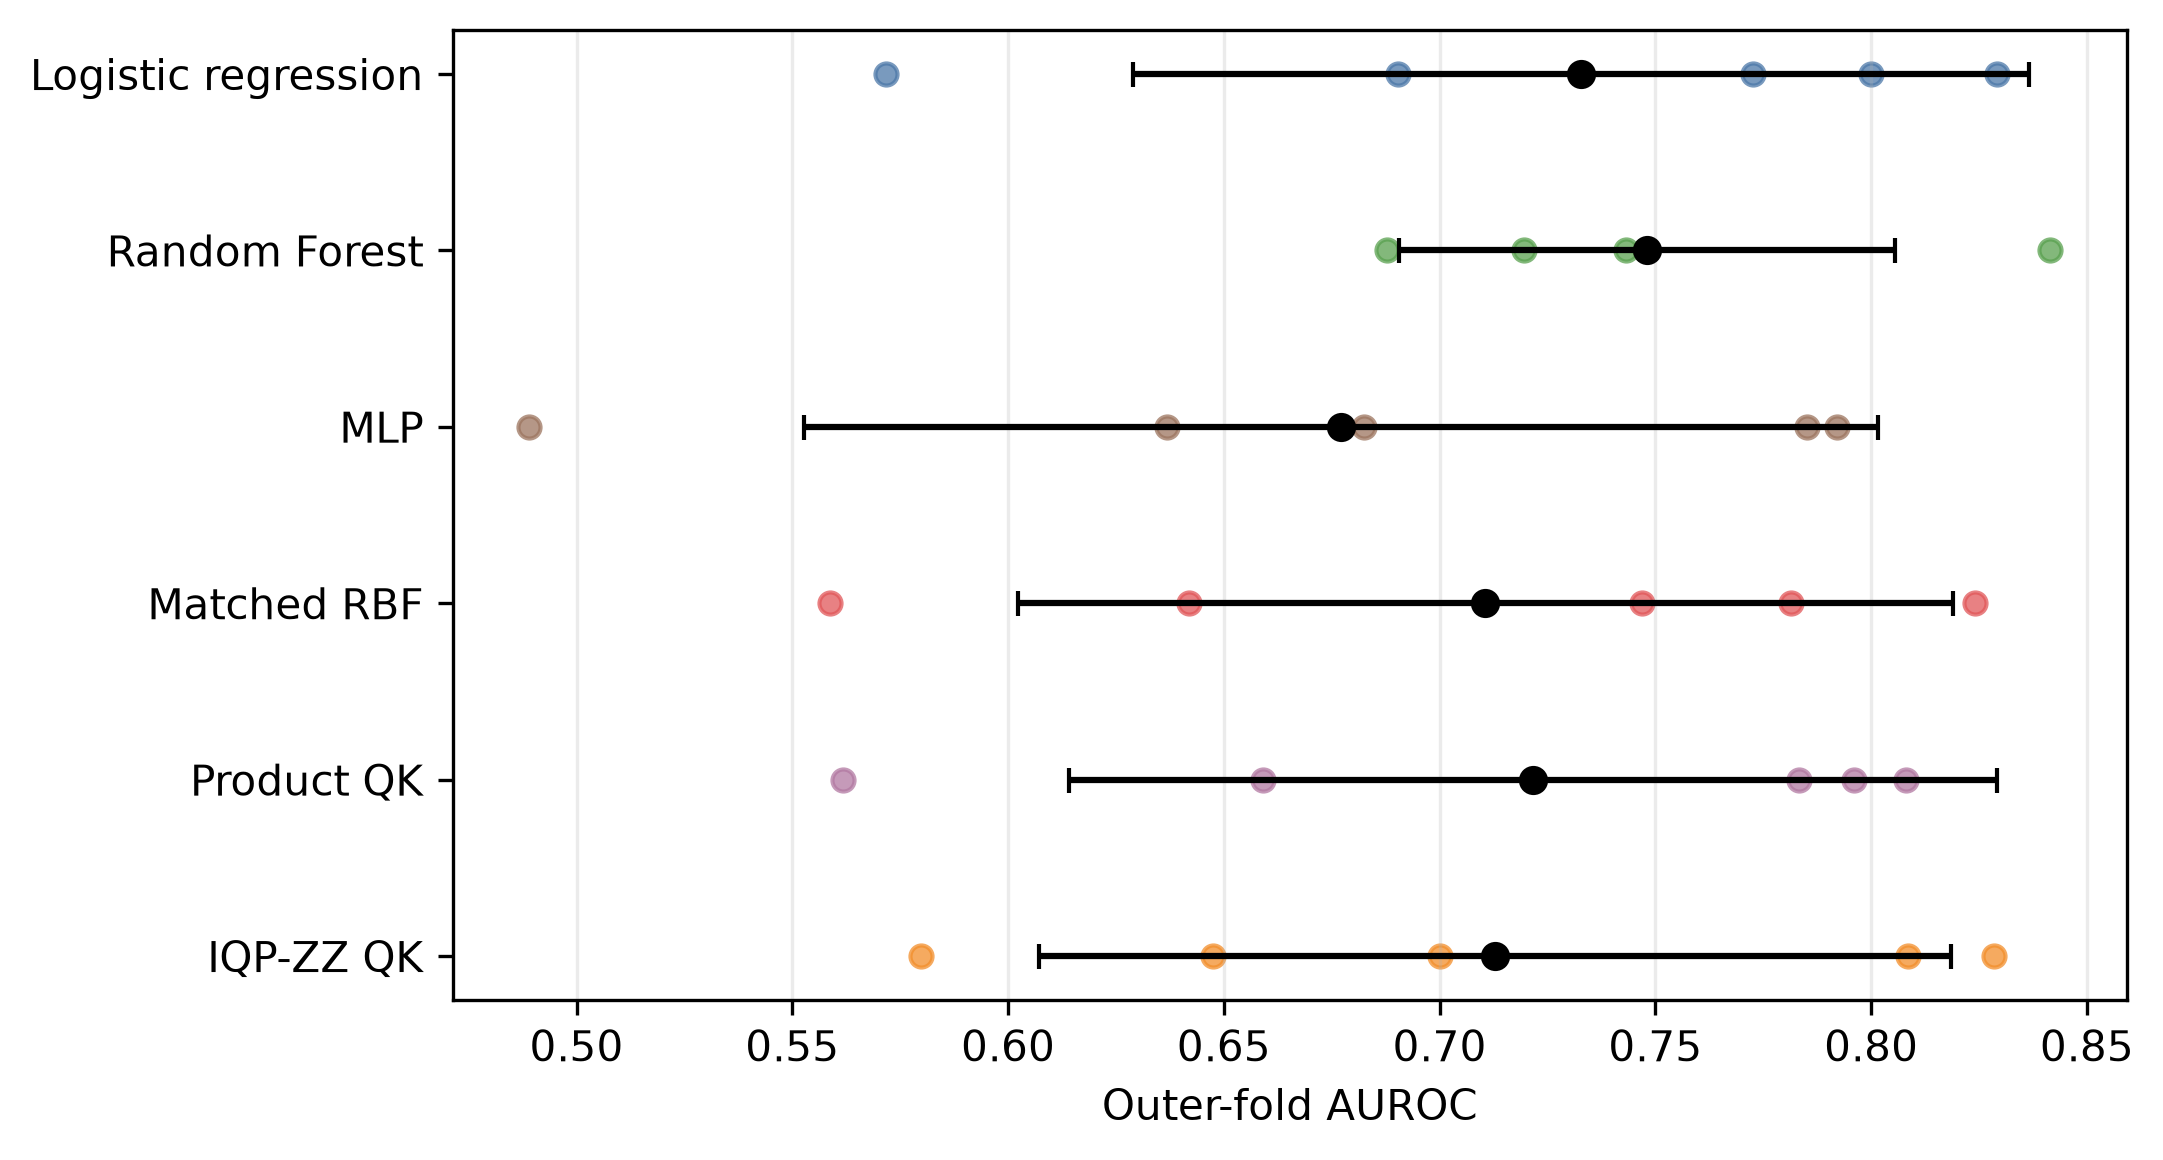

FIG02_NESTED_AUPRC.png


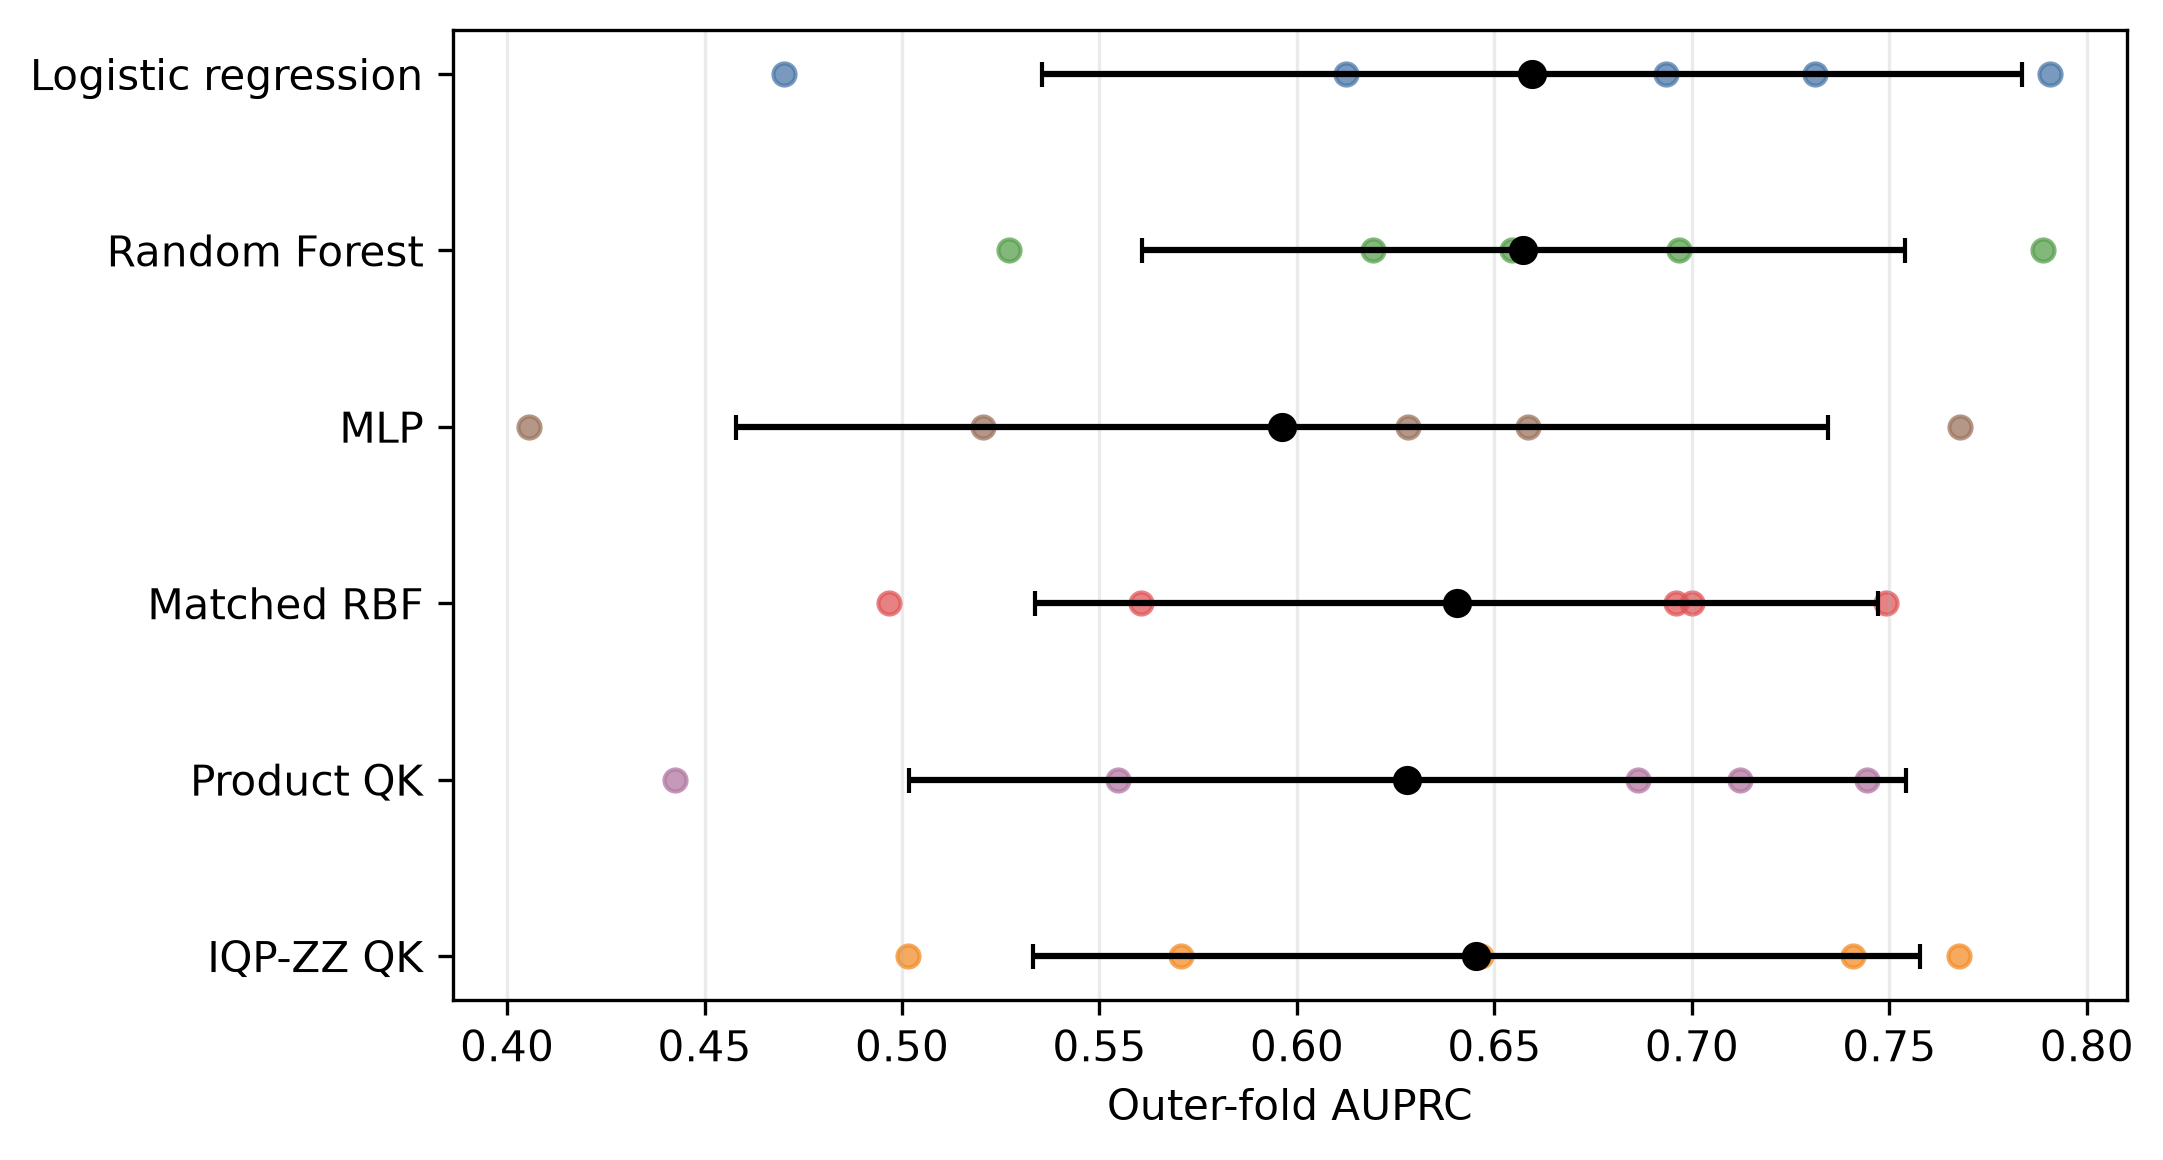

FIG03_Y_RANDOMIZATION.png


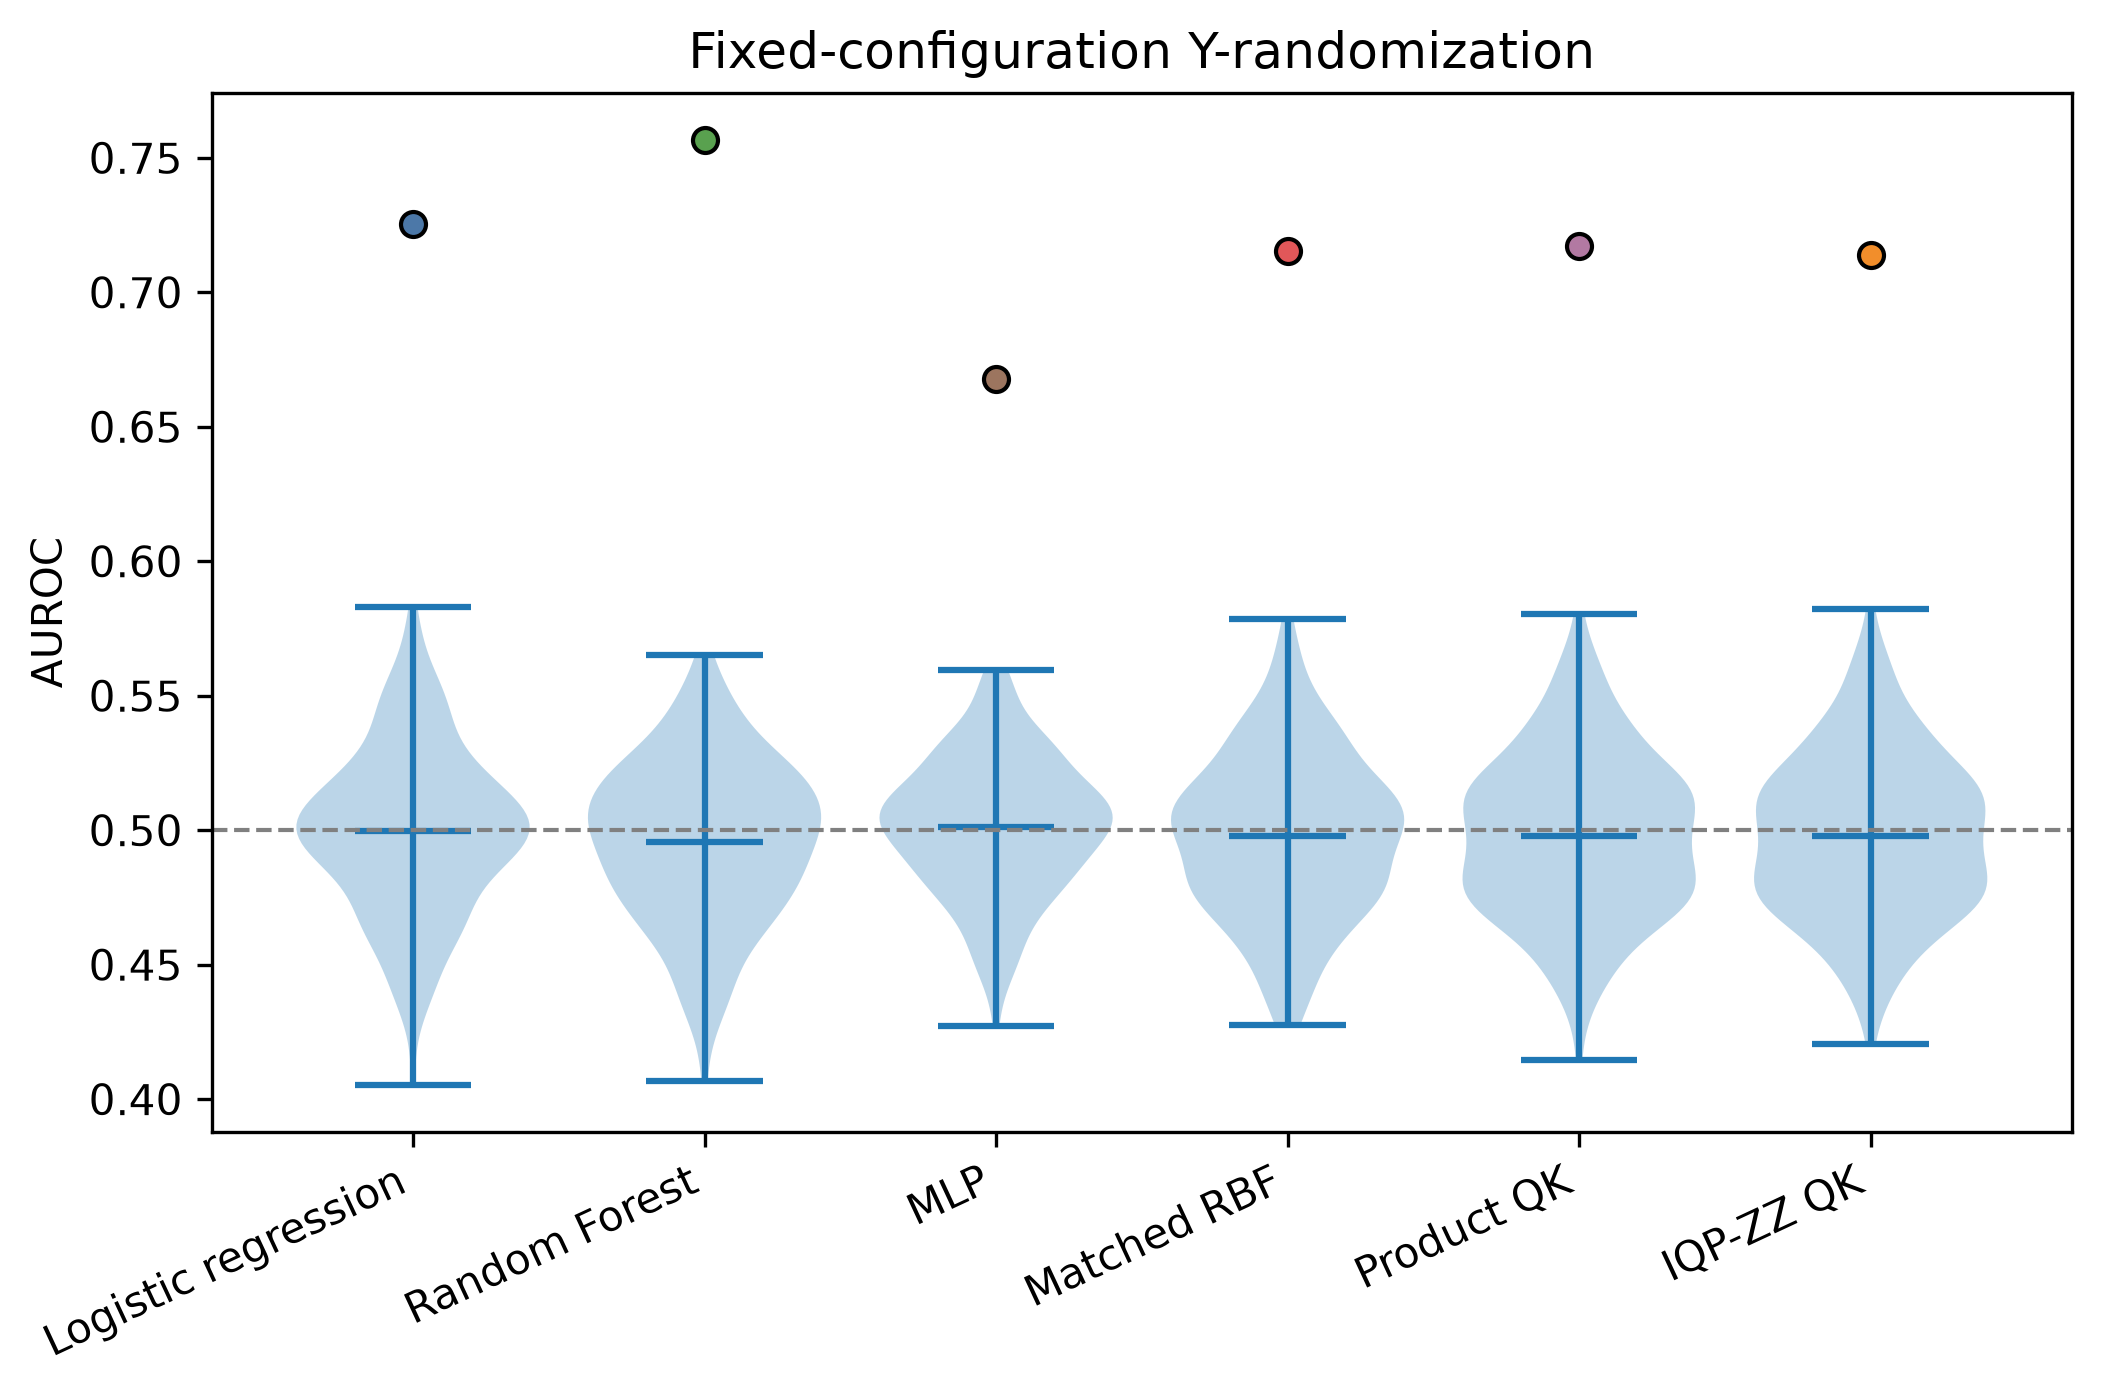

FIG04_DUAL_AD_CR8.png


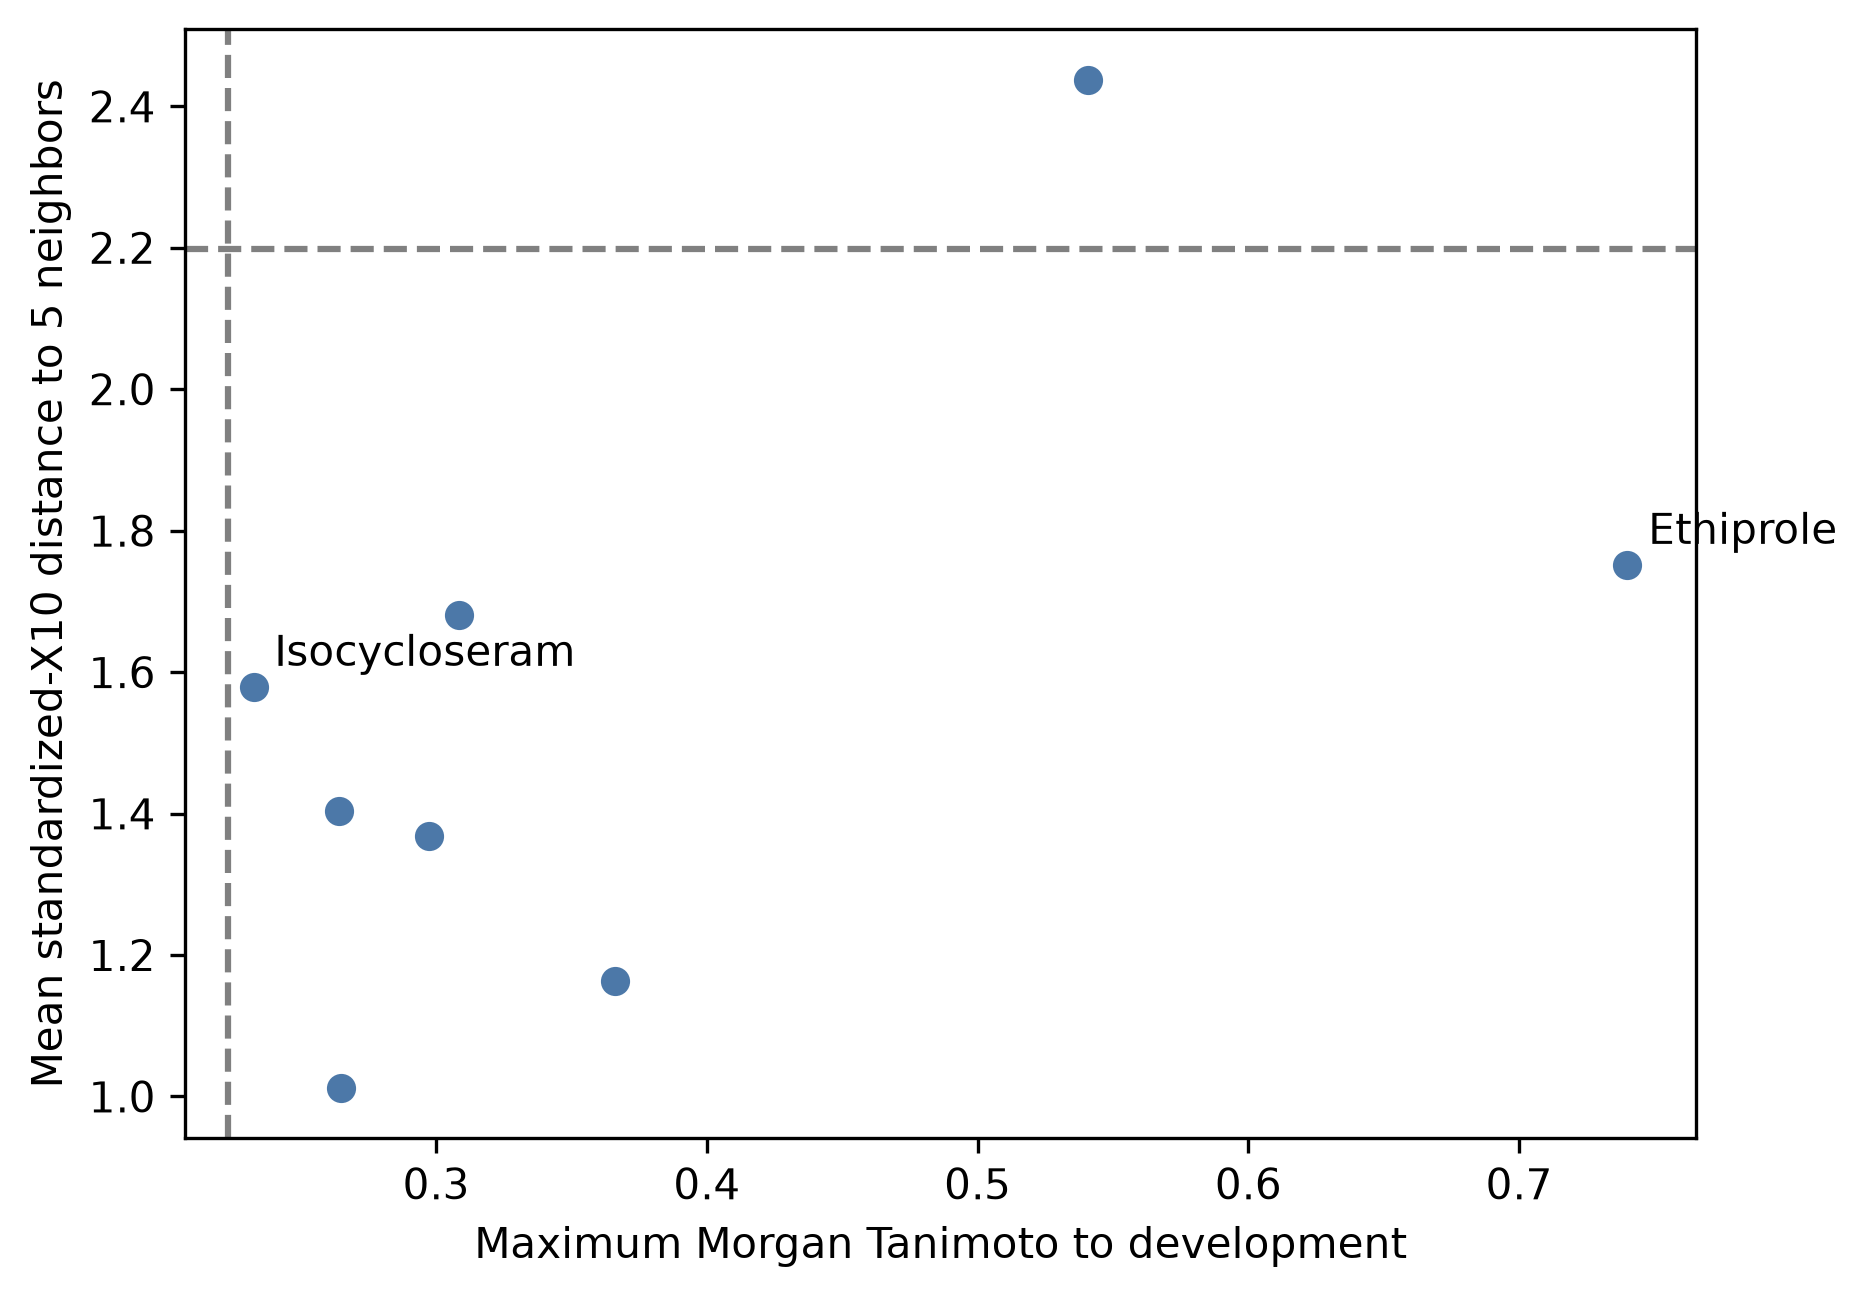

FIG05_CR8_SCORE_MARGIN.png


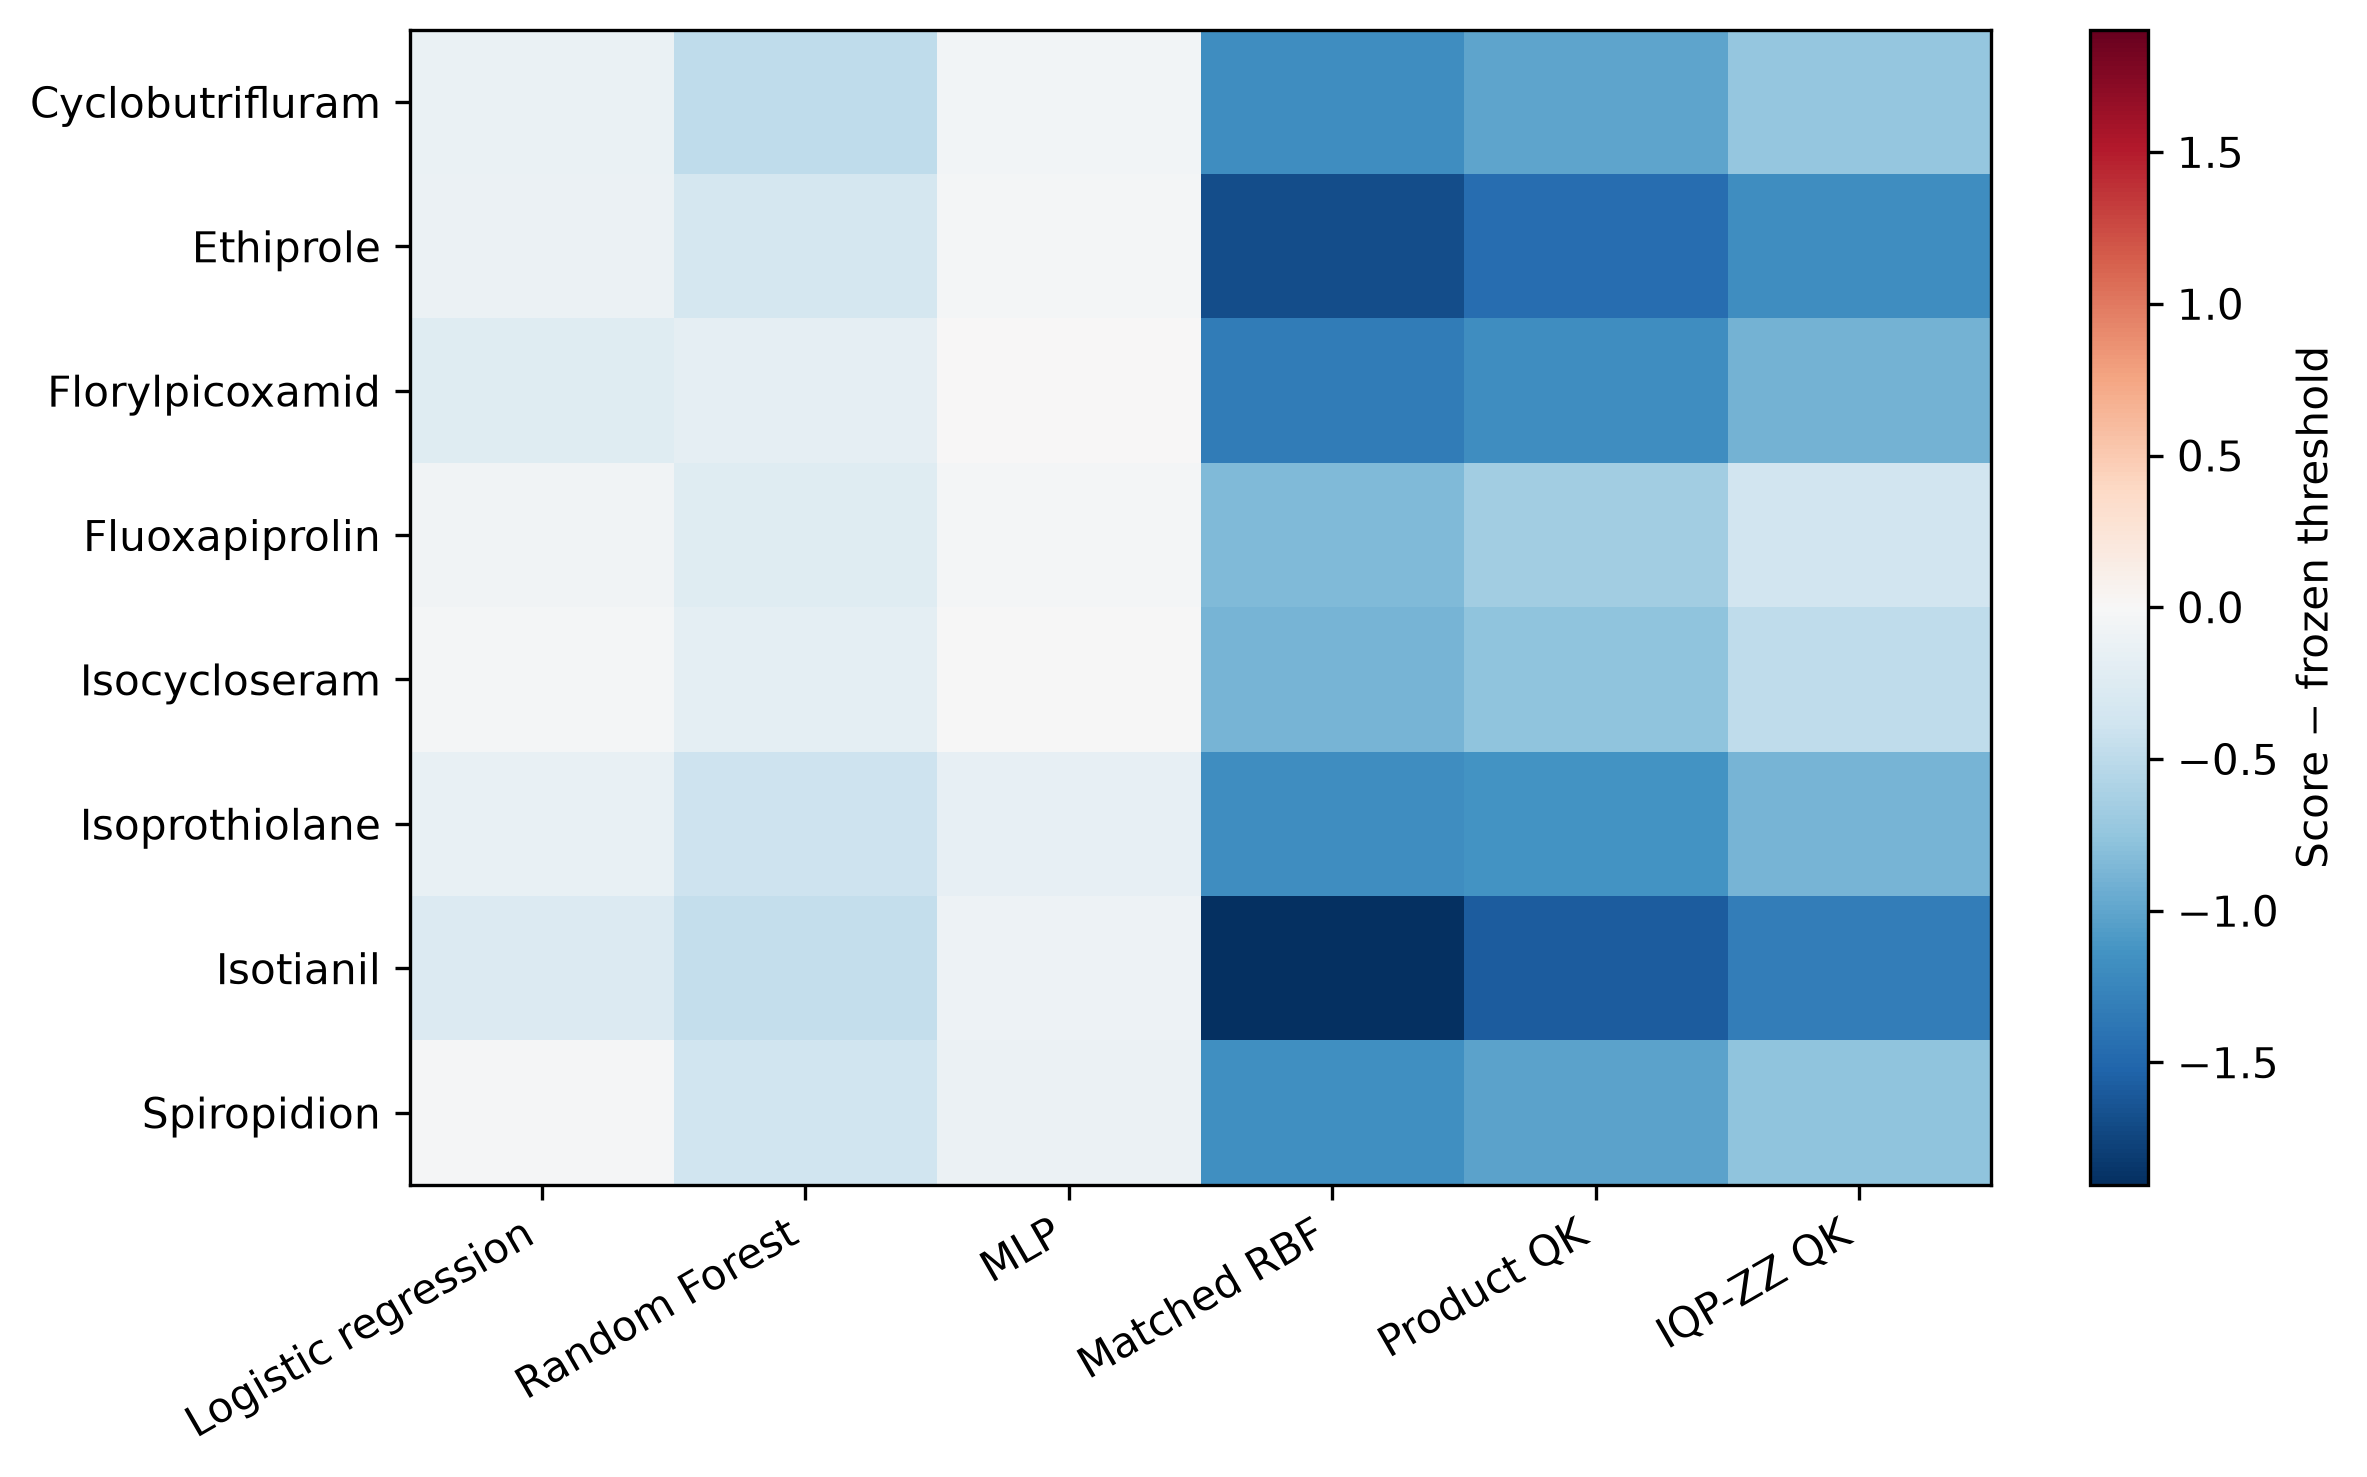

FIG06_ETHIPROLE_NEIGHBORS.png


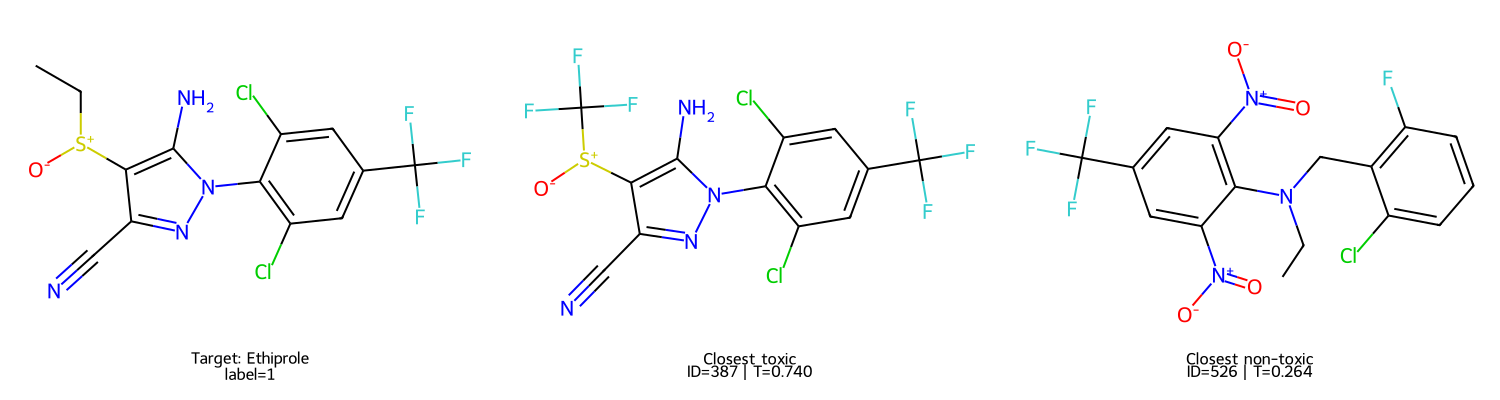

FIG07_ISOCYCLOSERAM_NEIGHBORS.png


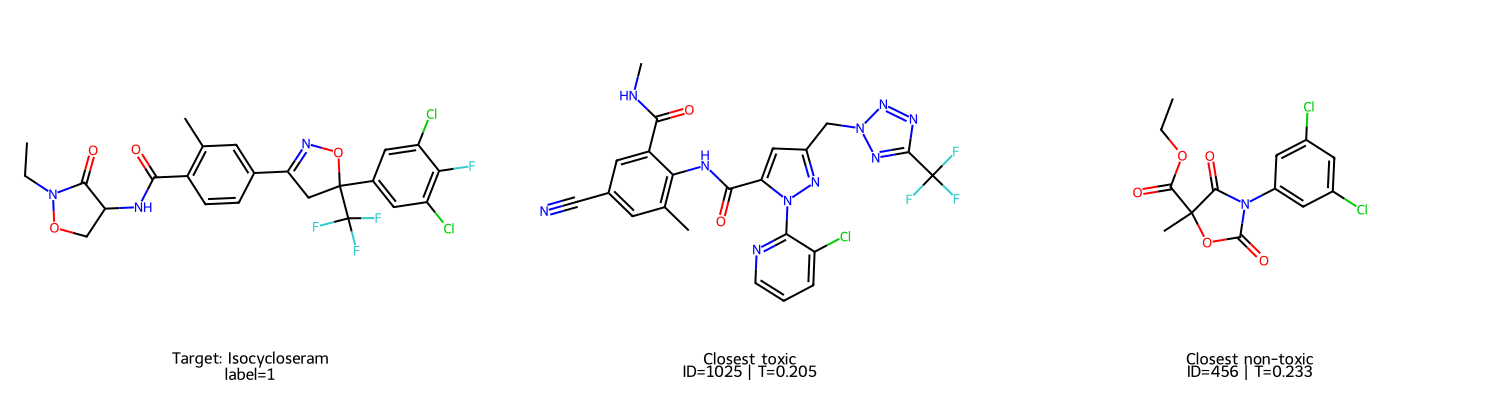

In [67]:
for figure in sorted(PATHS["figures"].glob("*.png")):
    print(figure.name)
    display(Image(filename=str(figure)))

In [68]:
print((CAMPAIGN_ROOT / "BEEQ_FINAL_CAMPAIGN_SUMMARY.md").read_text(encoding="utf-8"))

# BeeQ final nested structure-aware campaign summary

Campaign: `BEEQ_FINAL_NESTED_STRUCT_IMPL_20260831T020105Z`  
Status: complete  
Seed: `20260824`

## 1. Dataset and hashes

All four official SHA-256 hashes matched before modeling. Development contained
712 molecules (490 non-toxic, 222 toxic); the historical holdout contained 181
(132/49), and CR8 contained eight (6/2). Holdout and CR8 contents were first
opened only after the development freeze manifest had been written and verified.

## 2. Frozen X10

The exact ordered features were: `MolLogP`, `MolWt`, `TPSA_SP`, `NumHDonors`, `NumRotatableBonds`, `NumAromaticRings`, `nHalogen`, `n_OP`, `LiPHEX_prediction`, `sasa002_frac_polar_hetero_only`.
No feature was added, removed, recalculated, or selected.

## 3. Nested CV protocol and split integrity

Five frozen `STRICT_CV_FOLD` outer folds were used. Within every outer-training
partition, four deterministic `StratifiedGroupKFold` splits grouped by
`BUTINA_CLUSTER_ID` selected hyperpa

In [69]:
# Re-verify every recorded hash against what is on disk.
recorded = pd.read_csv(PATHS["manifest"] / "ARTIFACT_MANIFEST_SHA256.csv")
mismatched = [
    row.relative_path
    for row in recorded.itertuples(index=False)
    if sha256_file(CAMPAIGN_ROOT / row.relative_path) != row.sha256
]
print(f"{len(recorded)} artifacts, {len(mismatched)} mismatched")
print(json.loads((PATHS["manifest"] / "CAMPAIGN_STATUS.json").read_text(encoding="utf-8")))

51 artifacts, 0 mismatched
{'artifact_count_excluding_manifest_and_status': 51, 'completed_utc': '2026-08-31T03:36:33.218866+00:00', 'manifest_sha256': '02af58ec60e359c8e27fcb459ec65c84a6484fd71d9bc7cba43ac8744347fcc0', 'status': 'complete'}


## 18. Appendix

### Test suite

`tests/` imports from `src/`, not from this notebook, so it validates the repository
rather than this transcription. Running both is the point: if the suite passes and the
notebook reproduces the campaign, the two agree.

In [70]:
RUN_TESTS = False

if RUN_TESTS:
    completed = subprocess.run(
        [sys.executable, "-m", "pytest", "-q"],
        cwd=PROJECT_ROOT, capture_output=True, text=True,
    )
    print(completed.stdout[-4000:])
else:
    print("Skipped. Set RUN_TESTS = True to run tests/ against src/.")

Skipped. Set RUN_TESTS = True to run tests/ against src/.


### Naming map

Every identifier that differs from the repository, and why.

| Notebook | Source | Reason |
| --- | --- | --- |
| `grouped_inner_splits` | `classical_models._inner_splits` / `quantum_experiment._inner_splits` | Identical in both modules; defined once |
| `summarize_classical` | `classical_models._summarize` | Collided with the quantum summarizer |
| `summarize_quantum` | `quantum_experiment._summarize` | Collided with the classical summarizer |
| `_load_classical_config` | `experiment._load_config` | Two modules define `_load_config` |
| `_load_quantum_config` | `quantum_experiment._load_config` | Two modules define `_load_config` |
| `_write_classical_outputs` | `experiment._write_outputs` | Clarity next to the other writers |
| `_evaluation_rows` | `external_challenge._rows` | Very generic name in a shared namespace |
| `build_70_20_10_split` | `split_70_20_10.build` | Very generic name in a shared namespace |
| `FINAL_SEED` | `final_nested_campaign.SEED` | `20260824`, vs `config.SEED = 42` |
| `write_json_campaign` | `final_nested_campaign.write_json` | Applies `jsonable()`; `data.write_json` returns a `Path` |
| `campaign_environment` | `final_nested_campaign.environment` | Different schema from `provenance.environment` |
| `campaign_git_state` | `final_nested_campaign.git_state` | Also made non-raising |
| `nested_inner_splits` | `final_nested_campaign.inner_splits` | Collided with `inner_splits` parameters elsewhere |
| `build_prediction_rows` | `final_nested_campaign.prediction_rows` | Collided with local `prediction_rows` lists |
| `select_kernel_nested` | `final_nested_campaign.select_kernel` | Too close to `quantum_experiment._select_kernel` |

Not redefined, because an identical definition already exists earlier in the notebook:
`final_nested_campaign.sha256_file`, `final_nested_campaign.PROJECT_ROOT` /
`DEFAULT_DATA_DIR`, `split_70_20_10.SEED`, `quantum_experiment._inner_splits`.

### Interpretation rules carried over from the repository

- Model, hyperparameter, threshold, feature, and architecture selection use development
  data only.
- The 181-molecule holdout is historical and previously inspected — not a pristine
  confirmatory test.
- CR8 is an eight-molecule challenge panel, not a validation cohort; its metrics are
  highly unstable.
- Exact and RDKit-canonical SMILES overlap with the internal corpus must both be zero.
- Exact simulated fidelity kernels say nothing about hardware behaviour and establish no
  quantum advantage.
- Completed campaign directories are immutable and are not combined with later results.